### from stim_geting_started.ipynb

In [ ]:
!pip install stim~=1.14
!pip install numpy~=1.0  # 1.0 instead of 2.0 for pymatching compatibility later
!pip install scipy

In [ ]:
import stim
print(stim.__version__)

In [ ]:
test_circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
test_circuit.append("H", [0])
test_circuit.append("CNOT", [0, 1])

# Then, the circuit will measure both qubits of the Bell pair in the Z basis.
test_circuit.append("M", [0, 1])

In [ ]:
print(test_circuit)
test_circuit.diagram('timeline-svg')

In [ ]:
test_sampler = test_circuit.compile_sampler()
print(test_sampler.sample(shots=10))

In [ ]:
test_circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
test_circuit.append("H", [0])
test_circuit.append("CNOT", [0, 1])

# Then, the circuit will measure both qubits of the Bell pair in the Z basis.
test_circuit.append("M", [0, 1])
test_circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2)]) #most recent and second most recent
test_circuit.diagram('timeline-svg')

In [ ]:
#detect error with DETECTOR,
#DETECTOR asserts parity of the measurements are the same
#Result "False" means parity is consistant, i.e. no error
test_sampler = test_circuit.compile_detector_sampler()
print(test_sampler.sample(shots=5))

Stim has a variety of error channels to pick from, like single qubit depolarization (DEPOLARIZE1) and phase damping (Z_ERROR), but in this context a good error to try is X_ERROR. The X_ERROR noise channel probabilistically applies a bit flip (a Pauli X error) to each of its targets. Note that each target is operated on independently. They don't all flip together with the given probability, each one flips individually with the given probability.

In [ ]:
test_circuit = stim.Circuit("""
    H 0
    TICK

    CX 0 1
    X_ERROR(0.2) 0 1
    TICK

    M 0 1
    DETECTOR rec[-1] rec[-2]
""")

In [ ]:
#This diagram shows the operations from each tick in a separate frame
test_circuit.diagram('timeslice-svg')

In [ ]:
test_sampler = test_circuit.compile_detector_sampler()
print(test_sampler.sample(shots=10))

In [ ]:
import numpy as np
#You can estimate the detection fraction by just taking a lot of shots, and dividing by the number of shots and the number of detectors
np.sum(test_sampler.sample(shots=1000000)/1000000)

In [ ]:
!pip install pymatching~=2.0

In [ ]:
surface_code_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=9,
    distance=3,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)

In [ ]:
#timeline diagram
surface_code_circuit.without_noise().diagram("timeslice-svg")

In [ ]:
surface_code_circuit.without_noise().diagram("timeline-3d")

In [ ]:
#decode slice diagram
#RGB=XYZ
#each coloured shape is a stabiliser
#curve lines when middle point is included in the stabiliser
surface_code_circuit.diagram("detslice-svg")



In [ ]:
surface_code_circuit.without_noise().diagram(
    "detslice-with-ops-svg",
    tick=range(0, 9),
)

In [ ]:


surface_code_circuit.diagram("matchgraph-3d")

In [ ]:


!pip install sinter~=1.14



In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
surface_code_tasks = [
    sinter.Task(
        circuit = stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=d * 3,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise,
        ),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in [0.008, 0.009, 0.01, 0.011, 0.012]
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates (Phenomenological Noise) (for different distance d?)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

## try some other circuits

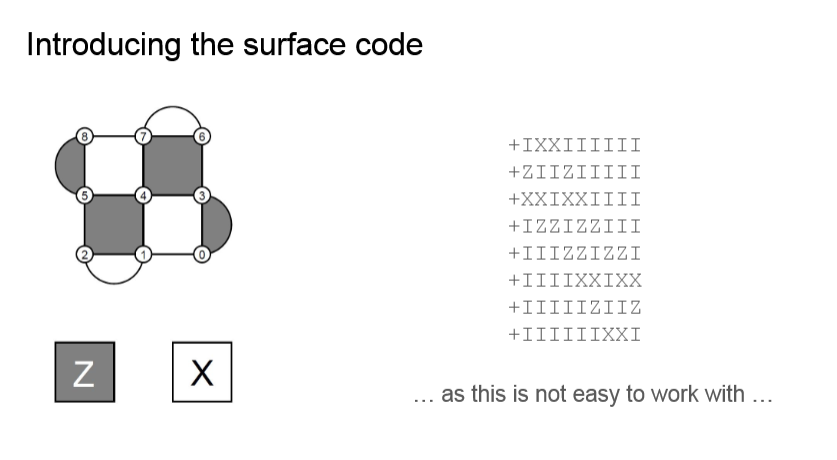
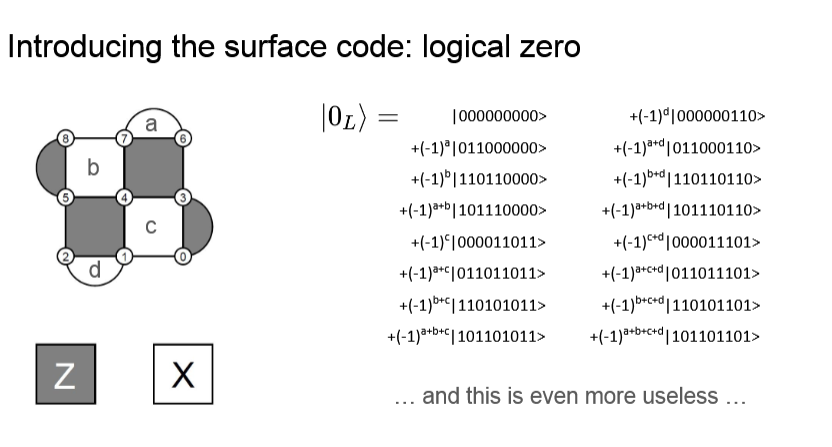
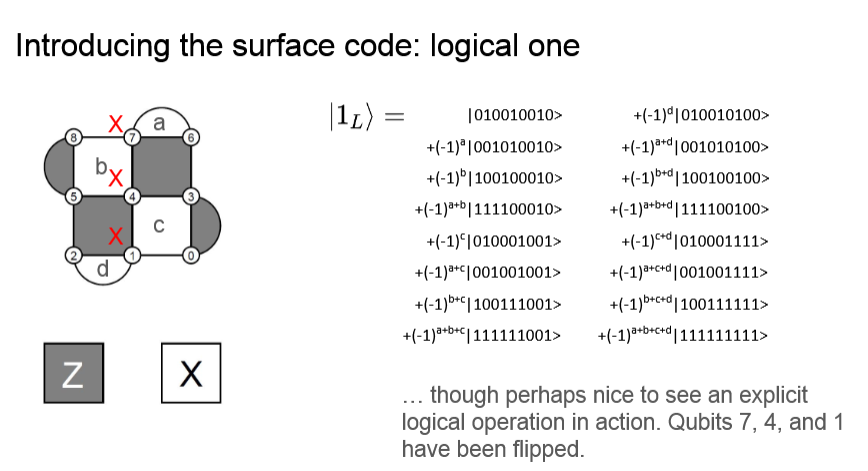
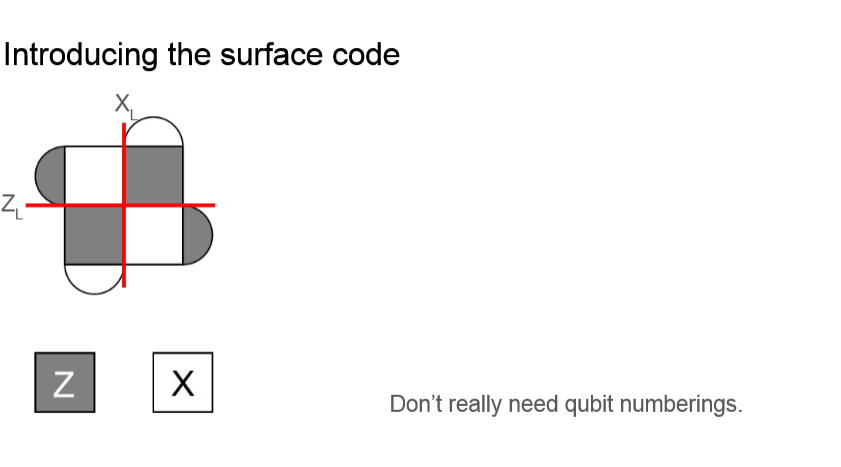

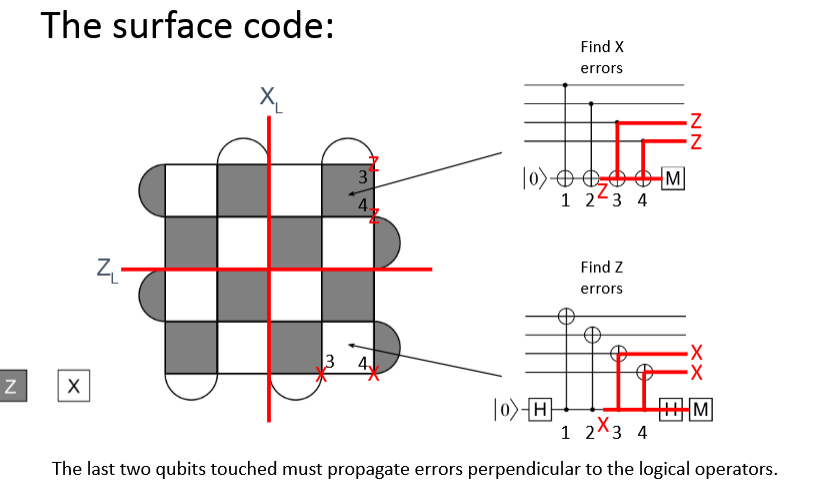

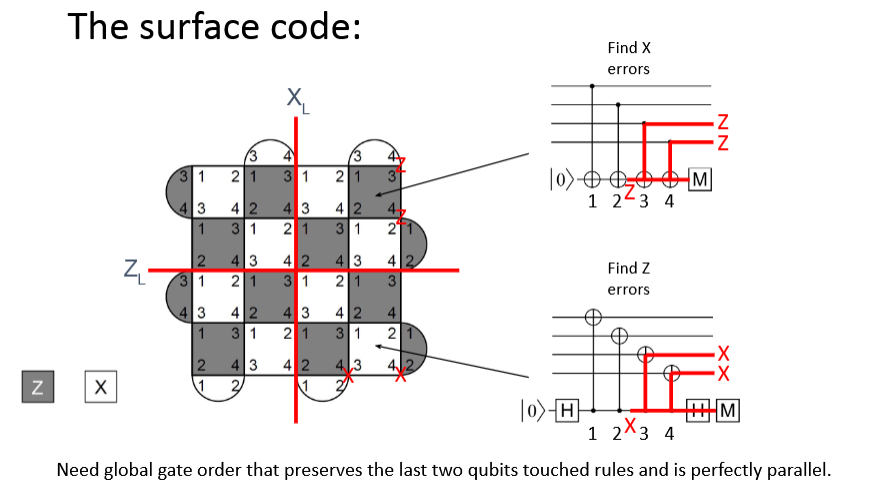
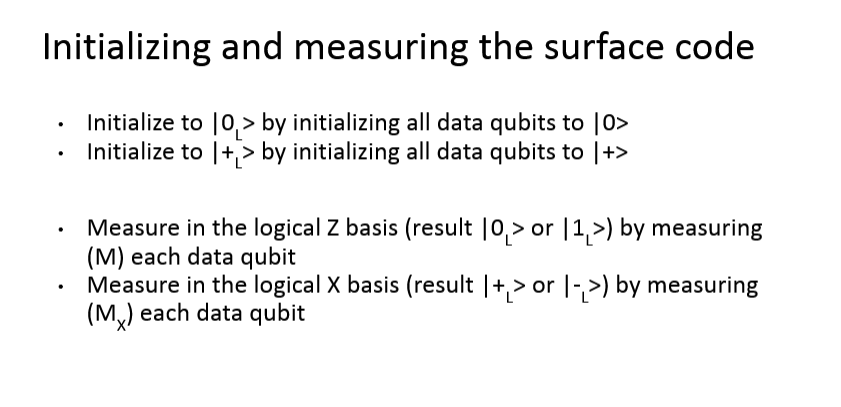
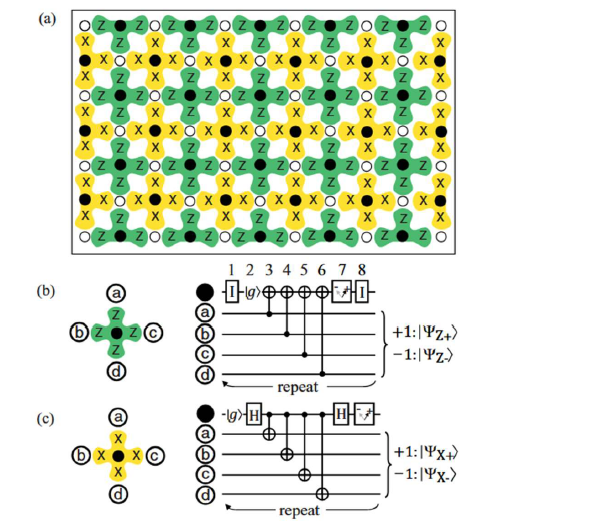

#### not split to over 8 ticks (error)

In [ ]:
# stim api

#def generated(
#    code_task: str,
#    *,
#    distance: int,
#    rounds: int,
#    after_clifford_depolarization: float = 0.0,
#    before_round_data_depolarization: float = 0.0,
#    before_measure_flip_probability: float = 0.0,
#    after_reset_flip_probability: float = 0.0,
#) -> stim.Circuit:
    """Generates common circuits.

    The generated circuits can include configurable noise.

    The generated circuits include DETECTOR and OBSERVABLE_INCLUDE annotations so
    that their detection events and logical observables can be sampled.

    The generated circuits include TICK annotations to mark the progression of time.
    (E.g. so that converting them using `stimcirq.stim_circuit_to_cirq_circuit` will
    produce a `cirq.Circuit` with the intended moment structure.)

    Args:
        code_task: A string identifying the type of circuit to generate. Available
            code tasks are:
                - "repetition_code:memory"
                - "surface_code:rotated_memory_x"
                - "surface_code:rotated_memory_z"
                - "surface_code:unrotated_memory_x"
                - "surface_code:unrotated_memory_z"
                - "color_code:memory_xyz"
        distance: The desired code distance of the generated circuit. The code
            distance is the minimum number of physical errors needed to cause a
            logical error. This parameter indirectly determines how many qubits the
            generated circuit uses.
        rounds: How many times the measurement qubits in the generated circuit will
            be measured. Indirectly determines the duration of the generated
            circuit.
        after_clifford_depolarization: Defaults to 0. The probability (p) of
            `DEPOLARIZE1(p)` operations to add after every single-qubit Clifford
            operation and `DEPOLARIZE2(p)` operations to add after every two-qubit
            Clifford operation. The after-Clifford depolarizing operations are only
            included if this probability is not 0.
        before_round_data_depolarization: Defaults to 0. The probability (p) of
            `DEPOLARIZE1(p)` operations to apply to every data qubit at the start of
            a round of stabilizer measurements. The start-of-round depolarizing
            operations are only included if this probability is not 0.
        before_measure_flip_probability: Defaults to 0. The probability (p) of
            `X_ERROR(p)` operations applied to qubits before each measurement (X
            basis measurements use `Z_ERROR(p)` instead). The before-measurement
            flips are only included if this probability is not 0.
        after_reset_flip_probability: Defaults to 0. The probability (p) of
            `X_ERROR(p)` operations applied to qubits after each reset (X basis
            resets use `Z_ERROR(p)` instead). The after-reset flips are only
            included if this probability is not 0.

    Returns:
        The generated circuit.

In [ ]:
# look at the unrotated one
surface_code_circuit = stim.Circuit.generated(
    "surface_code:unrotated_memory_z",
    rounds=3,
    distance=3,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)
print(surface_code_circuit)

(d=3, round= 5)




QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
TICK
CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
TICK
CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
TICK
CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
TICK
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR(0, 1, 0) rec[-10]
DETECTOR(0, 3, 0) rec[-5]
DETECTOR(2, 1, 0) rec[-9]
DETECTOR(2, 3, 0) rec[-4]
DETECTOR(4, 1, 0) rec[-8]
DETECTOR(4, 3, 0) rec[-3]
REPEAT 4 {
    TICK
    DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    TICK
    CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
    DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
    TICK
    CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    TICK
    CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    TICK
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    MR 1 3 5 7 9 11 13 15 17 19 21 23
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    SHIFT_COORDS(0, 0, 1)
    DETECTOR(1, 0, 0) rec[-12] rec[-24]
    DETECTOR(3, 0, 0) rec[-11] rec[-23]
    DETECTOR(0, 1, 0) rec[-10] rec[-22]
    DETECTOR(2, 1, 0) rec[-9] rec[-21]
    DETECTOR(4, 1, 0) rec[-8] rec[-20]
    DETECTOR(1, 2, 0) rec[-7] rec[-19]
    DETECTOR(3, 2, 0) rec[-6] rec[-18]
    DETECTOR(0, 3, 0) rec[-5] rec[-17]
    DETECTOR(2, 3, 0) rec[-4] rec[-16]
    DETECTOR(4, 3, 0) rec[-3] rec[-15]
    DETECTOR(1, 4, 0) rec[-2] rec[-14]
    DETECTOR(3, 4, 0) rec[-1] rec[-13]
}
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR(0, 1, 1) rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR(0, 3, 1) rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR(2, 1, 1) rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR(2, 3, 1) rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR(4, 1, 1) rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR(4, 3, 1) rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]





In [ ]:
surface_code_circuit.diagram("detslice-svg")

In [ ]:
surface_code_circuit.without_noise().diagram("timeslice-svg")

In [ ]:
surface_code_circuit.diagram('timeline-svg')

 need to change order of CX within each stabiliser?


-------------------- 
CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17


DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17



TICK

---------------------
CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19


DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19


TICK

--------------------
CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19


DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19


TICK

--------------------
CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19


DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19


TICK

In [ ]:
import numpy as np


#define the CX in each tick as A,B,C,D????



A=[""""""]

B=["""
"""]
C=["""
"""]
D=["""
"""]


#ignore the coordinates and detectors for now??

def make_examplecircuit_with_some_gate_ordering_no_coords(rounds,order):
    '''
    create a d=3 unrotated surface code with some specified order of the CX gate
    args:
    rounds: rounds of measurement
    order: a list
    returns: a circuit
    '''
    one_round=[]
    
    #append the standard stuff for the circuit
    ...
    #append the CX in selected order
    for gates in order:
        one_round.append(gates)
    
    
    #the rest of the text for the circuit
    ...
    
    Total=[]
    for n in range(rounds):
        Total.append(one_round)
    flat_Total=[]
    for a in Total:
        for b in a:
            flat_Total.append(b)
    #create the circuit
    circuit=stim.Circuit()
    for x in flat_Total:
        circuit.append(x)  # this won't be able to assign qubits to the gates 
        #nor can it apply errors because can't specify value
    
    
    
    return circuit
    
    

In [ ]:
circuit=make_examplecircuit_with_some_gate_ordering_no_coords(3,["H","CX","tick"])


print(circuit)

- need to deal with coordinates and detectors...
- need to specifiy which qubits for each gates

In [ ]:
# cannot use circuit.append(...) directly with the relavent part of the circuit from text?


#maybe try stim.Circuit.append_from_stim_program_text, this should fix the problem with assigning qubits to gates
#as well as specifying value for error


def circuit_with_program_txt(rounds,text):
    """
    """
    ...
    

- qubit coords doesn't change so it is not much of an issue

- detectors have different rec[X], can't just shuffle the text 


- detectors for first and last round is different


- need to change the combination of rec[x] and coordinates 

In [ ]:
#no detector coordinates, can't plot some graphs but should act the same
circuit_text = r"""
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
TICK
CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
TICK
CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
TICK
CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
TICK
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
REPEAT 2 {
    TICK
    DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    TICK
    CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
    DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
    TICK
    CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    TICK
    CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    TICK
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    MR 1 3 5 7 9 11 13 15 17 19 21 23
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    DETECTOR rec[-12] rec[-24]
    DETECTOR rec[-11] rec[-23]
    DETECTOR rec[-10] rec[-22]
    DETECTOR rec[-9] rec[-21]
    DETECTOR rec[-8] rec[-20]
    DETECTOR rec[-7] rec[-19]
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-4] rec[-16]
    DETECTOR rec[-3] rec[-15]
    DETECTOR rec[-2] rec[-14]
    DETECTOR rec[-1] rec[-13]
}
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""
import stim

expanded_text = str(stim.Circuit(circuit_text).flattened())
#lines = expanded_text.splitlines()
print(expanded_text)

In [ ]:
text1="""a
b
"""
text2="""c
d
"""
print(text1+text2+"""
123
""")

In [ ]:

def circuit_with_program_txt(rounds,order):
    """
    order=[1,2,3,4],etc
    """
    c_txt="""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
    """
    #define blocks of CX
    CX1='''CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    TICK
    '''
    CX2='''CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19#
    DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
    TICK
    '''
    CX3='''CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    TICK
    '''
    CX4='''CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    TICK
    '''
    for k in order:
        if k==1:
            c_txt=c_txt+CX1
        if k==2:
            c_txt=c_txt+CX2
        if k==3:
            c_txt=c_txt+CX3
        if k==4:
            c_txt=c_txt+CX4
            
    next_bit="""H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
    """
    c_txt=c_txt+next_bit

    #define repeat block

    repeat_block="""REPEAT """ +str(rounds-1) + """{"""
    repeat_block=repeat_block+"""
    TICK
    DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    """
    for k in order:
        if k==1:
            repeat_block=repeat_block+CX1
        if k==2:
            repeat_block=repeat_block+CX2
        if k==3:
            repeat_block=repeat_block+CX3
        if k==4:
            repeat_block=repeat_block+CX4
    repeat_block=repeat_block+"""
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    MR 1 3 5 7 9 11 13 15 17 19 21 23
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    DETECTOR rec[-12] rec[-24]
    DETECTOR rec[-11] rec[-23]
    DETECTOR rec[-10] rec[-22]
    DETECTOR rec[-9] rec[-21]
    DETECTOR rec[-8] rec[-20]
    DETECTOR rec[-7] rec[-19]
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-4] rec[-16]
    DETECTOR rec[-3] rec[-15]
    DETECTOR rec[-2] rec[-14]
    DETECTOR rec[-1] rec[-13]
    }"""
    c_txt=c_txt+repeat_block
    #the rest of the stuff
    c_txt=c_txt+"""
    X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    M 0 2 4 6 8 10 12 14 16 18 20 22 24
    DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
    DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
    DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
    DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
    DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
    DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
    OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
    """
    return stim.Circuit(c_txt)
            
        

In [ ]:
circuit=circuit_with_program_txt(3,[4,2,1,3])
print(circuit)

In [ ]:
b=""""""
c=[1,3,4,2]
for d in c:
    if d==1:
        b=b+"""1"""
    if d==2:
        b=b+"""2"""
    if d==3:
        b=b+"""3"""
    if d==4:
        b=b+"""4"""
print(b) 
import itertools
print(list(itertools.permutations([1, 2, 3,4])))

In [ ]:
sampler = circuit.compile_sampler()
print(sampler.sample(shots=1))

In [ ]:
#sinter

import os
import sinter
from typing import List

surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_v2(3,ORDER),
        json_metadata={'d': 3, 'r': 3, 'order': ORDER},
    )
    #for ORDER in list(itertools.permutations([1, 2, 3, 4]))
    for ORDER in ((1,2,3,4),(1,3,2,4),(1, 3, 4, 2))
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

- got non deterministic detector error when the last one is not 4
- need to change stuff
- first R and MR inside repeat on qubit 23
- breaks when starts or ends in 2,3
- v1 only works on [(1, 2, 3, 4), (1, 3, 2, 4), (4, 2, 3, 1), (4, 3, 2, 1)]

In [ ]:
circuit=circuit_with_program_txt(3,[4,2,3,1])
circuit[:].detector_error_model()

In [ ]:
circuit=circuit_with_program_txt(3,[1,2,3,4])
circuit[:].detector_error_model()

In [ ]:
circuit=circuit_with_program_txt(3,[1,2,4,3])
circuit[:].detector_error_model()

In [ ]:
circuit=circuit_with_program_txt(3,[4,1,3,2])
circuit[:].detector_error_model()

In [ ]:
circuit4321=circuit_with_program_txt(3,[4,3,2,1])
circuit4321.without_noise().diagram("timeslice-svg")

In [ ]:
circuit4321.diagram("detslice-svg")

In [ ]:
circuit4321[:].detector_error_model()

In [ ]:
circuit4231=circuit_with_program_txt(3,[4,2,3,1])
circuit4231.diagram("detslice-svg")

In [ ]:
circuit4231[:].detector_error_model()

In [ ]:
circuit3421=circuit_with_program_txt(3,[3,4,2,1])
circuit3421.diagram("detslice-svg")



In [ ]:
circuit3421.without_noise().diagram("timeslice-svg")

In [ ]:
circuit3421[:].detector_error_model()

In [ ]:
circuit1324=circuit_with_program_txt(3,[1,3,2,4])
circuit1324.diagram("detslice-svg")

In [ ]:
circuit1324[:].detector_error_model()

In [ ]:
circuit3214=circuit_with_program_txt(3,[3,2,1,4])
circuit3214.diagram("detslice-svg")

In [ ]:
circuit3214[:].detector_error_model()

In [ ]:
circuit2431=circuit_with_program_txt(3,[2,4,3,1])
circuit2431.diagram("detslice-svg")

In [ ]:
circuit2431[:].detector_error_model()

In [ ]:
circuit1243=circuit_with_program_txt(3,[1,2,4,3])
circuit1243.diagram("detslice-svg")

In [ ]:
circuit1243[:].detector_error_model()

In [ ]:
circuit1342=circuit_with_program_txt(3,[1,3,4,2])
circuit1342.diagram("detslice-svg")

In [ ]:
circuit1342[:].detector_error_model()

In [ ]:
print(circuit3421)

In [ ]:
# to complete
def circuit_with_program_txt_v2(rounds,order):
    """
    order=[1,2,3,4],etc
    need to find out is the issue the R,MR or the detectors or something else
    """
    c_txt="""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
#this R also seem to cause issue??
R 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
    """
    #define blocks of CX
    CX1='''CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
    TICK
    '''
    CX2='''CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19#
    DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
    TICK
    '''
    CX3='''CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
    TICK
    '''
    CX4='''CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
    TICK
    '''
    for k in order:
        if k==1:
            c_txt=c_txt+CX1
        if k==2:
            c_txt=c_txt+CX2
        if k==3:
            c_txt=c_txt+CX3
        if k==4:
            c_txt=c_txt+CX4
            
    next_bit="""H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
    """
    c_txt=c_txt+next_bit

    #define repeat block

    repeat_block="""REPEAT """ +str(rounds-1) + """{"""
    repeat_block=repeat_block+"""
    TICK
    DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    """
    for k in order:
        if k==1:
            repeat_block=repeat_block+CX1
        if k==2:
            repeat_block=repeat_block+CX2
        if k==3:
            repeat_block=repeat_block+CX3
        if k==4:
            repeat_block=repeat_block+CX4
    repeat_block=repeat_block+"""
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    """
    #MR in repeat causing issues? Always on qubit 23...
    if (order[0]==2 or order[0]==3) :
        repeat_block=repeat_block+"""
         MR 1 3 5 7 9 11 13 15 17 19 21 23
         """
    if (order[0]==1 or order[0]==4) and (order[-1]==2 or order[-1]==3) :
        repeat_block=repeat_block+"""
         MR 1 3 5 7 9 11 13 15 17 19 21 23
         """    
    if (order[-1]!=2 and order[-1]!=3) and (order[0]!=2 and order[0]!=3):
         repeat_block=repeat_block+"""
         MR 1 3 5 7 9 11 13 15 17 19 21 23
         """
    
    repeat_block=repeat_block+"""
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    DETECTOR rec[-12] rec[-24]
    DETECTOR rec[-11] rec[-23]
    DETECTOR rec[-10] rec[-22]
    DETECTOR rec[-9] rec[-21]
    DETECTOR rec[-8] rec[-20]
    DETECTOR rec[-7] rec[-19]
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-4] rec[-16]
    DETECTOR rec[-3] rec[-15]
    DETECTOR rec[-2] rec[-14]
    DETECTOR rec[-1] rec[-13]
    }"""
    if rounds!=1:
        c_txt=c_txt+repeat_block
    #the rest of the stuff
    c_txt=c_txt+"""
    X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    M 0 2 4 6 8 10 12 14 16 18 20 22 24
    DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
    DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
    DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
    DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
    DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
    DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
    OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
    """
    return stim.Circuit(c_txt)
            

In [ ]:
import stim

In [ ]:
circuit1342=circuit_with_program_txt_v2(1,[1,3,4,2])
circuit1342.diagram("detslice-svg")

In [ ]:
print(circuit1342)

In [ ]:
circuit1342[:].detector_error_model()

In [ ]:
circuit1342.without_noise().diagram("timeslice-svg")

In [ ]:
circuit1342.without_noise().diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D3', 'D9', ])

In [ ]:
# use smaller surface code for now

In [ ]:
surface_code_circuit2 = stim.Circuit.generated(
    "surface_code:unrotated_memory_z",
    rounds=3,
    distance=2,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)
print(surface_code_circuit2)

In [ ]:
surface_code_circuit2.without_noise().diagram("timeslice-svg")

In [ ]:
def circuit_with_program_txt_d2(rounds,order):
    """
    order=[1,2,3,4],etc
    need to find out is the issue the R,MR or the detectors or something else
    """
    c_txt="""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(0, 1) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(2, 1) 5
QUBIT_COORDS(0, 2) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(2, 2) 8
R 0 2 4 6 8
X_ERROR(0.001) 0 2 4 6 8
R 1 3 5 7
X_ERROR(0.001) 1 3 5 7
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8
H 1 7
DEPOLARIZE1(0.001) 1 7
TICK
    """
    #define blocks of CX
    CX1='''CX 1 2 7 8 4 3
    DEPOLARIZE2(0.001) 1 2 7 8 4 3
    TICK
    '''
    CX2='''CX 1 4 6 3 8 5
    DEPOLARIZE2(0.001) 1 4 6 3 8 5
    TICK
    '''
    CX3='''CX 7 4 0 3 2 5
    DEPOLARIZE2(0.001) 7 4 0 3 2 5
    TICK
    '''
    CX4='''CX 1 0 7 6 4 5
    DEPOLARIZE2(0.001) 1 0 7 6 4 5
    TICK
    '''
    for k in order:
        if k==1:
            c_txt=c_txt+CX1
        if k==2:
            c_txt=c_txt+CX2
        if k==3:
            c_txt=c_txt+CX3
        if k==4:
            c_txt=c_txt+CX4
            
    next_bit="""H 1 7
DEPOLARIZE1(0.001) 1 7
TICK
X_ERROR(0.001) 1 3 5 7
MR 1 3 5 7
X_ERROR(0.001) 1 3 5 7
DETECTOR(0, 1, 0) rec[-3]
DETECTOR(2, 1, 0) rec[-2]
    """
    c_txt=c_txt+next_bit

    #define repeat block

    repeat_block="""REPEAT """ +str(rounds-1) + """{"""
    repeat_block=repeat_block+"""
    TICK
    DEPOLARIZE1(0.001) 0 2 4 6 8
    H 1 7
    DEPOLARIZE1(0.001) 1 7
    TICK
    """
    for k in order:
        if k==1:
            repeat_block=repeat_block+CX1
        if k==2:
            repeat_block=repeat_block+CX2
        if k==3:
            repeat_block=repeat_block+CX3
        if k==4:
            repeat_block=repeat_block+CX4
    repeat_block=repeat_block+"""
    H 1 7
    DEPOLARIZE1(0.001) 1 7
    TICK
    X_ERROR(0.001) 1 3 5 7
    """
    #MR in repeat causing issues? Always on qubit 23...
    if (order[0]==2 or order[0]==3) :
        repeat_block=repeat_block+"""
        MR 1 3 5 7
         """
    if (order[0]==1 or order[0]==4) and (order[-1]==2 or order[-1]==3) :
        repeat_block=repeat_block+"""
        MR 1 3 5 7
         """    
    if (order[-1]!=2 and order[-1]!=3) and (order[0]!=2 and order[0]!=3):
         repeat_block=repeat_block+"""
         MR 1 3 5 7
         """
    
    repeat_block=repeat_block+"""
    X_ERROR(0.001) 1 3 5 7
    SHIFT_COORDS(0, 0, 1)
    DETECTOR(1, 0, 0) rec[-4] rec[-8]
    DETECTOR(0, 1, 0) rec[-3] rec[-7]
    DETECTOR(2, 1, 0) rec[-2] rec[-6]
    DETECTOR(1, 2, 0) rec[-1] rec[-5]
    }"""
    if rounds!=1:
        c_txt=c_txt+repeat_block
    #the rest of the stuff
    c_txt=c_txt+"""
    X_ERROR(0.001) 0 2 4 6 8
    M 0 2 4 6 8
    DETECTOR(0, 1, 1) rec[-2] rec[-3] rec[-5] rec[-8]
    DETECTOR(2, 1, 1) rec[-1] rec[-3] rec[-4] rec[-7]
    OBSERVABLE_INCLUDE(0) rec[-4] rec[-5]
    """
    return stim.Circuit(c_txt)
            

In [ ]:
circuit1342=circuit_with_program_txt_d2(1,[1,3,4,2])

In [ ]:
circuit1342[:].detector_error_model()

- cannot simply swap the CX in each tick
- the ones that does not return error (start or ends with 1 or 4) is because symmetry

In [ ]:
circuit4231=circuit_with_program_txt_d2(3,[4,2,3,1])

In [ ]:
circuit4231[:].detector_error_model()

In [ ]:
circuit4231.diagram("detslice-svg")

In [ ]:
surface_code_circuit2.diagram("detslice-svg")

In [ ]:
test_txt="""
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(0, 1) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(2, 1) 5
QUBIT_COORDS(0, 2) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(2, 2) 8
R 0 2 4 6 8
X_ERROR(0.001) 0 2 4 6 8
R 1 3 5 7
X_ERROR(0.001) 1 3 5 7
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8
#1,7 are data qubit for X
H 1 7
DEPOLARIZE1(0.001) 1 7
TICK
#try swapping order of the CX involving some qubit?
#cannot have a single qubit involved in two things in one tick
#---
#123478
#CX 1 2 7 8 4 3
#DEPOLARIZE2(0.001) 1 2 7 8 4 3
CX 1 2 7 8 4 3
DEPOLARIZE2(0.001) 1 2 7 8 4 3
TICK
#---
#134568
#CX 1 4 6 3 8 5
#DEPOLARIZE2(0.001) 1 4 6 3 8 5
CX 1 4 6 3 8 5
DEPOLARIZE2(0.001) 1 4 6 3 8 5
TICK
#---
#023457
#CX 7 4 0 3 2 5
#DEPOLARIZE2(0.001) 7 4 0 3 2 5
CX 7 4 0 3 2 5
DEPOLARIZE2(0.001) 7 4 0 3 2 5
TICK
#---
#014567
#CX 1 0 7 6 4 5
#DEPOLARIZE2(0.001) 1 0 7 6 4 5
CX 1 0 7 6 4 5
DEPOLARIZE2(0.001) 1 0 7 6 4 5
TICK
#---
H 1 7
DEPOLARIZE1(0.001) 1 7
TICK
X_ERROR(0.001) 1 3 5 7
MR 1 3 5 7
X_ERROR(0.001) 1 3 5 7
DETECTOR(0, 1, 0) rec[-3]
DETECTOR(2, 1, 0) rec[-2]
X_ERROR(0.001) 0 2 4 6 8
M 0 2 4 6 8
DETECTOR(0, 1, 1) rec[-2] rec[-3] rec[-5] rec[-8]
DETECTOR(2, 1, 1) rec[-1] rec[-3] rec[-4] rec[-7]
OBSERVABLE_INCLUDE(0) rec[-4] rec[-5]
"""

test_circuit=stim.Circuit(test_txt)
test_circuit[:].detector_error_model()

#### surface code with CX over 8 ticks ( order ranking different on each run, need to fix)

- do X and Z checks separately over 8 ticks *should* avoid the problem
- need to know which is x or z
- the ones with H is XXXX

- todo: plot logical error rates with each gate order ( need physical error rate to be a changable variable too)

In [ ]:
def circuit_with_program_txt_8_ticks(rounds,xorder,zorder):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    currently no idle errors (depolarise) on CX
    """
    c_txt="""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
TICK
DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
    """
    #define blocks of CX_X, the ones with H is the XXXX CX controls
    CX1='''CX 1 2 3 4 11 12 13 14 21 22 23 24
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    CX2='''CX 1 6 11 16 3 8 13 18
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    CX3='''CX 11 6 21 16 13 8 23 18
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    CX4='''CX 1 0 11 10 21 20 3 2 13 12 23 22
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    for k in xorder:
        if k==1:
            c_txt=c_txt+CX1
        if k==2:
            c_txt=c_txt+CX2
        if k==3:
            c_txt=c_txt+CX3
        if k==4:
            c_txt=c_txt+CX4

    # now to Z , i.e. the ones that is not 1,3,11,13,21,23?
    CXZ1='''CX 6 5 16 15 8 7 18 17
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    CXZ2='''CX 10 5 20 15 12 7 22 17 14 9 24 19
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    CXZ3='''CX 0 5 10 15 2 7 12 17 4 9 14 19
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    CXZ4='''CX 6 7 16 17 8 9 18 19
    #DEPOLARIZE2(0.001) 
    TICK
    '''
    for k in zorder:
        if k==1:
            c_txt=c_txt+CXZ1
        if k==2:
            c_txt=c_txt+CXZ2
        if k==3:
            c_txt=c_txt+CXZ3
        if k==4:
            c_txt=c_txt+CXZ4

    #do we need to change M,MR??
            
    next_bit="""H 1 3 11 13 21 23
DEPOLARIZE1(0.001) 1 3 11 13 21 23
TICK
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
    """
    c_txt=c_txt+next_bit

    #define repeat block

    repeat_block="""REPEAT """ +str(rounds-1) + """{"""
    repeat_block=repeat_block+"""
    TICK
    DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    """
    for k in xorder:
        if k==1:
            repeat_block=repeat_block+CX1
        if k==2:
            repeat_block=repeat_block+CX2
        if k==3:
            repeat_block=repeat_block+CX3
        if k==4:
            repeat_block=repeat_block+CX4

    for k in zorder:
        if k==1:
            repeat_block=repeat_block+CXZ1
        if k==2:
            repeat_block=repeat_block+CXZ2
        if k==3:
            repeat_block=repeat_block+CXZ3
        if k==4:
            repeat_block=repeat_block+CXZ4

            
    repeat_block=repeat_block+"""
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    """
    #these 3 ifs isn't required anymore, just do the stuff outside the loop once
    if (xorder[0]==2 or xorder[0]==3) :
        repeat_block=repeat_block+"""
         MR 1 3 5 7 9 11 13 15 17 19 21 23
         """
    if (xorder[0]==1 or xorder[0]==4) and (xorder[-1]==2 or xorder[-1]==3) :
        repeat_block=repeat_block+"""
         MR 1 3 5 7 9 11 13 15 17 19 21 23
         """    
    if (xorder[-1]!=2 and xorder[-1]!=3) and (xorder[0]!=2 and xorder[0]!=3):
         repeat_block=repeat_block+"""
         MR 1 3 5 7 9 11 13 15 17 19 21 23
         """
    
    repeat_block=repeat_block+"""
    X_ERROR(0.001) 1 3 5 7 9 11 13 15 17 19 21 23
    DETECTOR rec[-12] rec[-24]
    DETECTOR rec[-11] rec[-23]
    DETECTOR rec[-10] rec[-22]
    DETECTOR rec[-9] rec[-21]
    DETECTOR rec[-8] rec[-20]
    DETECTOR rec[-7] rec[-19]
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-4] rec[-16]
    DETECTOR rec[-3] rec[-15]
    DETECTOR rec[-2] rec[-14]
    DETECTOR rec[-1] rec[-13]
    }"""
    if rounds!=1:
        c_txt=c_txt+repeat_block
    #the rest of the stuff
    c_txt=c_txt+"""
    X_ERROR(0.001) 0 2 4 6 8 10 12 14 16 18 20 22 24
    M 0 2 4 6 8 10 12 14 16 18 20 22 24
    DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
    DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
    DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
    DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
    DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
    DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
    OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
    """
    return stim.Circuit(c_txt)
            
    

In [ ]:
circuit21342134=circuit_with_program_txt_8_ticks(3,[2,1,3,4],[2,1,3,4])

In [ ]:
circuit21342134.diagram("detslice-svg")

In [ ]:
circuit21342134[:].detector_error_model()

In [ ]:
circuit21342134.without_noise().diagram("timeslice-svg")

In [ ]:
CX 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
DEPOLARIZE2(0.001) 1 2 11 12 21 22 3 4 13 14 23 24 6 5 16 15 8 7 18 17
TICK
CX 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
DEPOLARIZE2(0.001) 1 6 11 16 3 8 13 18 10 5 20 15 12 7 22 17 14 9 24 19
TICK
CX 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
DEPOLARIZE2(0.001) 11 6 21 16 13 8 23 18 0 5 10 15 2 7 12 17 4 9 14 19
TICK
CX 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
DEPOLARIZE2(0.001) 1 0 11 10 21 20 3 2 13 12 23 22 6 7 16 17 8 9 18 19
TICK

- circuit_with_program_txt_8_ticks(rounds,xorder,zorder) is working as intended, probably?
- should check detectors
- also should make adding noise into a separate function

In [ ]:
print(circuit21342134)

In [ ]:
import stim

def circuit_with_program_txt_8_ticks_v2(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_idle_error=False,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_idle_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    cx_noise = f"{dep2}\n" if cx_idle_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise}
TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise}
TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise}
TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise}
TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise}
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise}
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise}
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise}
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
circuit21342134=circuit_with_program_txt_8_ticks_v2(3,[2,1,3,4],[2,1,3,4],0.001,False)

In [ ]:
circuit21342134.diagram("timeslice-svg")

In [ ]:
#error simulation with different orders
#modify this stuff
#need a parameter for physical error rate (done)
#maybe should combine X, Z order in one param?? [no]

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v2(3,xorder,zorder,error_rate,False),
        json_metadata={'X order': xorder, 'p': error_rate, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.05,0.15,10)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=False,
)


In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['error rate'],
    group_func=lambda stats: stats.json_metadata['Z order'],
)

#ax.loglog()
ax.set_title("Surface Code Error Rates (Phenomenological Noise) (Z order) ")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))


In [ ]:
order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]


In [ ]:
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


In [ ]:
# Sort by worst (highest) average logical error rate
order_score_sorted_worst = sorted(order_score, key=lambda x: x[0], reverse=True)

# Select bottom (worst) 10 orders
worst_10_orders = order_score_sorted_worst[:10]


In [ ]:
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(worst_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Worst 10 Exact Gate Orders (Highest Logical Error Rate)")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
for i, (score, order) in enumerate(worst_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


In [ ]:
import stim

- need to figure out why the performance is as such for a particular order
- the above is all CX and then all CZ, does it make any difference if all CZ first?

##### Z type first:

In [ ]:

def circuit_with_program_txt_8_ticks_v2_z_first(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_idle_error=False,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all z and then all x

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_idle_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    cx_noise = f"{dep2}\n" if cx_idle_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise}
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise}
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise}
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise}
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4
    # ---- X stabilizer CX blocks ----
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise}
TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise}
TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise}
TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise}
TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4



    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit =  circuit_with_program_txt_8_ticks_v2_z_first(3,xorder,zorder,error_rate,False),
        json_metadata={'X order': xorder, 'p': error_rate, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.05,0.15,10)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=False,
)


In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))


In [ ]:
order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]

In [ ]:
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


doing all Z type first does make a difference...??

- order is different every time, something is wrong

- maybe physical error rate too high ( above threshold)?

#### Try changing stuff to see if ranking is the same for two separate runs

##### lowered error rate (still different)


In [ ]:

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v2(3,xorder,zorder,error_rate,False),
        json_metadata={'X order': xorder, 'p': error_rate, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.05,0.10,10) # reduced range to max 0.1, should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=False,
)


In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))


In [ ]:
order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]


In [ ]:
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v2(3,xorder,zorder,error_rate,False),
        json_metadata={'X order': xorder, 'p': error_rate, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.05,0.10,10) # reduced range to max 0.1, should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


seems that we have no errors assigned for CX whatsoever... need to change?


if no error on the CX then there is no error to spread and order makes no difference...


"idle error" is not on CX but rather on each of the qubits, some probability of some error at each tick for all



need to fix the circuit code

In [ ]:
import stim

#to fix the errors 

def circuit_with_program_txt_8_ticks_v3(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z


    the errors: ???
    ### 
    # before_round_data_depolarization: error_rate
    # before_measure_flip_probability: error_rate
    # after_reset_flip_probability: error_rate
    # after_clifford_depolarization (just for Hadamard): error_rate
    #try 2* error rate for CX dep2 error
    ###
    idle errors would be e.g. dep1 or some other error applied on every qubit not involved in a gate at each ticks?
    

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({2*error_rate})"
    xerr = f"X_ERROR({error_rate})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24

H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now, dep2 is just the error applied for the CX
    # if you want idle error then add dep1 for qubits not involved in the CXs in each tick? 
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
print(circuit_with_program_txt_8_ticks_v3(3,[1,2,3,4],[1,2,3,4]))

In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v3(3,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.001,2) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v3(3,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.001,2) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")

The logical error ranking is different every time??? why?

- could be that the hook error effect is smaller than the randomness of the stuff?
- or something is wrong with our code/ errors used

##### Try more rounds, same number of shots (STILL different)

In [ ]:
import stim

#to fix the errors 

def circuit_with_program_txt_8_ticks_v4(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z


    the errors: ???
    ### 
    # before_round_data_depolarization: error_rate
    # before_measure_flip_probability: error_rate
    # after_reset_flip_probability: error_rate
    # after_clifford_depolarization (just for Hadamard): error_rate
    #try 1* error rate for CX dep2 error
    ###
    idle errors would be e.g. dep1 or some other error applied on every qubit not involved in a gate at each ticks?
    

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({1*error_rate})"
    xerr = f"X_ERROR({error_rate})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24

H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now, dep2 is just the error applied for the CX
    # if you want idle error then add dep1 for qubits not involved in the CXs in each tick? 
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v4(12,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.0005,1) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")

In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v4(12,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.0005,1) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")

##### try 10 times error rate dep2 on CX (still different each time but some shows up on the top 10 list more then the others?)

In [ ]:
import stim

#to fix the errors 

def circuit_with_program_txt_8_ticks_v5(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z


    the errors: ???
    ### 
    # before_round_data_depolarization: error_rate
    # before_measure_flip_probability: error_rate
    # after_reset_flip_probability: error_rate
    # after_clifford_depolarization (just for Hadamard): error_rate
    #try 10* error rate for CX dep2 error
    ###
    idle errors would be e.g. dep1 or some other error applied on every qubit not involved in a gate at each ticks?
    

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({10*error_rate})"
    xerr = f"X_ERROR({error_rate})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24

H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now, dep2 is just the error applied for the CX
    # if you want idle error then add dep1 for qubits not involved in the CXs in each tick? 
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v5(12,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.0005,1) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")

In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v5(12,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.0005,1) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")

#### Gate order effects smaller than the randomness of the noise (?), need a different way to assess gate order effect than simple ranking on a single run ?

- can't simply increase shots, not enough RAM


...



##### before doing it , try turning off all other errors not on CX (still different each time but some shows up even more)

In [ ]:
# try error on CX only
import stim

def circuit_with_program_txt_8_ticks_v6(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z
    error dep2 on CX only, nothing else


    ### 
    # before_round_data_depolarization: 0
    # before_measure_flip_probability: 0
    # after_reset_flip_probability: 0
    # after_clifford_depolarization (just for Hadamard): 0
    #try 10* error rate for CX dep2 error
    ###
    idle errors would be e.g. dep1 or some other error applied on every qubit not involved in a gate at each ticks?
    

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({0})"
    dep2 = f"DEPOLARIZE2({10*error_rate})"
    xerr = f"X_ERROR({0})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24

H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now, dep2 is just the error applied for the CX
    # if you want idle error then add dep1 for qubits not involved in the CXs in each tick? 
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v6(12,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.0005,1) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


In [ ]:
#repeat 

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


surface_code_tasks = [
    sinter.Task(
        circuit = circuit_with_program_txt_8_ticks_v6(12,xorder,zorder,error_rate),
        json_metadata={'X order': xorder, 'Z order': zorder,'error rate': error_rate},
    )
    for xorder in list(itertools.permutations([1, 2, 3,4]))
    for zorder in list(itertools.permutations([1, 2, 3,4]))
    for error_rate in np.linspace(0.0005,0.0005,1) #  should be below threshold?
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Store data as:
# (xorder, zorder) -> list of (physical_error_rate, logical_error_rate)
order_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    xorder = tuple(meta['X order'])
    zorder = tuple(meta['Z order'])
    p = meta['error rate']

    logical_error_rate = stat.errors / stat.shots
    order_data[(xorder, zorder)].append((p, logical_error_rate))

order_score = []

for order, data in order_data.items():
    avg_ler = np.mean([ler for _, ler in data])
    order_score.append((avg_ler, order))

# Sort by best (lowest) logical error rate
order_score.sort(key=lambda x: x[0])

# Select top 10 exact orders
top_10_orders = order_score[:10]
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    label = f"{rank}: X={order[0]}, Z={order[1]}"
    plt.plot(ps, lers, marker='o', label=label)

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.title("Top 10 Exact Gate Orders with Lowest Logical Error Rate")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

for i, (score, order) in enumerate(top_10_orders, 1):
    print(f"{i}. Avg LER={score:.3e} | X={order[0]} | Z={order[1]}")


##### try taking average over multiple runs with the same number of shots, see what happens (hopefully memory doesn't blow up)

- sort of worked

- from run results we see some orderings are better than others, some are very similar ( perhaps they are, due to symmetry and stuff, need to look into it)

[should use the checkerboard stuff to think about this]


------
- so far: each of the X and Z stabilizers are identical(?)/ parallel in order, as we does all of them at once

-this image is (probably?) the default (1,2,3,4),(1,2,3,4)

- maybe can map the numbers on the image (1,2,3,4)-> e.g. (3,4,1,2) or whatever according to type and see how the X/Z error spreads
  
-light squares (with H) is X type

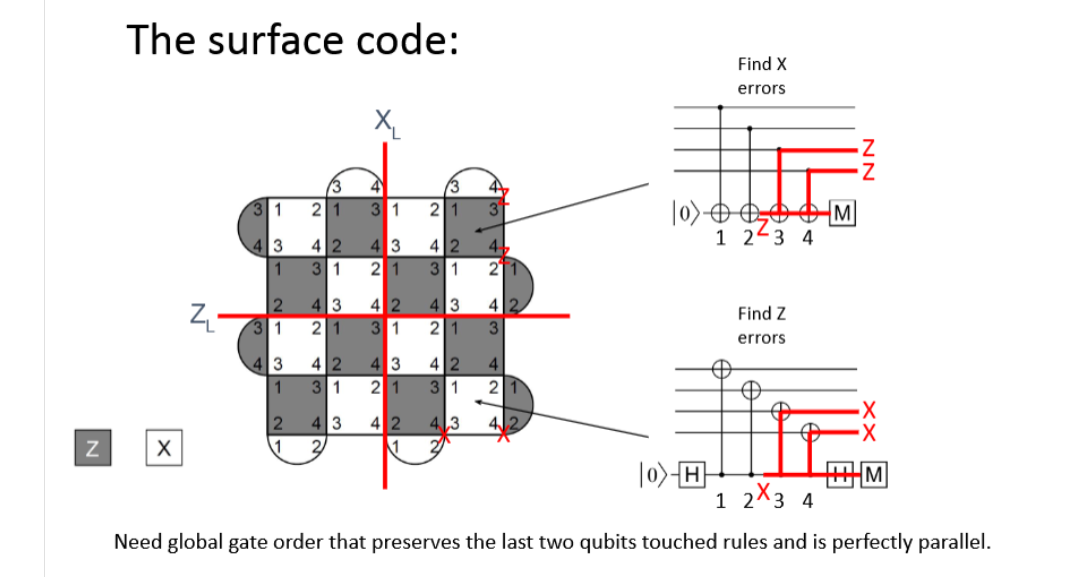



---------------------



Convert to checkerboard: for X stabilizer look at where the target lands and the corresponding number (1 to 4)



For Z stabilizer look at the controls

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_v5(
            12, xorder, zorder, error_rate
        ),
        json_metadata={
            'X order': xorder,
            'Z order': zorder,
            'error rate': error_rate,
            'run_id': run_id,
        },
    )
    for xorder in itertools.permutations([1, 2, 3, 4])
    for zorder in itertools.permutations([1, 2, 3, 4])
    for error_rate in np.linspace(0.0005, 0.0005, 1)   # do one error rate for now to check 
    for run_id in range(NUM_RUNS_PER_ERROR_RATE)
]


In [ ]:
collected_surface_code_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)


In [ ]:
from collections import defaultdict

# (xorder, zorder, error_rate) -> list of LERs from repeated runs
run_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    key = (
        tuple(meta['X order']),
        tuple(meta['Z order']),
        meta['error rate'],
    )
    ler = stat.errors / stat.shots
    run_data[key].append(ler)


In [ ]:
# (xorder, zorder) -> list of (error_rate, avg_ler_over_runs)
order_data = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    avg_ler = np.mean(lers)
    order_data[(xorder, zorder)].append((p, avg_ler))


In [ ]:
order_score = []

for order, data in order_data.items():
    avg_ler_over_runs = np.mean([ler for _, ler in data])
    order_score.append((avg_ler_over_runs, order))

order_score.sort(key=lambda x: x[0])
top_10_orders = order_score[:10]


In [ ]:
plt.figure(figsize=(10, 7))

for rank, (_, order) in enumerate(top_10_orders, start=1):
    data = sorted(order_data[order], key=lambda x: x[0])
    ps = [d[0] for d in data]
    lers = [d[1] for d in data]

    plt.plot(ps, lers, marker='o',
             label=f"{rank}: X={order[0]}, Z={order[1]}")

plt.xlabel("Physical Error Rate")
plt.ylabel("Logical Error Rate")
plt.yscale("log")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
print(run_data)
# the difference in each run is sometimes larger than the effect of changing the gate order...?
# there are significant differences when changing to certain gate order
#{((X order),(Z order), physical error rate): [LER1 LER2 LER3 LER4 LER5], ...}

In [ ]:
#Try grouping the ones whose LER range overlaps...

from collections import defaultdict

# p -> list of (order, min_ler, max_ler)
intervals_by_p = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    intervals_by_p[p].append(
        ((xorder, zorder), min(lers), max(lers))
    )


def intervals_overlap(a_min, a_max, b_min, b_max):
    return not (a_max < b_min or b_max < a_min)

def group_overlapping_intervals(interval_list):
    """
    interval_list: [(order, min_ler, max_ler), ...]
    returns: list of groups, each group is a list of orders
    """
    groups = []
    used = set()

    for i, (order_i, min_i, max_i) in enumerate(interval_list):
        if i in used:
            continue

        group = [order_i]
        used.add(i)

        changed = True
        while changed:
            changed = False
            for j, (order_j, min_j, max_j) in enumerate(interval_list):
                if j in used:
                    continue
                if any(
                    intervals_overlap(min_j, max_j,
                                      interval_list[k][1],
                                      interval_list[k][2])
                    for k in used
                ):
                    group.append(order_j)
                    used.add(j)
                    changed = True

        groups.append(group)

    return groups

overlap_groups_by_p = {}

for p, interval_list in intervals_by_p.items():
    overlap_groups_by_p[p] = group_overlapping_intervals(interval_list)
for p, groups in overlap_groups_by_p.items():
    print(f"\nError rate p={p}")
    for i, g in enumerate(groups, 1):
        print(f"  Group {i}: {len(g)} orders")


for p, groups in overlap_groups_by_p.items():
    for i, group in enumerate(groups, 1):
        print(f"p={p:.4g} | group {i}: {group}")



3 "groups" non overlapping... is this expected? probably (not)?


Either X or Z error perpendicular to logical; both, or neither


group 3 is neither (best)


group 2 is one alligned with logical 


group 1 is both alligned with logical (worst)


???

------




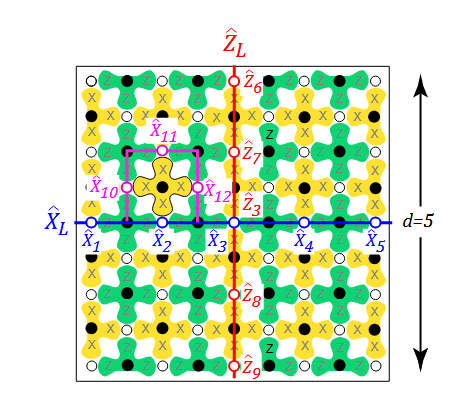



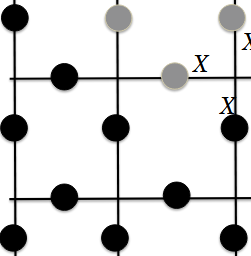


^ logical Z


-> logical x



our code is rotated 90 degrees

--------




p=0.0005 | group 1: [((1, 2, 3, 4), (1, 2, 3, 4)), ((1, 2, 3, 4), (1, 2, 4, 3)), ((1, 2, 3, 4), (1, 4, 2, 3)), ((1, 2, 3, 4), (2, 1, 3, 4)), ((1, 2, 3, 4), (2, 1, 4, 3)), ((1, 2, 3, 4), (2, 3, 1, 4)), ((1, 2, 3, 4), (3, 2, 4, 1)), ((1, 2, 3, 4), (3, 4, 1, 2)), ((1, 2, 3, 4), (3, 4, 2, 1)), ((1, 2, 3, 4), (4, 1, 3, 2)), ((1, 2, 3, 4), (4, 2, 1, 3)), ((1, 2, 3, 4), (4, 2, 3, 1)), ((1, 2, 3, 4), (4, 3, 1, 2)), ((1, 2, 3, 4), (4, 3, 2, 1)), ((1, 3, 2, 4), (1, 2, 3, 4)), ((1, 3, 2, 4), (1, 2, 4, 3)), ((1, 3, 2, 4), (1, 3, 2, 4)), ((1, 3, 2, 4), (1, 3, 4, 2)), ((1, 3, 2, 4), (1, 4, 2, 3)), ((1, 3, 2, 4), (1, 4, 3, 2)), ((1, 3, 2, 4), (2, 1, 3, 4)), ((1, 3, 2, 4), (2, 1, 4, 3)), ((1, 3, 2, 4), (2, 3, 1, 4)), ((1, 3, 2, 4), (2, 3, 4, 1)), ((1, 3, 2, 4), (2, 4, 1, 3)), ((1, 3, 2, 4), (2, 4, 3, 1)), ((1, 3, 2, 4), (3, 1, 2, 4)), ((1, 3, 2, 4), (3, 1, 4, 2)), ((1, 3, 2, 4), (3, 2, 1, 4)), ((1, 3, 2, 4), (3, 2, 4, 1)), ((1, 3, 2, 4), (3, 4, 1, 2)), ((1, 3, 2, 4), (3, 4, 2, 1)), ((1, 3, 2, 4), (4, 1, 2, 3)), ((1, 3, 2, 4), (4, 1, 3, 2)), ((1, 3, 2, 4), (4, 2, 1, 3)), ((1, 3, 2, 4), (4, 2, 3, 1)), ((1, 3, 2, 4), (4, 3, 1, 2)), ((1, 3, 2, 4), (4, 3, 2, 1)), ((4, 2, 3, 1), (1, 2, 3, 4)), ((4, 2, 3, 1), (1, 2, 4, 3)), ((4, 2, 3, 1), (1, 3, 2, 4)), ((4, 2, 3, 1), (1, 3, 4, 2)), ((4, 2, 3, 1), (1, 4, 2, 3)), ((4, 2, 3, 1), (1, 4, 3, 2)), ((4, 2, 3, 1), (2, 1, 3, 4)), ((4, 2, 3, 1), (2, 1, 4, 3)), ((4, 2, 3, 1), (2, 3, 1, 4)), ((4, 2, 3, 1), (2, 3, 4, 1)), ((4, 2, 3, 1), (2, 4, 1, 3)), ((4, 2, 3, 1), (2, 4, 3, 1)), ((4, 2, 3, 1), (3, 1, 2, 4)), ((4, 2, 3, 1), (3, 1, 4, 2)), ((4, 2, 3, 1), (3, 2, 1, 4)), ((4, 2, 3, 1), (3, 2, 4, 1)), ((4, 2, 3, 1), (3, 4, 1, 2)), ((4, 2, 3, 1), (3, 4, 2, 1)), ((4, 2, 3, 1), (4, 1, 2, 3)), ((4, 2, 3, 1), (4, 1, 3, 2)), ((4, 2, 3, 1), (4, 2, 1, 3)), ((4, 2, 3, 1), (4, 2, 3, 1)), ((4, 2, 3, 1), (4, 3, 1, 2)), ((4, 2, 3, 1), (4, 3, 2, 1)), ((4, 3, 2, 1), (1, 2, 3, 4)), ((4, 3, 2, 1), (1, 2, 4, 3)), ((4, 3, 2, 1), (1, 3, 2, 4)), ((4, 3, 2, 1), (1, 3, 4, 2)), ((4, 3, 2, 1), (1, 4, 2, 3)), ((4, 3, 2, 1), (1, 4, 3, 2)), ((4, 3, 2, 1), (2, 1, 3, 4)), ((4, 3, 2, 1), (2, 1, 4, 3)), ((4, 3, 2, 1), (2, 3, 1, 4)), ((4, 3, 2, 1), (2, 3, 4, 1)), ((4, 3, 2, 1), (2, 4, 1, 3)), ((4, 3, 2, 1), (2, 4, 3, 1)), ((4, 3, 2, 1), (3, 1, 2, 4)), ((4, 3, 2, 1), (3, 1, 4, 2)), ((4, 3, 2, 1), (3, 2, 1, 4)), ((4, 3, 2, 1), (3, 2, 4, 1)), ((4, 3, 2, 1), (3, 4, 1, 2)), ((4, 3, 2, 1), (3, 4, 2, 1)), ((4, 3, 2, 1), (4, 1, 2, 3)), ((4, 3, 2, 1), (4, 1, 3, 2)), ((4, 3, 2, 1), (4, 2, 1, 3)), ((4, 3, 2, 1), (4, 2, 3, 1)), ((4, 3, 2, 1), (4, 3, 1, 2)), ((4, 3, 2, 1), (4, 3, 2, 1)), ((1, 2, 3, 4), (1, 3, 2, 4)), ((1, 2, 3, 4), (1, 3, 4, 2)), ((1, 2, 3, 4), (1, 4, 3, 2)), ((1, 2, 3, 4), (2, 3, 4, 1)), ((1, 2, 3, 4), (2, 4, 1, 3)), ((1, 2, 3, 4), (2, 4, 3, 1)), ((1, 2, 3, 4), (3, 1, 2, 4)), ((1, 2, 3, 4), (3, 1, 4, 2)), ((1, 2, 3, 4), (3, 2, 1, 4)), ((1, 2, 3, 4), (4, 1, 2, 3))]
p=0.0005 | group 2: [((1, 2, 4, 3), (1, 2, 3, 4)), ((1, 2, 4, 3), (1, 2, 4, 3)), ((1, 2, 4, 3), (1, 4, 2, 3)), ((1, 2, 4, 3), (2, 1, 3, 4)), ((1, 2, 4, 3), (2, 1, 4, 3)), ((1, 2, 4, 3), (2, 3, 1, 4)), ((1, 2, 4, 3), (2, 3, 4, 1)), ((1, 2, 4, 3), (2, 4, 1, 3)), ((1, 2, 4, 3), (2, 4, 3, 1)), ((1, 2, 4, 3), (3, 1, 2, 4)), ((1, 2, 4, 3), (3, 1, 4, 2)), ((1, 2, 4, 3), (3, 2, 1, 4)), ((1, 2, 4, 3), (3, 2, 4, 1)), ((1, 2, 4, 3), (3, 4, 1, 2)), ((1, 2, 4, 3), (3, 4, 2, 1)), ((1, 2, 4, 3), (4, 1, 2, 3)), ((1, 2, 4, 3), (4, 1, 3, 2)), ((1, 2, 4, 3), (4, 2, 1, 3)), ((1, 2, 4, 3), (4, 2, 3, 1)), ((1, 2, 4, 3), (4, 3, 1, 2)), ((1, 2, 4, 3), (4, 3, 2, 1)), ((1, 3, 4, 2), (1, 2, 3, 4)), ((1, 3, 4, 2), (1, 2, 4, 3)), ((1, 3, 4, 2), (1, 3, 2, 4)), ((1, 3, 4, 2), (1, 3, 4, 2)), ((1, 3, 4, 2), (1, 4, 2, 3)), ((1, 3, 4, 2), (1, 4, 3, 2)), ((1, 3, 4, 2), (2, 1, 3, 4)), ((1, 3, 4, 2), (2, 1, 4, 3)), ((1, 3, 4, 2), (2, 3, 1, 4)), ((1, 3, 4, 2), (2, 3, 4, 1)), ((1, 3, 4, 2), (2, 4, 1, 3)), ((1, 3, 4, 2), (2, 4, 3, 1)), ((1, 3, 4, 2), (3, 1, 2, 4)), ((1, 3, 4, 2), (3, 1, 4, 2)), ((1, 3, 4, 2), (3, 2, 1, 4)), ((1, 3, 4, 2), (3, 2, 4, 1)), ((1, 3, 4, 2), (3, 4, 1, 2)), ((1, 3, 4, 2), (3, 4, 2, 1)), ((1, 3, 4, 2), (4, 1, 2, 3)), ((1, 3, 4, 2), (4, 1, 3, 2)), ((1, 3, 4, 2), (4, 2, 1, 3)), ((1, 3, 4, 2), (4, 2, 3, 1)), ((1, 3, 4, 2), (4, 3, 1, 2)), ((1, 3, 4, 2), (4, 3, 2, 1)), ((2, 1, 3, 4), (1, 2, 3, 4)), ((2, 1, 3, 4), (1, 2, 4, 3)), ((2, 1, 3, 4), (1, 3, 2, 4)), ((2, 1, 3, 4), (1, 3, 4, 2)), ((2, 1, 3, 4), (1, 4, 2, 3)), ((2, 1, 3, 4), (1, 4, 3, 2)), ((2, 1, 3, 4), (2, 1, 3, 4)), ((2, 1, 3, 4), (2, 1, 4, 3)), ((2, 1, 3, 4), (2, 3, 1, 4)), ((2, 1, 3, 4), (2, 3, 4, 1)), ((2, 1, 3, 4), (2, 4, 1, 3)), ((2, 1, 3, 4), (2, 4, 3, 1)), ((2, 1, 3, 4), (3, 1, 2, 4)), ((2, 1, 3, 4), (3, 1, 4, 2)), ((2, 1, 3, 4), (3, 2, 1, 4)), ((2, 1, 3, 4), (3, 2, 4, 1)), ((2, 1, 3, 4), (3, 4, 1, 2)), ((2, 1, 3, 4), (3, 4, 2, 1)), ((2, 1, 3, 4), (4, 1, 2, 3)), ((2, 1, 3, 4), (4, 1, 3, 2)), ((2, 1, 3, 4), (4, 2, 1, 3)), ((2, 1, 3, 4), (4, 2, 3, 1)), ((2, 1, 3, 4), (4, 3, 1, 2)), ((2, 1, 3, 4), (4, 3, 2, 1)), ((2, 4, 3, 1), (1, 2, 3, 4)), ((2, 4, 3, 1), (1, 2, 4, 3)), ((2, 4, 3, 1), (1, 3, 2, 4)), ((2, 4, 3, 1), (1, 3, 4, 2)), ((2, 4, 3, 1), (1, 4, 2, 3)), ((2, 4, 3, 1), (1, 4, 3, 2)), ((2, 4, 3, 1), (2, 1, 3, 4)), ((2, 4, 3, 1), (2, 1, 4, 3)), ((2, 4, 3, 1), (2, 3, 1, 4)), ((2, 4, 3, 1), (2, 3, 4, 1)), ((2, 4, 3, 1), (2, 4, 1, 3)), ((2, 4, 3, 1), (2, 4, 3, 1)), ((2, 4, 3, 1), (3, 1, 2, 4)), ((2, 4, 3, 1), (3, 1, 4, 2)), ((2, 4, 3, 1), (3, 2, 1, 4)), ((2, 4, 3, 1), (3, 2, 4, 1)), ((2, 4, 3, 1), (3, 4, 1, 2)), ((2, 4, 3, 1), (3, 4, 2, 1)), ((2, 4, 3, 1), (4, 1, 2, 3)), ((2, 4, 3, 1), (4, 1, 3, 2)), ((2, 4, 3, 1), (4, 2, 1, 3)), ((2, 4, 3, 1), (4, 2, 3, 1)), ((2, 4, 3, 1), (4, 3, 1, 2)), ((2, 4, 3, 1), (4, 3, 2, 1)), ((3, 1, 2, 4), (1, 2, 3, 4)), ((3, 1, 2, 4), (1, 2, 4, 3)), ((3, 1, 2, 4), (1, 3, 2, 4)), ((3, 1, 2, 4), (1, 3, 4, 2)), ((3, 1, 2, 4), (1, 4, 2, 3)), ((3, 1, 2, 4), (1, 4, 3, 2)), ((3, 1, 2, 4), (2, 1, 3, 4)), ((3, 1, 2, 4), (2, 1, 4, 3)), ((3, 1, 2, 4), (2, 3, 1, 4)), ((3, 1, 2, 4), (2, 3, 4, 1)), ((3, 1, 2, 4), (2, 4, 1, 3)), ((3, 1, 2, 4), (2, 4, 3, 1)), ((3, 1, 2, 4), (3, 1, 2, 4)), ((3, 1, 2, 4), (3, 1, 4, 2)), ((3, 1, 2, 4), (3, 2, 1, 4)), ((3, 1, 2, 4), (3, 2, 4, 1)), ((3, 1, 2, 4), (3, 4, 1, 2)), ((3, 1, 2, 4), (3, 4, 2, 1)), ((3, 1, 2, 4), (4, 1, 2, 3)), ((3, 1, 2, 4), (4, 1, 3, 2)), ((3, 1, 2, 4), (4, 2, 1, 3)), ((3, 1, 2, 4), (4, 2, 3, 1)), ((3, 1, 2, 4), (4, 3, 1, 2)), ((3, 1, 2, 4), (4, 3, 2, 1)), ((3, 4, 2, 1), (1, 2, 3, 4)), ((3, 4, 2, 1), (1, 2, 4, 3)), ((3, 4, 2, 1), (1, 3, 2, 4)), ((3, 4, 2, 1), (1, 3, 4, 2)), ((3, 4, 2, 1), (1, 4, 2, 3)), ((3, 4, 2, 1), (1, 4, 3, 2)), ((3, 4, 2, 1), (2, 1, 3, 4)), ((3, 4, 2, 1), (2, 1, 4, 3)), ((3, 4, 2, 1), (2, 3, 1, 4)), ((3, 4, 2, 1), (2, 3, 4, 1)), ((3, 4, 2, 1), (2, 4, 1, 3)), ((3, 4, 2, 1), (2, 4, 3, 1)), ((3, 4, 2, 1), (3, 1, 2, 4)), ((3, 4, 2, 1), (3, 1, 4, 2)), ((3, 4, 2, 1), (3, 2, 1, 4)), ((3, 4, 2, 1), (3, 2, 4, 1)), ((3, 4, 2, 1), (3, 4, 1, 2)), ((3, 4, 2, 1), (3, 4, 2, 1)), ((3, 4, 2, 1), (4, 1, 2, 3)), ((3, 4, 2, 1), (4, 1, 3, 2)), ((3, 4, 2, 1), (4, 2, 1, 3)), ((3, 4, 2, 1), (4, 2, 3, 1)), ((3, 4, 2, 1), (4, 3, 1, 2)), ((3, 4, 2, 1), (4, 3, 2, 1)), ((4, 2, 1, 3), (1, 2, 3, 4)), ((4, 2, 1, 3), (1, 2, 4, 3)), ((4, 2, 1, 3), (1, 3, 2, 4)), ((4, 2, 1, 3), (1, 3, 4, 2)), ((4, 2, 1, 3), (1, 4, 2, 3)), ((4, 2, 1, 3), (1, 4, 3, 2)), ((4, 2, 1, 3), (2, 1, 3, 4)), ((4, 2, 1, 3), (2, 1, 4, 3)), ((4, 2, 1, 3), (2, 3, 1, 4)), ((4, 2, 1, 3), (2, 3, 4, 1)), ((4, 2, 1, 3), (2, 4, 1, 3)), ((4, 2, 1, 3), (2, 4, 3, 1)), ((4, 2, 1, 3), (3, 1, 2, 4)), ((4, 2, 1, 3), (3, 1, 4, 2)), ((4, 2, 1, 3), (3, 2, 1, 4)), ((4, 2, 1, 3), (3, 2, 4, 1)), ((4, 2, 1, 3), (3, 4, 1, 2)), ((4, 2, 1, 3), (3, 4, 2, 1)), ((4, 2, 1, 3), (4, 1, 2, 3)), ((4, 2, 1, 3), (4, 1, 3, 2)), ((4, 2, 1, 3), (4, 2, 1, 3)), ((4, 2, 1, 3), (4, 2, 3, 1)), ((4, 2, 1, 3), (4, 3, 1, 2)), ((4, 2, 1, 3), (4, 3, 2, 1)), ((4, 3, 1, 2), (1, 2, 3, 4)), ((4, 3, 1, 2), (1, 2, 4, 3)), ((4, 3, 1, 2), (1, 3, 2, 4)), ((4, 3, 1, 2), (1, 3, 4, 2)), ((4, 3, 1, 2), (1, 4, 2, 3)), ((4, 3, 1, 2), (1, 4, 3, 2)), ((4, 3, 1, 2), (2, 1, 3, 4)), ((4, 3, 1, 2), (2, 1, 4, 3)), ((4, 3, 1, 2), (2, 3, 1, 4)), ((4, 3, 1, 2), (2, 3, 4, 1)), ((4, 3, 1, 2), (2, 4, 1, 3)), ((4, 3, 1, 2), (2, 4, 3, 1)), ((4, 3, 1, 2), (3, 1, 2, 4)), ((4, 3, 1, 2), (3, 1, 4, 2)), ((4, 3, 1, 2), (3, 2, 1, 4)), ((4, 3, 1, 2), (3, 2, 4, 1)), ((4, 3, 1, 2), (3, 4, 1, 2)), ((4, 3, 1, 2), (3, 4, 2, 1)), ((4, 3, 1, 2), (4, 1, 2, 3)), ((4, 3, 1, 2), (4, 1, 3, 2)), ((4, 3, 1, 2), (4, 2, 1, 3)), ((4, 3, 1, 2), (4, 2, 3, 1)), ((4, 3, 1, 2), (4, 3, 1, 2)), ((4, 3, 1, 2), (4, 3, 2, 1)), ((1, 2, 4, 3), (1, 3, 2, 4)), ((1, 2, 4, 3), (1, 3, 4, 2)), ((1, 2, 4, 3), (1, 4, 3, 2))]
p=0.0005 | group 3: [((1, 4, 2, 3), (1, 2, 3, 4)), ((1, 4, 2, 3), (1, 2, 4, 3)), ((1, 4, 2, 3), (1, 3, 2, 4)), ((1, 4, 2, 3), (1, 3, 4, 2)), ((1, 4, 2, 3), (1, 4, 2, 3)), ((1, 4, 2, 3), (1, 4, 3, 2)), ((1, 4, 2, 3), (2, 1, 3, 4)), ((1, 4, 2, 3), (2, 1, 4, 3)), ((1, 4, 2, 3), (2, 3, 1, 4)), ((1, 4, 2, 3), (2, 3, 4, 1)), ((1, 4, 2, 3), (2, 4, 1, 3)), ((1, 4, 2, 3), (2, 4, 3, 1)), ((1, 4, 2, 3), (3, 1, 2, 4)), ((1, 4, 2, 3), (3, 1, 4, 2)), ((1, 4, 2, 3), (3, 2, 1, 4)), ((1, 4, 2, 3), (3, 2, 4, 1)), ((1, 4, 2, 3), (3, 4, 1, 2)), ((1, 4, 2, 3), (3, 4, 2, 1)), ((1, 4, 2, 3), (4, 1, 2, 3)), ((1, 4, 2, 3), (4, 1, 3, 2)), ((1, 4, 2, 3), (4, 2, 1, 3)), ((1, 4, 2, 3), (4, 2, 3, 1)), ((1, 4, 2, 3), (4, 3, 1, 2)), ((1, 4, 2, 3), (4, 3, 2, 1)), ((1, 4, 3, 2), (1, 2, 3, 4)), ((1, 4, 3, 2), (1, 2, 4, 3)), ((1, 4, 3, 2), (1, 3, 2, 4)), ((1, 4, 3, 2), (1, 3, 4, 2)), ((1, 4, 3, 2), (1, 4, 2, 3)), ((1, 4, 3, 2), (1, 4, 3, 2)), ((1, 4, 3, 2), (2, 1, 3, 4)), ((1, 4, 3, 2), (2, 1, 4, 3)), ((1, 4, 3, 2), (2, 3, 1, 4)), ((1, 4, 3, 2), (2, 3, 4, 1)), ((1, 4, 3, 2), (2, 4, 1, 3)), ((1, 4, 3, 2), (2, 4, 3, 1)), ((1, 4, 3, 2), (3, 1, 2, 4)), ((1, 4, 3, 2), (3, 1, 4, 2)), ((1, 4, 3, 2), (3, 2, 1, 4)), ((1, 4, 3, 2), (3, 2, 4, 1)), ((1, 4, 3, 2), (3, 4, 1, 2)), ((1, 4, 3, 2), (3, 4, 2, 1)), ((1, 4, 3, 2), (4, 1, 2, 3)), ((1, 4, 3, 2), (4, 1, 3, 2)), ((1, 4, 3, 2), (4, 2, 1, 3)), ((1, 4, 3, 2), (4, 2, 3, 1)), ((1, 4, 3, 2), (4, 3, 1, 2)), ((1, 4, 3, 2), (4, 3, 2, 1)), ((2, 1, 4, 3), (1, 3, 2, 4)), ((2, 1, 4, 3), (1, 3, 4, 2)), ((2, 1, 4, 3), (1, 4, 3, 2)), ((2, 1, 4, 3), (2, 3, 4, 1)), ((2, 1, 4, 3), (2, 4, 1, 3)), ((2, 1, 4, 3), (2, 4, 3, 1)), ((2, 1, 4, 3), (3, 1, 2, 4)), ((2, 1, 4, 3), (3, 1, 4, 2)), ((2, 1, 4, 3), (3, 2, 1, 4)), ((2, 1, 4, 3), (4, 1, 2, 3)), ((2, 1, 4, 3), (4, 2, 1, 3)), ((2, 1, 4, 3), (4, 2, 3, 1)), ((2, 3, 1, 4), (1, 2, 3, 4)), ((2, 3, 1, 4), (1, 2, 4, 3)), ((2, 3, 1, 4), (1, 3, 2, 4)), ((2, 3, 1, 4), (1, 3, 4, 2)), ((2, 3, 1, 4), (1, 4, 2, 3)), ((2, 3, 1, 4), (1, 4, 3, 2)), ((2, 3, 1, 4), (2, 1, 3, 4)), ((2, 3, 1, 4), (2, 1, 4, 3)), ((2, 3, 1, 4), (2, 3, 1, 4)), ((2, 3, 1, 4), (2, 3, 4, 1)), ((2, 3, 1, 4), (2, 4, 1, 3)), ((2, 3, 1, 4), (2, 4, 3, 1)), ((2, 3, 1, 4), (3, 1, 2, 4)), ((2, 3, 1, 4), (3, 1, 4, 2)), ((2, 3, 1, 4), (3, 2, 1, 4)), ((2, 3, 1, 4), (3, 2, 4, 1)), ((2, 3, 1, 4), (3, 4, 1, 2)), ((2, 3, 1, 4), (3, 4, 2, 1)), ((2, 3, 1, 4), (4, 1, 2, 3)), ((2, 3, 1, 4), (4, 1, 3, 2)), ((2, 3, 1, 4), (4, 2, 1, 3)), ((2, 3, 1, 4), (4, 2, 3, 1)), ((2, 3, 1, 4), (4, 3, 1, 2)), ((2, 3, 1, 4), (4, 3, 2, 1)), ((2, 3, 4, 1), (1, 2, 3, 4)), ((2, 3, 4, 1), (1, 2, 4, 3)), ((2, 3, 4, 1), (1, 3, 2, 4)), ((2, 3, 4, 1), (1, 3, 4, 2)), ((2, 3, 4, 1), (1, 4, 2, 3)), ((2, 3, 4, 1), (1, 4, 3, 2)), ((2, 3, 4, 1), (2, 1, 3, 4)), ((2, 3, 4, 1), (2, 1, 4, 3)), ((2, 3, 4, 1), (2, 3, 1, 4)), ((2, 3, 4, 1), (2, 3, 4, 1)), ((2, 3, 4, 1), (2, 4, 1, 3)), ((2, 3, 4, 1), (2, 4, 3, 1)), ((2, 3, 4, 1), (3, 1, 2, 4)), ((2, 3, 4, 1), (3, 1, 4, 2)), ((2, 3, 4, 1), (3, 2, 1, 4)), ((2, 3, 4, 1), (3, 2, 4, 1)), ((2, 3, 4, 1), (3, 4, 1, 2)), ((2, 3, 4, 1), (3, 4, 2, 1)), ((2, 3, 4, 1), (4, 1, 2, 3)), ((2, 3, 4, 1), (4, 1, 3, 2)), ((2, 3, 4, 1), (4, 2, 1, 3)), ((2, 3, 4, 1), (4, 2, 3, 1)), ((2, 3, 4, 1), (4, 3, 1, 2)), ((2, 3, 4, 1), (4, 3, 2, 1)), ((2, 4, 1, 3), (1, 2, 3, 4)), ((2, 4, 1, 3), (1, 2, 4, 3)), ((2, 4, 1, 3), (1, 3, 2, 4)), ((2, 4, 1, 3), (1, 3, 4, 2)), ((2, 4, 1, 3), (1, 4, 2, 3)), ((2, 4, 1, 3), (1, 4, 3, 2)), ((2, 4, 1, 3), (2, 1, 3, 4)), ((2, 4, 1, 3), (2, 1, 4, 3)), ((2, 4, 1, 3), (2, 3, 1, 4)), ((2, 4, 1, 3), (2, 3, 4, 1)), ((2, 4, 1, 3), (2, 4, 1, 3)), ((2, 4, 1, 3), (2, 4, 3, 1)), ((2, 4, 1, 3), (3, 1, 2, 4)), ((2, 4, 1, 3), (3, 1, 4, 2)), ((2, 4, 1, 3), (3, 2, 1, 4)), ((2, 4, 1, 3), (3, 2, 4, 1)), ((2, 4, 1, 3), (3, 4, 1, 2)), ((2, 4, 1, 3), (3, 4, 2, 1)), ((2, 4, 1, 3), (4, 1, 2, 3)), ((2, 4, 1, 3), (4, 1, 3, 2)), ((2, 4, 1, 3), (4, 2, 1, 3)), ((2, 4, 1, 3), (4, 2, 3, 1)), ((2, 4, 1, 3), (4, 3, 1, 2)), ((2, 4, 1, 3), (4, 3, 2, 1)), ((3, 1, 4, 2), (1, 2, 3, 4)), ((3, 1, 4, 2), (1, 2, 4, 3)), ((3, 1, 4, 2), (1, 3, 2, 4)), ((3, 1, 4, 2), (1, 3, 4, 2)), ((3, 1, 4, 2), (1, 4, 2, 3)), ((3, 1, 4, 2), (1, 4, 3, 2)), ((3, 1, 4, 2), (2, 1, 3, 4)), ((3, 1, 4, 2), (2, 1, 4, 3)), ((3, 1, 4, 2), (2, 3, 1, 4)), ((3, 1, 4, 2), (2, 3, 4, 1)), ((3, 1, 4, 2), (2, 4, 1, 3)), ((3, 1, 4, 2), (2, 4, 3, 1)), ((3, 1, 4, 2), (3, 1, 2, 4)), ((3, 1, 4, 2), (3, 1, 4, 2)), ((3, 1, 4, 2), (3, 2, 1, 4)), ((3, 1, 4, 2), (3, 2, 4, 1)), ((3, 1, 4, 2), (3, 4, 1, 2)), ((3, 1, 4, 2), (3, 4, 2, 1)), ((3, 1, 4, 2), (4, 1, 2, 3)), ((3, 1, 4, 2), (4, 1, 3, 2)), ((3, 1, 4, 2), (4, 2, 1, 3)), ((3, 1, 4, 2), (4, 2, 3, 1)), ((3, 1, 4, 2), (4, 3, 1, 2)), ((3, 1, 4, 2), (4, 3, 2, 1)), ((3, 2, 1, 4), (1, 2, 3, 4)), ((3, 2, 1, 4), (1, 2, 4, 3)), ((3, 2, 1, 4), (1, 3, 2, 4)), ((3, 2, 1, 4), (1, 3, 4, 2)), ((3, 2, 1, 4), (1, 4, 2, 3)), ((3, 2, 1, 4), (1, 4, 3, 2)), ((3, 2, 1, 4), (2, 1, 3, 4)), ((3, 2, 1, 4), (2, 1, 4, 3)), ((3, 2, 1, 4), (2, 3, 1, 4)), ((3, 2, 1, 4), (2, 3, 4, 1)), ((3, 2, 1, 4), (2, 4, 1, 3)), ((3, 2, 1, 4), (2, 4, 3, 1)), ((3, 2, 1, 4), (3, 1, 2, 4)), ((3, 2, 1, 4), (3, 1, 4, 2)), ((3, 2, 1, 4), (3, 2, 1, 4)), ((3, 2, 1, 4), (3, 2, 4, 1)), ((3, 2, 1, 4), (3, 4, 1, 2)), ((3, 2, 1, 4), (3, 4, 2, 1)), ((3, 2, 1, 4), (4, 1, 2, 3)), ((3, 2, 1, 4), (4, 1, 3, 2)), ((3, 2, 1, 4), (4, 2, 1, 3)), ((3, 2, 1, 4), (4, 2, 3, 1)), ((3, 2, 1, 4), (4, 3, 1, 2)), ((3, 2, 1, 4), (4, 3, 2, 1)), ((3, 2, 4, 1), (1, 2, 3, 4)), ((3, 2, 4, 1), (1, 2, 4, 3)), ((3, 2, 4, 1), (1, 3, 2, 4)), ((3, 2, 4, 1), (1, 3, 4, 2)), ((3, 2, 4, 1), (1, 4, 2, 3)), ((3, 2, 4, 1), (1, 4, 3, 2)), ((3, 2, 4, 1), (2, 1, 3, 4)), ((3, 2, 4, 1), (2, 1, 4, 3)), ((3, 2, 4, 1), (2, 3, 1, 4)), ((3, 2, 4, 1), (2, 3, 4, 1)), ((3, 2, 4, 1), (2, 4, 1, 3)), ((3, 2, 4, 1), (2, 4, 3, 1)), ((3, 2, 4, 1), (3, 1, 2, 4)), ((3, 2, 4, 1), (3, 1, 4, 2)), ((3, 2, 4, 1), (3, 2, 1, 4)), ((3, 2, 4, 1), (3, 2, 4, 1)), ((3, 2, 4, 1), (3, 4, 1, 2)), ((3, 2, 4, 1), (3, 4, 2, 1)), ((3, 2, 4, 1), (4, 1, 2, 3)), ((3, 2, 4, 1), (4, 1, 3, 2)), ((3, 2, 4, 1), (4, 2, 1, 3)), ((3, 2, 4, 1), (4, 2, 3, 1)), ((3, 2, 4, 1), (4, 3, 1, 2)), ((3, 2, 4, 1), (4, 3, 2, 1)), ((3, 4, 1, 2), (1, 2, 3, 4)), ((3, 4, 1, 2), (1, 2, 4, 3)), ((3, 4, 1, 2), (1, 3, 2, 4)), ((3, 4, 1, 2), (1, 3, 4, 2)), ((3, 4, 1, 2), (1, 4, 2, 3)), ((3, 4, 1, 2), (1, 4, 3, 2)), ((3, 4, 1, 2), (2, 1, 3, 4)), ((3, 4, 1, 2), (2, 1, 4, 3)), ((3, 4, 1, 2), (2, 3, 1, 4)), ((3, 4, 1, 2), (2, 3, 4, 1)), ((3, 4, 1, 2), (2, 4, 1, 3)), ((3, 4, 1, 2), (2, 4, 3, 1)), ((3, 4, 1, 2), (3, 1, 2, 4)), ((3, 4, 1, 2), (3, 1, 4, 2)), ((3, 4, 1, 2), (3, 2, 1, 4)), ((3, 4, 1, 2), (3, 2, 4, 1)), ((3, 4, 1, 2), (3, 4, 1, 2)), ((3, 4, 1, 2), (3, 4, 2, 1)), ((3, 4, 1, 2), (4, 1, 2, 3)), ((3, 4, 1, 2), (4, 1, 3, 2)), ((3, 4, 1, 2), (4, 2, 1, 3)), ((3, 4, 1, 2), (4, 2, 3, 1)), ((3, 4, 1, 2), (4, 3, 1, 2)), ((3, 4, 1, 2), (4, 3, 2, 1)), ((4, 1, 2, 3), (1, 2, 3, 4)), ((4, 1, 2, 3), (1, 2, 4, 3)), ((4, 1, 2, 3), (1, 3, 2, 4)), ((4, 1, 2, 3), (1, 3, 4, 2)), ((4, 1, 2, 3), (1, 4, 2, 3)), ((4, 1, 2, 3), (1, 4, 3, 2)), ((4, 1, 2, 3), (2, 1, 3, 4)), ((4, 1, 2, 3), (2, 1, 4, 3)), ((4, 1, 2, 3), (2, 3, 1, 4)), ((4, 1, 2, 3), (2, 3, 4, 1)), ((4, 1, 2, 3), (2, 4, 1, 3)), ((4, 1, 2, 3), (2, 4, 3, 1)), ((4, 1, 2, 3), (3, 1, 2, 4)), ((4, 1, 2, 3), (3, 1, 4, 2)), ((4, 1, 2, 3), (3, 2, 1, 4)), ((4, 1, 2, 3), (3, 2, 4, 1)), ((4, 1, 2, 3), (3, 4, 1, 2)), ((4, 1, 2, 3), (3, 4, 2, 1)), ((4, 1, 2, 3), (4, 1, 2, 3)), ((4, 1, 2, 3), (4, 1, 3, 2)), ((4, 1, 2, 3), (4, 2, 1, 3)), ((4, 1, 2, 3), (4, 2, 3, 1)), ((4, 1, 2, 3), (4, 3, 1, 2)), ((4, 1, 2, 3), (4, 3, 2, 1)), ((4, 1, 3, 2), (1, 2, 3, 4)), ((4, 1, 3, 2), (1, 2, 4, 3)), ((4, 1, 3, 2), (1, 3, 2, 4)), ((4, 1, 3, 2), (1, 3, 4, 2)), ((4, 1, 3, 2), (1, 4, 2, 3)), ((4, 1, 3, 2), (1, 4, 3, 2)), ((4, 1, 3, 2), (2, 1, 3, 4)), ((4, 1, 3, 2), (2, 1, 4, 3)), ((4, 1, 3, 2), (2, 3, 1, 4)), ((4, 1, 3, 2), (2, 3, 4, 1)), ((4, 1, 3, 2), (2, 4, 1, 3)), ((4, 1, 3, 2), (2, 4, 3, 1)), ((4, 1, 3, 2), (3, 1, 2, 4)), ((4, 1, 3, 2), (3, 1, 4, 2)), ((4, 1, 3, 2), (3, 2, 1, 4)), ((4, 1, 3, 2), (3, 2, 4, 1)), ((4, 1, 3, 2), (3, 4, 1, 2)), ((4, 1, 3, 2), (3, 4, 2, 1)), ((4, 1, 3, 2), (4, 1, 2, 3)), ((4, 1, 3, 2), (4, 1, 3, 2)), ((4, 1, 3, 2), (4, 2, 1, 3)), ((4, 1, 3, 2), (4, 2, 3, 1)), ((4, 1, 3, 2), (4, 3, 1, 2)), ((4, 1, 3, 2), (4, 3, 2, 1)), ((2, 1, 4, 3), (1, 2, 3, 4)), ((2, 1, 4, 3), (1, 2, 4, 3)), ((2, 1, 4, 3), (1, 4, 2, 3)), ((2, 1, 4, 3), (2, 1, 3, 4)), ((2, 1, 4, 3), (2, 1, 4, 3)), ((2, 1, 4, 3), (2, 3, 1, 4)), ((2, 1, 4, 3), (3, 2, 4, 1)), ((2, 1, 4, 3), (3, 4, 1, 2)), ((2, 1, 4, 3), (3, 4, 2, 1)), ((2, 1, 4, 3), (4, 1, 3, 2)), ((2, 1, 4, 3), (4, 3, 1, 2)), ((2, 1, 4, 3), (4, 3, 2, 1))]


In [ ]:
def group_unique(pairs):
    slot1 = []
    slot2 = []

    for a, b in pairs:
        if a not in slot1:
            slot1.append(a)
        if b not in slot2:
            slot2.append(b)

    return [slot1], [slot2]




testdata = [
    ((1, 2, 3, 4), (1, 2, 3, 4)),
    ((1, 2, 3, 4), (1, 2, 4, 3)),
    ((1, 2, 3, 4), (1, 4, 2, 3)),
    ((4, 3, 2, 1), (1, 2, 3, 4)),
    ((9,9,9,9),(8,8,8,8))
]
print(group_unique(testdata))


group1=[((1, 2, 3, 4), (1, 2, 3, 4)), ((1, 2, 3, 4), (1, 2, 4, 3)), ((1, 2, 3, 4), (1, 4, 2, 3)), ((1, 2, 3, 4), (2, 1, 3, 4)), ((1, 2, 3, 4), (2, 1, 4, 3)), ((1, 2, 3, 4), (2, 3, 1, 4)), ((1, 2, 3, 4), (3, 2, 4, 1)), ((1, 2, 3, 4), (3, 4, 1, 2)), ((1, 2, 3, 4), (3, 4, 2, 1)), ((1, 2, 3, 4), (4, 1, 3, 2)), ((1, 2, 3, 4), (4, 2, 1, 3)), ((1, 2, 3, 4), (4, 2, 3, 1)), ((1, 2, 3, 4), (4, 3, 1, 2)), ((1, 2, 3, 4), (4, 3, 2, 1)), ((1, 3, 2, 4), (1, 2, 3, 4)), ((1, 3, 2, 4), (1, 2, 4, 3)), ((1, 3, 2, 4), (1, 3, 2, 4)), ((1, 3, 2, 4), (1, 3, 4, 2)), ((1, 3, 2, 4), (1, 4, 2, 3)), ((1, 3, 2, 4), (1, 4, 3, 2)), ((1, 3, 2, 4), (2, 1, 3, 4)), ((1, 3, 2, 4), (2, 1, 4, 3)), ((1, 3, 2, 4), (2, 3, 1, 4)), ((1, 3, 2, 4), (2, 3, 4, 1)), ((1, 3, 2, 4), (2, 4, 1, 3)), ((1, 3, 2, 4), (2, 4, 3, 1)), ((1, 3, 2, 4), (3, 1, 2, 4)), ((1, 3, 2, 4), (3, 1, 4, 2)), ((1, 3, 2, 4), (3, 2, 1, 4)), ((1, 3, 2, 4), (3, 2, 4, 1)), ((1, 3, 2, 4), (3, 4, 1, 2)), ((1, 3, 2, 4), (3, 4, 2, 1)), ((1, 3, 2, 4), (4, 1, 2, 3)), ((1, 3, 2, 4), (4, 1, 3, 2)), ((1, 3, 2, 4), (4, 2, 1, 3)), ((1, 3, 2, 4), (4, 2, 3, 1)), ((1, 3, 2, 4), (4, 3, 1, 2)), ((1, 3, 2, 4), (4, 3, 2, 1)), ((4, 2, 3, 1), (1, 2, 3, 4)), ((4, 2, 3, 1), (1, 2, 4, 3)), ((4, 2, 3, 1), (1, 3, 2, 4)), ((4, 2, 3, 1), (1, 3, 4, 2)), ((4, 2, 3, 1), (1, 4, 2, 3)), ((4, 2, 3, 1), (1, 4, 3, 2)), ((4, 2, 3, 1), (2, 1, 3, 4)), ((4, 2, 3, 1), (2, 1, 4, 3)), ((4, 2, 3, 1), (2, 3, 1, 4)), ((4, 2, 3, 1), (2, 3, 4, 1)), ((4, 2, 3, 1), (2, 4, 1, 3)), ((4, 2, 3, 1), (2, 4, 3, 1)), ((4, 2, 3, 1), (3, 1, 2, 4)), ((4, 2, 3, 1), (3, 1, 4, 2)), ((4, 2, 3, 1), (3, 2, 1, 4)), ((4, 2, 3, 1), (3, 2, 4, 1)), ((4, 2, 3, 1), (3, 4, 1, 2)), ((4, 2, 3, 1), (3, 4, 2, 1)), ((4, 2, 3, 1), (4, 1, 2, 3)), ((4, 2, 3, 1), (4, 1, 3, 2)), ((4, 2, 3, 1), (4, 2, 1, 3)), ((4, 2, 3, 1), (4, 2, 3, 1)), ((4, 2, 3, 1), (4, 3, 1, 2)), ((4, 2, 3, 1), (4, 3, 2, 1)), ((4, 3, 2, 1), (1, 2, 3, 4)), ((4, 3, 2, 1), (1, 2, 4, 3)), ((4, 3, 2, 1), (1, 3, 2, 4)), ((4, 3, 2, 1), (1, 3, 4, 2)), ((4, 3, 2, 1), (1, 4, 2, 3)), ((4, 3, 2, 1), (1, 4, 3, 2)), ((4, 3, 2, 1), (2, 1, 3, 4)), ((4, 3, 2, 1), (2, 1, 4, 3)), ((4, 3, 2, 1), (2, 3, 1, 4)), ((4, 3, 2, 1), (2, 3, 4, 1)), ((4, 3, 2, 1), (2, 4, 1, 3)), ((4, 3, 2, 1), (2, 4, 3, 1)), ((4, 3, 2, 1), (3, 1, 2, 4)), ((4, 3, 2, 1), (3, 1, 4, 2)), ((4, 3, 2, 1), (3, 2, 1, 4)), ((4, 3, 2, 1), (3, 2, 4, 1)), ((4, 3, 2, 1), (3, 4, 1, 2)), ((4, 3, 2, 1), (3, 4, 2, 1)), ((4, 3, 2, 1), (4, 1, 2, 3)), ((4, 3, 2, 1), (4, 1, 3, 2)), ((4, 3, 2, 1), (4, 2, 1, 3)), ((4, 3, 2, 1), (4, 2, 3, 1)), ((4, 3, 2, 1), (4, 3, 1, 2)), ((4, 3, 2, 1), (4, 3, 2, 1)), ((1, 2, 3, 4), (1, 3, 2, 4)), ((1, 2, 3, 4), (1, 3, 4, 2)), ((1, 2, 3, 4), (1, 4, 3, 2)), ((1, 2, 3, 4), (2, 3, 4, 1)), ((1, 2, 3, 4), (2, 4, 1, 3)), ((1, 2, 3, 4), (2, 4, 3, 1)), ((1, 2, 3, 4), (3, 1, 2, 4)), ((1, 2, 3, 4), (3, 1, 4, 2)), ((1, 2, 3, 4), (3, 2, 1, 4)), ((1, 2, 3, 4), (4, 1, 2, 3))]

In [ ]:
print("group1")
print("X order: ",group_unique(group1)[0])
print("------")

print("Z order: ",group_unique(group1)[1])

In [ ]:
group2= [((1, 2, 4, 3), (1, 2, 3, 4)), ((1, 2, 4, 3), (1, 2, 4, 3)), ((1, 2, 4, 3), (1, 4, 2, 3)), ((1, 2, 4, 3), (2, 1, 3, 4)), ((1, 2, 4, 3), (2, 1, 4, 3)), ((1, 2, 4, 3), (2, 3, 1, 4)), ((1, 2, 4, 3), (2, 3, 4, 1)), ((1, 2, 4, 3), (2, 4, 1, 3)), ((1, 2, 4, 3), (2, 4, 3, 1)), ((1, 2, 4, 3), (3, 1, 2, 4)), ((1, 2, 4, 3), (3, 1, 4, 2)), ((1, 2, 4, 3), (3, 2, 1, 4)), ((1, 2, 4, 3), (3, 2, 4, 1)), ((1, 2, 4, 3), (3, 4, 1, 2)), ((1, 2, 4, 3), (3, 4, 2, 1)), ((1, 2, 4, 3), (4, 1, 2, 3)), ((1, 2, 4, 3), (4, 1, 3, 2)), ((1, 2, 4, 3), (4, 2, 1, 3)), ((1, 2, 4, 3), (4, 2, 3, 1)), ((1, 2, 4, 3), (4, 3, 1, 2)), ((1, 2, 4, 3), (4, 3, 2, 1)), ((1, 3, 4, 2), (1, 2, 3, 4)), ((1, 3, 4, 2), (1, 2, 4, 3)), ((1, 3, 4, 2), (1, 3, 2, 4)), ((1, 3, 4, 2), (1, 3, 4, 2)), ((1, 3, 4, 2), (1, 4, 2, 3)), ((1, 3, 4, 2), (1, 4, 3, 2)), ((1, 3, 4, 2), (2, 1, 3, 4)), ((1, 3, 4, 2), (2, 1, 4, 3)), ((1, 3, 4, 2), (2, 3, 1, 4)), ((1, 3, 4, 2), (2, 3, 4, 1)), ((1, 3, 4, 2), (2, 4, 1, 3)), ((1, 3, 4, 2), (2, 4, 3, 1)), ((1, 3, 4, 2), (3, 1, 2, 4)), ((1, 3, 4, 2), (3, 1, 4, 2)), ((1, 3, 4, 2), (3, 2, 1, 4)), ((1, 3, 4, 2), (3, 2, 4, 1)), ((1, 3, 4, 2), (3, 4, 1, 2)), ((1, 3, 4, 2), (3, 4, 2, 1)), ((1, 3, 4, 2), (4, 1, 2, 3)), ((1, 3, 4, 2), (4, 1, 3, 2)), ((1, 3, 4, 2), (4, 2, 1, 3)), ((1, 3, 4, 2), (4, 2, 3, 1)), ((1, 3, 4, 2), (4, 3, 1, 2)), ((1, 3, 4, 2), (4, 3, 2, 1)), ((2, 1, 3, 4), (1, 2, 3, 4)), ((2, 1, 3, 4), (1, 2, 4, 3)), ((2, 1, 3, 4), (1, 3, 2, 4)), ((2, 1, 3, 4), (1, 3, 4, 2)), ((2, 1, 3, 4), (1, 4, 2, 3)), ((2, 1, 3, 4), (1, 4, 3, 2)), ((2, 1, 3, 4), (2, 1, 3, 4)), ((2, 1, 3, 4), (2, 1, 4, 3)), ((2, 1, 3, 4), (2, 3, 1, 4)), ((2, 1, 3, 4), (2, 3, 4, 1)), ((2, 1, 3, 4), (2, 4, 1, 3)), ((2, 1, 3, 4), (2, 4, 3, 1)), ((2, 1, 3, 4), (3, 1, 2, 4)), ((2, 1, 3, 4), (3, 1, 4, 2)), ((2, 1, 3, 4), (3, 2, 1, 4)), ((2, 1, 3, 4), (3, 2, 4, 1)), ((2, 1, 3, 4), (3, 4, 1, 2)), ((2, 1, 3, 4), (3, 4, 2, 1)), ((2, 1, 3, 4), (4, 1, 2, 3)), ((2, 1, 3, 4), (4, 1, 3, 2)), ((2, 1, 3, 4), (4, 2, 1, 3)), ((2, 1, 3, 4), (4, 2, 3, 1)), ((2, 1, 3, 4), (4, 3, 1, 2)), ((2, 1, 3, 4), (4, 3, 2, 1)), ((2, 4, 3, 1), (1, 2, 3, 4)), ((2, 4, 3, 1), (1, 2, 4, 3)), ((2, 4, 3, 1), (1, 3, 2, 4)), ((2, 4, 3, 1), (1, 3, 4, 2)), ((2, 4, 3, 1), (1, 4, 2, 3)), ((2, 4, 3, 1), (1, 4, 3, 2)), ((2, 4, 3, 1), (2, 1, 3, 4)), ((2, 4, 3, 1), (2, 1, 4, 3)), ((2, 4, 3, 1), (2, 3, 1, 4)), ((2, 4, 3, 1), (2, 3, 4, 1)), ((2, 4, 3, 1), (2, 4, 1, 3)), ((2, 4, 3, 1), (2, 4, 3, 1)), ((2, 4, 3, 1), (3, 1, 2, 4)), ((2, 4, 3, 1), (3, 1, 4, 2)), ((2, 4, 3, 1), (3, 2, 1, 4)), ((2, 4, 3, 1), (3, 2, 4, 1)), ((2, 4, 3, 1), (3, 4, 1, 2)), ((2, 4, 3, 1), (3, 4, 2, 1)), ((2, 4, 3, 1), (4, 1, 2, 3)), ((2, 4, 3, 1), (4, 1, 3, 2)), ((2, 4, 3, 1), (4, 2, 1, 3)), ((2, 4, 3, 1), (4, 2, 3, 1)), ((2, 4, 3, 1), (4, 3, 1, 2)), ((2, 4, 3, 1), (4, 3, 2, 1)), ((3, 1, 2, 4), (1, 2, 3, 4)), ((3, 1, 2, 4), (1, 2, 4, 3)), ((3, 1, 2, 4), (1, 3, 2, 4)), ((3, 1, 2, 4), (1, 3, 4, 2)), ((3, 1, 2, 4), (1, 4, 2, 3)), ((3, 1, 2, 4), (1, 4, 3, 2)), ((3, 1, 2, 4), (2, 1, 3, 4)), ((3, 1, 2, 4), (2, 1, 4, 3)), ((3, 1, 2, 4), (2, 3, 1, 4)), ((3, 1, 2, 4), (2, 3, 4, 1)), ((3, 1, 2, 4), (2, 4, 1, 3)), ((3, 1, 2, 4), (2, 4, 3, 1)), ((3, 1, 2, 4), (3, 1, 2, 4)), ((3, 1, 2, 4), (3, 1, 4, 2)), ((3, 1, 2, 4), (3, 2, 1, 4)), ((3, 1, 2, 4), (3, 2, 4, 1)), ((3, 1, 2, 4), (3, 4, 1, 2)), ((3, 1, 2, 4), (3, 4, 2, 1)), ((3, 1, 2, 4), (4, 1, 2, 3)), ((3, 1, 2, 4), (4, 1, 3, 2)), ((3, 1, 2, 4), (4, 2, 1, 3)), ((3, 1, 2, 4), (4, 2, 3, 1)), ((3, 1, 2, 4), (4, 3, 1, 2)), ((3, 1, 2, 4), (4, 3, 2, 1)), ((3, 4, 2, 1), (1, 2, 3, 4)), ((3, 4, 2, 1), (1, 2, 4, 3)), ((3, 4, 2, 1), (1, 3, 2, 4)), ((3, 4, 2, 1), (1, 3, 4, 2)), ((3, 4, 2, 1), (1, 4, 2, 3)), ((3, 4, 2, 1), (1, 4, 3, 2)), ((3, 4, 2, 1), (2, 1, 3, 4)), ((3, 4, 2, 1), (2, 1, 4, 3)), ((3, 4, 2, 1), (2, 3, 1, 4)), ((3, 4, 2, 1), (2, 3, 4, 1)), ((3, 4, 2, 1), (2, 4, 1, 3)), ((3, 4, 2, 1), (2, 4, 3, 1)), ((3, 4, 2, 1), (3, 1, 2, 4)), ((3, 4, 2, 1), (3, 1, 4, 2)), ((3, 4, 2, 1), (3, 2, 1, 4)), ((3, 4, 2, 1), (3, 2, 4, 1)), ((3, 4, 2, 1), (3, 4, 1, 2)), ((3, 4, 2, 1), (3, 4, 2, 1)), ((3, 4, 2, 1), (4, 1, 2, 3)), ((3, 4, 2, 1), (4, 1, 3, 2)), ((3, 4, 2, 1), (4, 2, 1, 3)), ((3, 4, 2, 1), (4, 2, 3, 1)), ((3, 4, 2, 1), (4, 3, 1, 2)), ((3, 4, 2, 1), (4, 3, 2, 1)), ((4, 2, 1, 3), (1, 2, 3, 4)), ((4, 2, 1, 3), (1, 2, 4, 3)), ((4, 2, 1, 3), (1, 3, 2, 4)), ((4, 2, 1, 3), (1, 3, 4, 2)), ((4, 2, 1, 3), (1, 4, 2, 3)), ((4, 2, 1, 3), (1, 4, 3, 2)), ((4, 2, 1, 3), (2, 1, 3, 4)), ((4, 2, 1, 3), (2, 1, 4, 3)), ((4, 2, 1, 3), (2, 3, 1, 4)), ((4, 2, 1, 3), (2, 3, 4, 1)), ((4, 2, 1, 3), (2, 4, 1, 3)), ((4, 2, 1, 3), (2, 4, 3, 1)), ((4, 2, 1, 3), (3, 1, 2, 4)), ((4, 2, 1, 3), (3, 1, 4, 2)), ((4, 2, 1, 3), (3, 2, 1, 4)), ((4, 2, 1, 3), (3, 2, 4, 1)), ((4, 2, 1, 3), (3, 4, 1, 2)), ((4, 2, 1, 3), (3, 4, 2, 1)), ((4, 2, 1, 3), (4, 1, 2, 3)), ((4, 2, 1, 3), (4, 1, 3, 2)), ((4, 2, 1, 3), (4, 2, 1, 3)), ((4, 2, 1, 3), (4, 2, 3, 1)), ((4, 2, 1, 3), (4, 3, 1, 2)), ((4, 2, 1, 3), (4, 3, 2, 1)), ((4, 3, 1, 2), (1, 2, 3, 4)), ((4, 3, 1, 2), (1, 2, 4, 3)), ((4, 3, 1, 2), (1, 3, 2, 4)), ((4, 3, 1, 2), (1, 3, 4, 2)), ((4, 3, 1, 2), (1, 4, 2, 3)), ((4, 3, 1, 2), (1, 4, 3, 2)), ((4, 3, 1, 2), (2, 1, 3, 4)), ((4, 3, 1, 2), (2, 1, 4, 3)), ((4, 3, 1, 2), (2, 3, 1, 4)), ((4, 3, 1, 2), (2, 3, 4, 1)), ((4, 3, 1, 2), (2, 4, 1, 3)), ((4, 3, 1, 2), (2, 4, 3, 1)), ((4, 3, 1, 2), (3, 1, 2, 4)), ((4, 3, 1, 2), (3, 1, 4, 2)), ((4, 3, 1, 2), (3, 2, 1, 4)), ((4, 3, 1, 2), (3, 2, 4, 1)), ((4, 3, 1, 2), (3, 4, 1, 2)), ((4, 3, 1, 2), (3, 4, 2, 1)), ((4, 3, 1, 2), (4, 1, 2, 3)), ((4, 3, 1, 2), (4, 1, 3, 2)), ((4, 3, 1, 2), (4, 2, 1, 3)), ((4, 3, 1, 2), (4, 2, 3, 1)), ((4, 3, 1, 2), (4, 3, 1, 2)), ((4, 3, 1, 2), (4, 3, 2, 1)), ((1, 2, 4, 3), (1, 3, 2, 4)), ((1, 2, 4, 3), (1, 3, 4, 2)), ((1, 2, 4, 3), (1, 4, 3, 2))]
print("group2")
print("X order: ",group_unique(group2)[0])
print("------")

print("Z order: ",group_unique(group2)[1])

In [ ]:

group3=[((1, 4, 2, 3), (1, 2, 3, 4)), ((1, 4, 2, 3), (1, 2, 4, 3)), ((1, 4, 2, 3), (1, 3, 2, 4)), ((1, 4, 2, 3), (1, 3, 4, 2)), ((1, 4, 2, 3), (1, 4, 2, 3)), ((1, 4, 2, 3), (1, 4, 3, 2)), ((1, 4, 2, 3), (2, 1, 3, 4)), ((1, 4, 2, 3), (2, 1, 4, 3)), ((1, 4, 2, 3), (2, 3, 1, 4)), ((1, 4, 2, 3), (2, 3, 4, 1)), ((1, 4, 2, 3), (2, 4, 1, 3)), ((1, 4, 2, 3), (2, 4, 3, 1)), ((1, 4, 2, 3), (3, 1, 2, 4)), ((1, 4, 2, 3), (3, 1, 4, 2)), ((1, 4, 2, 3), (3, 2, 1, 4)), ((1, 4, 2, 3), (3, 2, 4, 1)), ((1, 4, 2, 3), (3, 4, 1, 2)), ((1, 4, 2, 3), (3, 4, 2, 1)), ((1, 4, 2, 3), (4, 1, 2, 3)), ((1, 4, 2, 3), (4, 1, 3, 2)), ((1, 4, 2, 3), (4, 2, 1, 3)), ((1, 4, 2, 3), (4, 2, 3, 1)), ((1, 4, 2, 3), (4, 3, 1, 2)), ((1, 4, 2, 3), (4, 3, 2, 1)), ((1, 4, 3, 2), (1, 2, 3, 4)), ((1, 4, 3, 2), (1, 2, 4, 3)), ((1, 4, 3, 2), (1, 3, 2, 4)), ((1, 4, 3, 2), (1, 3, 4, 2)), ((1, 4, 3, 2), (1, 4, 2, 3)), ((1, 4, 3, 2), (1, 4, 3, 2)), ((1, 4, 3, 2), (2, 1, 3, 4)), ((1, 4, 3, 2), (2, 1, 4, 3)), ((1, 4, 3, 2), (2, 3, 1, 4)), ((1, 4, 3, 2), (2, 3, 4, 1)), ((1, 4, 3, 2), (2, 4, 1, 3)), ((1, 4, 3, 2), (2, 4, 3, 1)), ((1, 4, 3, 2), (3, 1, 2, 4)), ((1, 4, 3, 2), (3, 1, 4, 2)), ((1, 4, 3, 2), (3, 2, 1, 4)), ((1, 4, 3, 2), (3, 2, 4, 1)), ((1, 4, 3, 2), (3, 4, 1, 2)), ((1, 4, 3, 2), (3, 4, 2, 1)), ((1, 4, 3, 2), (4, 1, 2, 3)), ((1, 4, 3, 2), (4, 1, 3, 2)), ((1, 4, 3, 2), (4, 2, 1, 3)), ((1, 4, 3, 2), (4, 2, 3, 1)), ((1, 4, 3, 2), (4, 3, 1, 2)), ((1, 4, 3, 2), (4, 3, 2, 1)), ((2, 1, 4, 3), (1, 3, 2, 4)), ((2, 1, 4, 3), (1, 3, 4, 2)), ((2, 1, 4, 3), (1, 4, 3, 2)), ((2, 1, 4, 3), (2, 3, 4, 1)), ((2, 1, 4, 3), (2, 4, 1, 3)), ((2, 1, 4, 3), (2, 4, 3, 1)), ((2, 1, 4, 3), (3, 1, 2, 4)), ((2, 1, 4, 3), (3, 1, 4, 2)), ((2, 1, 4, 3), (3, 2, 1, 4)), ((2, 1, 4, 3), (4, 1, 2, 3)), ((2, 1, 4, 3), (4, 2, 1, 3)), ((2, 1, 4, 3), (4, 2, 3, 1)), ((2, 3, 1, 4), (1, 2, 3, 4)), ((2, 3, 1, 4), (1, 2, 4, 3)), ((2, 3, 1, 4), (1, 3, 2, 4)), ((2, 3, 1, 4), (1, 3, 4, 2)), ((2, 3, 1, 4), (1, 4, 2, 3)), ((2, 3, 1, 4), (1, 4, 3, 2)), ((2, 3, 1, 4), (2, 1, 3, 4)), ((2, 3, 1, 4), (2, 1, 4, 3)), ((2, 3, 1, 4), (2, 3, 1, 4)), ((2, 3, 1, 4), (2, 3, 4, 1)), ((2, 3, 1, 4), (2, 4, 1, 3)), ((2, 3, 1, 4), (2, 4, 3, 1)), ((2, 3, 1, 4), (3, 1, 2, 4)), ((2, 3, 1, 4), (3, 1, 4, 2)), ((2, 3, 1, 4), (3, 2, 1, 4)), ((2, 3, 1, 4), (3, 2, 4, 1)), ((2, 3, 1, 4), (3, 4, 1, 2)), ((2, 3, 1, 4), (3, 4, 2, 1)), ((2, 3, 1, 4), (4, 1, 2, 3)), ((2, 3, 1, 4), (4, 1, 3, 2)), ((2, 3, 1, 4), (4, 2, 1, 3)), ((2, 3, 1, 4), (4, 2, 3, 1)), ((2, 3, 1, 4), (4, 3, 1, 2)), ((2, 3, 1, 4), (4, 3, 2, 1)), ((2, 3, 4, 1), (1, 2, 3, 4)), ((2, 3, 4, 1), (1, 2, 4, 3)), ((2, 3, 4, 1), (1, 3, 2, 4)), ((2, 3, 4, 1), (1, 3, 4, 2)), ((2, 3, 4, 1), (1, 4, 2, 3)), ((2, 3, 4, 1), (1, 4, 3, 2)), ((2, 3, 4, 1), (2, 1, 3, 4)), ((2, 3, 4, 1), (2, 1, 4, 3)), ((2, 3, 4, 1), (2, 3, 1, 4)), ((2, 3, 4, 1), (2, 3, 4, 1)), ((2, 3, 4, 1), (2, 4, 1, 3)), ((2, 3, 4, 1), (2, 4, 3, 1)), ((2, 3, 4, 1), (3, 1, 2, 4)), ((2, 3, 4, 1), (3, 1, 4, 2)), ((2, 3, 4, 1), (3, 2, 1, 4)), ((2, 3, 4, 1), (3, 2, 4, 1)), ((2, 3, 4, 1), (3, 4, 1, 2)), ((2, 3, 4, 1), (3, 4, 2, 1)), ((2, 3, 4, 1), (4, 1, 2, 3)), ((2, 3, 4, 1), (4, 1, 3, 2)), ((2, 3, 4, 1), (4, 2, 1, 3)), ((2, 3, 4, 1), (4, 2, 3, 1)), ((2, 3, 4, 1), (4, 3, 1, 2)), ((2, 3, 4, 1), (4, 3, 2, 1)), ((2, 4, 1, 3), (1, 2, 3, 4)), ((2, 4, 1, 3), (1, 2, 4, 3)), ((2, 4, 1, 3), (1, 3, 2, 4)), ((2, 4, 1, 3), (1, 3, 4, 2)), ((2, 4, 1, 3), (1, 4, 2, 3)), ((2, 4, 1, 3), (1, 4, 3, 2)), ((2, 4, 1, 3), (2, 1, 3, 4)), ((2, 4, 1, 3), (2, 1, 4, 3)), ((2, 4, 1, 3), (2, 3, 1, 4)), ((2, 4, 1, 3), (2, 3, 4, 1)), ((2, 4, 1, 3), (2, 4, 1, 3)), ((2, 4, 1, 3), (2, 4, 3, 1)), ((2, 4, 1, 3), (3, 1, 2, 4)), ((2, 4, 1, 3), (3, 1, 4, 2)), ((2, 4, 1, 3), (3, 2, 1, 4)), ((2, 4, 1, 3), (3, 2, 4, 1)), ((2, 4, 1, 3), (3, 4, 1, 2)), ((2, 4, 1, 3), (3, 4, 2, 1)), ((2, 4, 1, 3), (4, 1, 2, 3)), ((2, 4, 1, 3), (4, 1, 3, 2)), ((2, 4, 1, 3), (4, 2, 1, 3)), ((2, 4, 1, 3), (4, 2, 3, 1)), ((2, 4, 1, 3), (4, 3, 1, 2)), ((2, 4, 1, 3), (4, 3, 2, 1)), ((3, 1, 4, 2), (1, 2, 3, 4)), ((3, 1, 4, 2), (1, 2, 4, 3)), ((3, 1, 4, 2), (1, 3, 2, 4)), ((3, 1, 4, 2), (1, 3, 4, 2)), ((3, 1, 4, 2), (1, 4, 2, 3)), ((3, 1, 4, 2), (1, 4, 3, 2)), ((3, 1, 4, 2), (2, 1, 3, 4)), ((3, 1, 4, 2), (2, 1, 4, 3)), ((3, 1, 4, 2), (2, 3, 1, 4)), ((3, 1, 4, 2), (2, 3, 4, 1)), ((3, 1, 4, 2), (2, 4, 1, 3)), ((3, 1, 4, 2), (2, 4, 3, 1)), ((3, 1, 4, 2), (3, 1, 2, 4)), ((3, 1, 4, 2), (3, 1, 4, 2)), ((3, 1, 4, 2), (3, 2, 1, 4)), ((3, 1, 4, 2), (3, 2, 4, 1)), ((3, 1, 4, 2), (3, 4, 1, 2)), ((3, 1, 4, 2), (3, 4, 2, 1)), ((3, 1, 4, 2), (4, 1, 2, 3)), ((3, 1, 4, 2), (4, 1, 3, 2)), ((3, 1, 4, 2), (4, 2, 1, 3)), ((3, 1, 4, 2), (4, 2, 3, 1)), ((3, 1, 4, 2), (4, 3, 1, 2)), ((3, 1, 4, 2), (4, 3, 2, 1)), ((3, 2, 1, 4), (1, 2, 3, 4)), ((3, 2, 1, 4), (1, 2, 4, 3)), ((3, 2, 1, 4), (1, 3, 2, 4)), ((3, 2, 1, 4), (1, 3, 4, 2)), ((3, 2, 1, 4), (1, 4, 2, 3)), ((3, 2, 1, 4), (1, 4, 3, 2)), ((3, 2, 1, 4), (2, 1, 3, 4)), ((3, 2, 1, 4), (2, 1, 4, 3)), ((3, 2, 1, 4), (2, 3, 1, 4)), ((3, 2, 1, 4), (2, 3, 4, 1)), ((3, 2, 1, 4), (2, 4, 1, 3)), ((3, 2, 1, 4), (2, 4, 3, 1)), ((3, 2, 1, 4), (3, 1, 2, 4)), ((3, 2, 1, 4), (3, 1, 4, 2)), ((3, 2, 1, 4), (3, 2, 1, 4)), ((3, 2, 1, 4), (3, 2, 4, 1)), ((3, 2, 1, 4), (3, 4, 1, 2)), ((3, 2, 1, 4), (3, 4, 2, 1)), ((3, 2, 1, 4), (4, 1, 2, 3)), ((3, 2, 1, 4), (4, 1, 3, 2)), ((3, 2, 1, 4), (4, 2, 1, 3)), ((3, 2, 1, 4), (4, 2, 3, 1)), ((3, 2, 1, 4), (4, 3, 1, 2)), ((3, 2, 1, 4), (4, 3, 2, 1)), ((3, 2, 4, 1), (1, 2, 3, 4)), ((3, 2, 4, 1), (1, 2, 4, 3)), ((3, 2, 4, 1), (1, 3, 2, 4)), ((3, 2, 4, 1), (1, 3, 4, 2)), ((3, 2, 4, 1), (1, 4, 2, 3)), ((3, 2, 4, 1), (1, 4, 3, 2)), ((3, 2, 4, 1), (2, 1, 3, 4)), ((3, 2, 4, 1), (2, 1, 4, 3)), ((3, 2, 4, 1), (2, 3, 1, 4)), ((3, 2, 4, 1), (2, 3, 4, 1)), ((3, 2, 4, 1), (2, 4, 1, 3)), ((3, 2, 4, 1), (2, 4, 3, 1)), ((3, 2, 4, 1), (3, 1, 2, 4)), ((3, 2, 4, 1), (3, 1, 4, 2)), ((3, 2, 4, 1), (3, 2, 1, 4)), ((3, 2, 4, 1), (3, 2, 4, 1)), ((3, 2, 4, 1), (3, 4, 1, 2)), ((3, 2, 4, 1), (3, 4, 2, 1)), ((3, 2, 4, 1), (4, 1, 2, 3)), ((3, 2, 4, 1), (4, 1, 3, 2)), ((3, 2, 4, 1), (4, 2, 1, 3)), ((3, 2, 4, 1), (4, 2, 3, 1)), ((3, 2, 4, 1), (4, 3, 1, 2)), ((3, 2, 4, 1), (4, 3, 2, 1)), ((3, 4, 1, 2), (1, 2, 3, 4)), ((3, 4, 1, 2), (1, 2, 4, 3)), ((3, 4, 1, 2), (1, 3, 2, 4)), ((3, 4, 1, 2), (1, 3, 4, 2)), ((3, 4, 1, 2), (1, 4, 2, 3)), ((3, 4, 1, 2), (1, 4, 3, 2)), ((3, 4, 1, 2), (2, 1, 3, 4)), ((3, 4, 1, 2), (2, 1, 4, 3)), ((3, 4, 1, 2), (2, 3, 1, 4)), ((3, 4, 1, 2), (2, 3, 4, 1)), ((3, 4, 1, 2), (2, 4, 1, 3)), ((3, 4, 1, 2), (2, 4, 3, 1)), ((3, 4, 1, 2), (3, 1, 2, 4)), ((3, 4, 1, 2), (3, 1, 4, 2)), ((3, 4, 1, 2), (3, 2, 1, 4)), ((3, 4, 1, 2), (3, 2, 4, 1)), ((3, 4, 1, 2), (3, 4, 1, 2)), ((3, 4, 1, 2), (3, 4, 2, 1)), ((3, 4, 1, 2), (4, 1, 2, 3)), ((3, 4, 1, 2), (4, 1, 3, 2)), ((3, 4, 1, 2), (4, 2, 1, 3)), ((3, 4, 1, 2), (4, 2, 3, 1)), ((3, 4, 1, 2), (4, 3, 1, 2)), ((3, 4, 1, 2), (4, 3, 2, 1)), ((4, 1, 2, 3), (1, 2, 3, 4)), ((4, 1, 2, 3), (1, 2, 4, 3)), ((4, 1, 2, 3), (1, 3, 2, 4)), ((4, 1, 2, 3), (1, 3, 4, 2)), ((4, 1, 2, 3), (1, 4, 2, 3)), ((4, 1, 2, 3), (1, 4, 3, 2)), ((4, 1, 2, 3), (2, 1, 3, 4)), ((4, 1, 2, 3), (2, 1, 4, 3)), ((4, 1, 2, 3), (2, 3, 1, 4)), ((4, 1, 2, 3), (2, 3, 4, 1)), ((4, 1, 2, 3), (2, 4, 1, 3)), ((4, 1, 2, 3), (2, 4, 3, 1)), ((4, 1, 2, 3), (3, 1, 2, 4)), ((4, 1, 2, 3), (3, 1, 4, 2)), ((4, 1, 2, 3), (3, 2, 1, 4)), ((4, 1, 2, 3), (3, 2, 4, 1)), ((4, 1, 2, 3), (3, 4, 1, 2)), ((4, 1, 2, 3), (3, 4, 2, 1)), ((4, 1, 2, 3), (4, 1, 2, 3)), ((4, 1, 2, 3), (4, 1, 3, 2)), ((4, 1, 2, 3), (4, 2, 1, 3)), ((4, 1, 2, 3), (4, 2, 3, 1)), ((4, 1, 2, 3), (4, 3, 1, 2)), ((4, 1, 2, 3), (4, 3, 2, 1)), ((4, 1, 3, 2), (1, 2, 3, 4)), ((4, 1, 3, 2), (1, 2, 4, 3)), ((4, 1, 3, 2), (1, 3, 2, 4)), ((4, 1, 3, 2), (1, 3, 4, 2)), ((4, 1, 3, 2), (1, 4, 2, 3)), ((4, 1, 3, 2), (1, 4, 3, 2)), ((4, 1, 3, 2), (2, 1, 3, 4)), ((4, 1, 3, 2), (2, 1, 4, 3)), ((4, 1, 3, 2), (2, 3, 1, 4)), ((4, 1, 3, 2), (2, 3, 4, 1)), ((4, 1, 3, 2), (2, 4, 1, 3)), ((4, 1, 3, 2), (2, 4, 3, 1)), ((4, 1, 3, 2), (3, 1, 2, 4)), ((4, 1, 3, 2), (3, 1, 4, 2)), ((4, 1, 3, 2), (3, 2, 1, 4)), ((4, 1, 3, 2), (3, 2, 4, 1)), ((4, 1, 3, 2), (3, 4, 1, 2)), ((4, 1, 3, 2), (3, 4, 2, 1)), ((4, 1, 3, 2), (4, 1, 2, 3)), ((4, 1, 3, 2), (4, 1, 3, 2)), ((4, 1, 3, 2), (4, 2, 1, 3)), ((4, 1, 3, 2), (4, 2, 3, 1)), ((4, 1, 3, 2), (4, 3, 1, 2)), ((4, 1, 3, 2), (4, 3, 2, 1)), ((2, 1, 4, 3), (1, 2, 3, 4)), ((2, 1, 4, 3), (1, 2, 4, 3)), ((2, 1, 4, 3), (1, 4, 2, 3)), ((2, 1, 4, 3), (2, 1, 3, 4)), ((2, 1, 4, 3), (2, 1, 4, 3)), ((2, 1, 4, 3), (2, 3, 1, 4)), ((2, 1, 4, 3), (3, 2, 4, 1)), ((2, 1, 4, 3), (3, 4, 1, 2)), ((2, 1, 4, 3), (3, 4, 2, 1)), ((2, 1, 4, 3), (4, 1, 3, 2)), ((2, 1, 4, 3), (4, 3, 1, 2)), ((2, 1, 4, 3), (4, 3, 2, 1))]

print("group3")
print("X order: ",group_unique(group3)[0])
print("------")

print("Z order: ",group_unique(group3)[1])

- Z order isn't working...? Each group has everything... strange... maybe detectors and observables_include?( split X,Z measurement too?)

- add Z error on 0,2,4,...?


- exchange 1,4 and 2,3 changes nothing because symmetry..?

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX [only]
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_v6(
            12, xorder, zorder, error_rate
        ),
        json_metadata={
            'X order': xorder,
            'Z order': zorder,
            'error rate': error_rate,
            'run_id': run_id,
        },
    )
    for xorder in itertools.permutations([1, 2, 3, 4])
    for zorder in itertools.permutations([1, 2, 3, 4])
    for error_rate in np.linspace(0.0005, 0.0005, 1)   # do one error rate for now to check 
    for run_id in range(NUM_RUNS_PER_ERROR_RATE)
]


In [ ]:
collected_surface_code_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)


In [ ]:
from collections import defaultdict

# (xorder, zorder, error_rate) -> list of LERs from repeated runs
run_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    key = (
        tuple(meta['X order']),
        tuple(meta['Z order']),
        meta['error rate'],
    )
    ler = stat.errors / stat.shots
    run_data[key].append(ler)


In [ ]:
print(run_data)

In [ ]:
# (xorder, zorder) -> list of (error_rate, avg_ler_over_runs)
order_data = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    avg_ler = np.mean(lers)
    order_data[(xorder, zorder)].append((p, avg_ler))


In [ ]:
#Try grouping the ones whose LER range overlaps...

from collections import defaultdict

# p -> list of (order, min_ler, max_ler)
intervals_by_p = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    intervals_by_p[p].append(
        ((xorder, zorder), min(lers), max(lers))
    )


def intervals_overlap(a_min, a_max, b_min, b_max):
    return not (a_max < b_min or b_max < a_min)

def group_overlapping_intervals(interval_list):
    """
    interval_list: [(order, min_ler, max_ler), ...]
    returns: list of groups, each group is a list of orders
    """
    groups = []
    used = set()

    for i, (order_i, min_i, max_i) in enumerate(interval_list):
        if i in used:
            continue

        group = [order_i]
        used.add(i)

        changed = True
        while changed:
            changed = False
            for j, (order_j, min_j, max_j) in enumerate(interval_list):
                if j in used:
                    continue
                if any(
                    intervals_overlap(min_j, max_j,
                                      interval_list[k][1],
                                      interval_list[k][2])
                    for k in used
                ):
                    group.append(order_j)
                    used.add(j)
                    changed = True

        groups.append(group)

    return groups

overlap_groups_by_p = {}

for p, interval_list in intervals_by_p.items():
    overlap_groups_by_p[p] = group_overlapping_intervals(interval_list)
for p, groups in overlap_groups_by_p.items():
    print(f"\nError rate p={p}")
    for i, g in enumerate(groups, 1):
        print(f"  Group {i}: {len(g)} orders")


for p, groups in overlap_groups_by_p.items():
    for i, group in enumerate(groups, 1):
        print(f"p={p:.4g} | group {i}: {group}")


##### With logical X

In [ ]:
# try error on CX only
import stim
#use the other logical operator, should expect only Z order has any effect this time


def circuit_with_program_txt_8_ticks_v6x(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z
    error dep2 on CX only, nothing else


    the errors: ???
    ### 
    # before_round_data_depolarization: 0
    # before_measure_flip_probability: 0
    # after_reset_flip_probability: 0
    # after_clifford_depolarization (just for Hadamard): 0
    #try 10* error rate for CX dep2 error
    ###
    idle errors would be e.g. dep1 or some other error applied on every qubit not involved in a gate at each ticks?
    

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({0})"
    dep2 = f"DEPOLARIZE2({10*error_rate})"
    xerr = f"X_ERROR({0})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
RX 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24

H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now, dep2 is just the error applied for the CX
    # if you want idle error then add dep1 for qubits not involved in the CXs in each tick? 
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR(1, 0, 0) rec[-12]
DETECTOR(1, 2, 0) rec[-7]
DETECTOR(1, 4, 0) rec[-2]
DETECTOR(3, 0, 0) rec[-11]
DETECTOR(3, 2, 0) rec[-6]
DETECTOR(3, 4, 0) rec[-1]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
MX 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR(1, 0, 1) rec[-10] rec[-12] rec[-13] rec[-25]
DETECTOR(1, 2, 1) rec[-5] rec[-7] rec[-8] rec[-10] rec[-20]
DETECTOR(1, 4, 1) rec[-2] rec[-3] rec[-5] rec[-15]
DETECTOR(3, 0, 1) rec[-9] rec[-11] rec[-12] rec[-24]
DETECTOR(3, 2, 1) rec[-4] rec[-6] rec[-7] rec[-9] rec[-19]
DETECTOR(3, 4, 1) rec[-1] rec[-2] rec[-4] rec[-14]
OBSERVABLE_INCLUDE(0) rec[-3] rec[-8] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX [only]
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_v6x(
            12, xorder, zorder, error_rate
        ),
        json_metadata={
            'X order': xorder,
            'Z order': zorder,
            'error rate': error_rate,
            'run_id': run_id,
        },
    )
    for xorder in itertools.permutations([1, 2, 3, 4])
    for zorder in itertools.permutations([1, 2, 3, 4])
    for error_rate in np.linspace(0.0005, 0.0005, 1)   # do one error rate for now to check 
    for run_id in range(NUM_RUNS_PER_ERROR_RATE)
]


In [ ]:
collected_surface_code_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)


In [ ]:
from collections import defaultdict

# (xorder, zorder, error_rate) -> list of LERs from repeated runs
run_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    key = (
        tuple(meta['X order']),
        tuple(meta['Z order']),
        meta['error rate'],
    )
    ler = stat.errors / stat.shots
    run_data[key].append(ler)


In [ ]:
# (xorder, zorder) -> list of (error_rate, avg_ler_over_runs)
order_data = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    avg_ler = np.mean(lers)
    order_data[(xorder, zorder)].append((p, avg_ler))


In [ ]:
print(run_data)
# the difference in each run is sometimes larger than the effect of changing the gate order...?
# there are significant differences when changing to certain gate order
#{((X order),(Z order), physical error rate): [LER1 LER2 LER3 LER4 LER5], ...}

In [ ]:
#Try grouping the ones whose LER range overlaps...

from collections import defaultdict

# p -> list of (order, min_ler, max_ler)
intervals_by_p = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    intervals_by_p[p].append(
        ((xorder, zorder), min(lers), max(lers))
    )


def intervals_overlap(a_min, a_max, b_min, b_max):
    return not (a_max < b_min or b_max < a_min)

def group_overlapping_intervals(interval_list):
    """
    interval_list: [(order, min_ler, max_ler), ...]
    returns: list of groups, each group is a list of orders
    """
    groups = []
    used = set()

    for i, (order_i, min_i, max_i) in enumerate(interval_list):
        if i in used:
            continue

        group = [order_i]
        used.add(i)

        changed = True
        while changed:
            changed = False
            for j, (order_j, min_j, max_j) in enumerate(interval_list):
                if j in used:
                    continue
                if any(
                    intervals_overlap(min_j, max_j,
                                      interval_list[k][1],
                                      interval_list[k][2])
                    for k in used
                ):
                    group.append(order_j)
                    used.add(j)
                    changed = True

        groups.append(group)

    return groups

overlap_groups_by_p = {}

for p, interval_list in intervals_by_p.items():
    overlap_groups_by_p[p] = group_overlapping_intervals(interval_list)
for p, groups in overlap_groups_by_p.items():
    print(f"\nError rate p={p}")
    for i, g in enumerate(groups, 1):
        print(f"  Group {i}: {len(g)} orders")


for p, groups in overlap_groups_by_p.items():
    for i, group in enumerate(groups, 1):
        print(f"p={p:.4g} | group {i}: {group}")


In [ ]:
group1X=[((1, 2, 3, 4), (1, 2, 3, 4)), ((1, 2, 3, 4), (4, 3, 2, 1)), ((1, 2, 4, 3), (1, 2, 3, 4)), ((1, 2, 4, 3), (4, 3, 2, 1)), ((1, 3, 2, 4), (1, 3, 2, 4)), ((1, 3, 2, 4), (4, 2, 3, 1)), ((1, 3, 4, 2), (1, 3, 2, 4)), ((1, 3, 4, 2), (4, 2, 3, 1)), ((1, 4, 2, 3), (1, 2, 3, 4)), ((1, 4, 2, 3), (4, 3, 2, 1)), ((1, 4, 3, 2), (1, 3, 2, 4)), ((1, 4, 3, 2), (4, 2, 3, 1)), ((2, 1, 3, 4), (1, 2, 3, 4)), ((2, 1, 3, 4), (4, 3, 2, 1)), ((2, 1, 4, 3), (1, 2, 3, 4)), ((2, 1, 4, 3), (1, 3, 2, 4)), ((2, 1, 4, 3), (4, 2, 3, 1)), ((2, 1, 4, 3), (4, 3, 2, 1)), ((2, 3, 1, 4), (1, 2, 3, 4)), ((2, 3, 1, 4), (1, 3, 2, 4)), ((2, 3, 1, 4), (4, 2, 3, 1)), ((2, 3, 1, 4), (4, 3, 2, 1)), ((2, 3, 4, 1), (1, 2, 3, 4)), ((2, 3, 4, 1), (1, 3, 2, 4)), ((2, 3, 4, 1), (4, 2, 3, 1)), ((2, 3, 4, 1), (4, 3, 2, 1)), ((2, 4, 1, 3), (1, 2, 3, 4)), ((2, 4, 1, 3), (1, 3, 2, 4)), ((2, 4, 1, 3), (4, 2, 3, 1)), ((2, 4, 1, 3), (4, 3, 2, 1)), ((2, 4, 3, 1), (1, 2, 3, 4)), ((2, 4, 3, 1), (1, 3, 2, 4)), ((2, 4, 3, 1), (4, 2, 3, 1)), ((2, 4, 3, 1), (4, 3, 2, 1)), ((3, 1, 2, 4), (1, 2, 3, 4)), ((3, 1, 2, 4), (1, 3, 2, 4)), ((3, 1, 2, 4), (4, 2, 3, 1)), ((3, 1, 2, 4), (4, 3, 2, 1)), ((3, 1, 4, 2), (1, 2, 3, 4)), ((3, 1, 4, 2), (1, 3, 2, 4)), ((3, 1, 4, 2), (4, 2, 3, 1)), ((3, 1, 4, 2), (4, 3, 2, 1)), ((3, 2, 1, 4), (1, 2, 3, 4)), ((3, 2, 1, 4), (1, 3, 2, 4)), ((3, 2, 1, 4), (4, 2, 3, 1)), ((3, 2, 1, 4), (4, 3, 2, 1)), ((3, 2, 4, 1), (1, 2, 3, 4)), ((3, 2, 4, 1), (1, 3, 2, 4)), ((3, 2, 4, 1), (4, 2, 3, 1)), ((3, 2, 4, 1), (4, 3, 2, 1)), ((3, 4, 1, 2), (1, 2, 3, 4)), ((3, 4, 1, 2), (1, 3, 2, 4)), ((3, 4, 1, 2), (4, 2, 3, 1)), ((3, 4, 1, 2), (4, 3, 2, 1)), ((3, 4, 2, 1), (1, 2, 3, 4)), ((3, 4, 2, 1), (1, 3, 2, 4)), ((3, 4, 2, 1), (4, 2, 3, 1)), ((3, 4, 2, 1), (4, 3, 2, 1)), ((4, 1, 2, 3), (1, 2, 3, 4)), ((4, 1, 2, 3), (1, 3, 2, 4)), ((4, 1, 2, 3), (4, 2, 3, 1)), ((4, 1, 2, 3), (4, 3, 2, 1)), ((4, 1, 3, 2), (1, 2, 3, 4)), ((4, 1, 3, 2), (1, 3, 2, 4)), ((4, 1, 3, 2), (4, 2, 3, 1)), ((4, 1, 3, 2), (4, 3, 2, 1)), ((4, 2, 1, 3), (1, 2, 3, 4)), ((4, 2, 1, 3), (1, 3, 2, 4)), ((4, 2, 1, 3), (4, 2, 3, 1)), ((4, 2, 1, 3), (4, 3, 2, 1)), ((4, 2, 3, 1), (1, 2, 3, 4)), ((4, 2, 3, 1), (1, 3, 2, 4)), ((4, 2, 3, 1), (4, 2, 3, 1)), ((4, 2, 3, 1), (4, 3, 2, 1)), ((4, 3, 1, 2), (1, 2, 3, 4)), ((4, 3, 1, 2), (1, 3, 2, 4)), ((4, 3, 1, 2), (4, 2, 3, 1)), ((4, 3, 1, 2), (4, 3, 2, 1)), ((4, 3, 2, 1), (1, 2, 3, 4)), ((4, 3, 2, 1), (1, 3, 2, 4)), ((4, 3, 2, 1), (4, 2, 3, 1)), ((4, 3, 2, 1), (4, 3, 2, 1)), ((1, 2, 3, 4), (1, 3, 2, 4)), ((1, 2, 3, 4), (4, 2, 3, 1)), ((1, 2, 4, 3), (1, 3, 2, 4)), ((1, 2, 4, 3), (4, 2, 3, 1)), ((1, 3, 2, 4), (1, 2, 3, 4)), ((1, 3, 2, 4), (4, 3, 2, 1)), ((1, 3, 4, 2), (1, 2, 3, 4)), ((1, 3, 4, 2), (4, 3, 2, 1)), ((1, 4, 2, 3), (1, 3, 2, 4)), ((1, 4, 2, 3), (4, 2, 3, 1)), ((1, 4, 3, 2), (1, 2, 3, 4)), ((1, 4, 3, 2), (4, 3, 2, 1)), ((2, 1, 3, 4), (1, 3, 2, 4)), ((2, 1, 3, 4), (4, 2, 3, 1))]
print("X order: ",group_unique(group1X)[0])
print("------")

print("Z order: ",group_unique(group1X)[1])

In [ ]:
group2X=[((1, 2, 3, 4), (1, 2, 4, 3)), ((1, 2, 3, 4), (2, 1, 3, 4)), ((1, 2, 3, 4), (3, 4, 2, 1)), ((1, 2, 3, 4), (4, 3, 1, 2)), ((1, 2, 4, 3), (1, 2, 4, 3)), ((1, 2, 4, 3), (2, 1, 3, 4)), ((1, 2, 4, 3), (3, 4, 2, 1)), ((1, 2, 4, 3), (4, 3, 1, 2)), ((1, 3, 2, 4), (1, 3, 4, 2)), ((1, 3, 2, 4), (2, 4, 3, 1)), ((1, 3, 2, 4), (3, 1, 2, 4)), ((1, 3, 2, 4), (4, 2, 1, 3)), ((1, 3, 4, 2), (1, 3, 4, 2)), ((1, 3, 4, 2), (2, 4, 3, 1)), ((1, 3, 4, 2), (3, 1, 2, 4)), ((1, 3, 4, 2), (3, 4, 2, 1)), ((1, 3, 4, 2), (4, 2, 1, 3)), ((1, 3, 4, 2), (4, 3, 1, 2)), ((1, 4, 2, 3), (1, 2, 4, 3)), ((1, 4, 2, 3), (1, 3, 4, 2)), ((1, 4, 2, 3), (2, 1, 3, 4)), ((1, 4, 2, 3), (2, 4, 3, 1)), ((1, 4, 2, 3), (3, 1, 2, 4)), ((1, 4, 2, 3), (3, 4, 2, 1)), ((1, 4, 2, 3), (4, 2, 1, 3)), ((1, 4, 2, 3), (4, 3, 1, 2)), ((1, 4, 3, 2), (1, 2, 4, 3)), ((1, 4, 3, 2), (1, 3, 4, 2)), ((1, 4, 3, 2), (2, 1, 3, 4)), ((1, 4, 3, 2), (2, 4, 3, 1)), ((1, 4, 3, 2), (3, 1, 2, 4)), ((1, 4, 3, 2), (3, 4, 2, 1)), ((1, 4, 3, 2), (4, 2, 1, 3)), ((1, 4, 3, 2), (4, 3, 1, 2)), ((2, 1, 3, 4), (1, 2, 4, 3)), ((2, 1, 3, 4), (1, 3, 4, 2)), ((2, 1, 3, 4), (2, 1, 3, 4)), ((2, 1, 3, 4), (2, 4, 3, 1)), ((2, 1, 3, 4), (3, 1, 2, 4)), ((2, 1, 3, 4), (3, 4, 2, 1)), ((2, 1, 3, 4), (4, 2, 1, 3)), ((2, 1, 3, 4), (4, 3, 1, 2)), ((2, 1, 4, 3), (1, 2, 4, 3)), ((2, 1, 4, 3), (1, 3, 4, 2)), ((2, 1, 4, 3), (2, 1, 3, 4)), ((2, 1, 4, 3), (2, 4, 3, 1)), ((2, 1, 4, 3), (3, 1, 2, 4)), ((2, 1, 4, 3), (3, 4, 2, 1)), ((2, 1, 4, 3), (4, 2, 1, 3)), ((2, 1, 4, 3), (4, 3, 1, 2)), ((2, 3, 1, 4), (1, 2, 4, 3)), ((2, 3, 1, 4), (1, 3, 4, 2)), ((2, 3, 1, 4), (2, 1, 3, 4)), ((2, 3, 1, 4), (2, 4, 3, 1)), ((2, 3, 1, 4), (3, 1, 2, 4)), ((2, 3, 1, 4), (3, 4, 2, 1)), ((2, 3, 1, 4), (4, 2, 1, 3)), ((2, 3, 1, 4), (4, 3, 1, 2)), ((2, 3, 4, 1), (1, 2, 4, 3)), ((2, 3, 4, 1), (1, 3, 4, 2)), ((2, 3, 4, 1), (2, 1, 3, 4)), ((2, 3, 4, 1), (2, 4, 3, 1)), ((2, 3, 4, 1), (3, 1, 2, 4)), ((2, 3, 4, 1), (3, 4, 2, 1)), ((2, 3, 4, 1), (4, 2, 1, 3)), ((2, 3, 4, 1), (4, 3, 1, 2)), ((2, 4, 1, 3), (1, 2, 4, 3)), ((2, 4, 1, 3), (1, 3, 4, 2)), ((2, 4, 1, 3), (2, 1, 3, 4)), ((2, 4, 1, 3), (2, 4, 3, 1)), ((2, 4, 1, 3), (3, 1, 2, 4)), ((2, 4, 1, 3), (3, 4, 2, 1)), ((2, 4, 1, 3), (4, 2, 1, 3)), ((2, 4, 1, 3), (4, 3, 1, 2)), ((2, 4, 3, 1), (1, 2, 4, 3)), ((2, 4, 3, 1), (1, 3, 4, 2)), ((2, 4, 3, 1), (2, 1, 3, 4)), ((2, 4, 3, 1), (2, 4, 3, 1)), ((2, 4, 3, 1), (3, 1, 2, 4)), ((2, 4, 3, 1), (3, 4, 2, 1)), ((2, 4, 3, 1), (4, 2, 1, 3)), ((2, 4, 3, 1), (4, 3, 1, 2)), ((3, 1, 2, 4), (1, 2, 4, 3)), ((3, 1, 2, 4), (1, 3, 4, 2)), ((3, 1, 2, 4), (2, 1, 3, 4)), ((3, 1, 2, 4), (2, 4, 3, 1)), ((3, 1, 2, 4), (3, 1, 2, 4)), ((3, 1, 2, 4), (3, 4, 2, 1)), ((3, 1, 2, 4), (4, 2, 1, 3)), ((3, 1, 2, 4), (4, 3, 1, 2)), ((3, 1, 4, 2), (1, 2, 4, 3)), ((3, 1, 4, 2), (1, 3, 4, 2)), ((3, 1, 4, 2), (2, 1, 3, 4)), ((3, 1, 4, 2), (2, 4, 3, 1)), ((3, 1, 4, 2), (3, 1, 2, 4)), ((3, 1, 4, 2), (3, 4, 2, 1)), ((3, 1, 4, 2), (4, 2, 1, 3)), ((3, 1, 4, 2), (4, 3, 1, 2)), ((3, 2, 1, 4), (1, 2, 4, 3)), ((3, 2, 1, 4), (1, 3, 4, 2)), ((3, 2, 1, 4), (2, 1, 3, 4)), ((3, 2, 1, 4), (2, 4, 3, 1)), ((3, 2, 1, 4), (3, 1, 2, 4)), ((3, 2, 1, 4), (3, 4, 2, 1)), ((3, 2, 1, 4), (4, 2, 1, 3)), ((3, 2, 1, 4), (4, 3, 1, 2)), ((3, 2, 4, 1), (1, 2, 4, 3)), ((3, 2, 4, 1), (1, 3, 4, 2)), ((3, 2, 4, 1), (2, 1, 3, 4)), ((3, 2, 4, 1), (2, 4, 3, 1)), ((3, 2, 4, 1), (3, 1, 2, 4)), ((3, 2, 4, 1), (3, 4, 2, 1)), ((3, 2, 4, 1), (4, 2, 1, 3)), ((3, 2, 4, 1), (4, 3, 1, 2)), ((3, 4, 1, 2), (1, 2, 4, 3)), ((3, 4, 1, 2), (1, 3, 4, 2)), ((3, 4, 1, 2), (2, 1, 3, 4)), ((3, 4, 1, 2), (2, 4, 3, 1)), ((3, 4, 1, 2), (3, 1, 2, 4)), ((3, 4, 1, 2), (3, 4, 2, 1)), ((3, 4, 1, 2), (4, 2, 1, 3)), ((3, 4, 1, 2), (4, 3, 1, 2)), ((3, 4, 2, 1), (1, 2, 4, 3)), ((3, 4, 2, 1), (1, 3, 4, 2)), ((3, 4, 2, 1), (2, 1, 3, 4)), ((3, 4, 2, 1), (2, 4, 3, 1)), ((3, 4, 2, 1), (3, 1, 2, 4)), ((3, 4, 2, 1), (3, 4, 2, 1)), ((3, 4, 2, 1), (4, 2, 1, 3)), ((3, 4, 2, 1), (4, 3, 1, 2)), ((4, 1, 2, 3), (1, 2, 4, 3)), ((4, 1, 2, 3), (1, 3, 4, 2)), ((4, 1, 2, 3), (2, 1, 3, 4)), ((4, 1, 2, 3), (2, 4, 3, 1)), ((4, 1, 2, 3), (3, 1, 2, 4)), ((4, 1, 2, 3), (3, 4, 2, 1)), ((4, 1, 2, 3), (4, 2, 1, 3)), ((4, 1, 2, 3), (4, 3, 1, 2)), ((4, 1, 3, 2), (1, 2, 4, 3)), ((4, 1, 3, 2), (1, 3, 4, 2)), ((4, 1, 3, 2), (2, 1, 3, 4)), ((4, 1, 3, 2), (2, 4, 3, 1)), ((4, 1, 3, 2), (3, 1, 2, 4)), ((4, 1, 3, 2), (3, 4, 2, 1)), ((4, 1, 3, 2), (4, 2, 1, 3)), ((4, 1, 3, 2), (4, 3, 1, 2)), ((4, 2, 1, 3), (1, 2, 4, 3)), ((4, 2, 1, 3), (1, 3, 4, 2)), ((4, 2, 1, 3), (2, 1, 3, 4)), ((4, 2, 1, 3), (2, 4, 3, 1)), ((4, 2, 1, 3), (3, 1, 2, 4)), ((4, 2, 1, 3), (3, 4, 2, 1)), ((4, 2, 1, 3), (4, 2, 1, 3)), ((4, 2, 1, 3), (4, 3, 1, 2)), ((4, 2, 3, 1), (1, 2, 4, 3)), ((4, 2, 3, 1), (1, 3, 4, 2)), ((4, 2, 3, 1), (2, 1, 3, 4)), ((4, 2, 3, 1), (2, 4, 3, 1)), ((4, 2, 3, 1), (3, 1, 2, 4)), ((4, 2, 3, 1), (3, 4, 2, 1)), ((4, 2, 3, 1), (4, 2, 1, 3)), ((4, 2, 3, 1), (4, 3, 1, 2)), ((4, 3, 1, 2), (1, 2, 4, 3)), ((4, 3, 1, 2), (1, 3, 4, 2)), ((4, 3, 1, 2), (2, 1, 3, 4)), ((4, 3, 1, 2), (2, 4, 3, 1)), ((4, 3, 1, 2), (3, 1, 2, 4)), ((4, 3, 1, 2), (3, 4, 2, 1)), ((4, 3, 1, 2), (4, 2, 1, 3)), ((4, 3, 1, 2), (4, 3, 1, 2)), ((4, 3, 2, 1), (1, 2, 4, 3)), ((4, 3, 2, 1), (1, 3, 4, 2)), ((4, 3, 2, 1), (2, 1, 3, 4)), ((4, 3, 2, 1), (2, 4, 3, 1)), ((4, 3, 2, 1), (3, 1, 2, 4)), ((4, 3, 2, 1), (3, 4, 2, 1)), ((4, 3, 2, 1), (4, 2, 1, 3)), ((4, 3, 2, 1), (4, 3, 1, 2)), ((1, 2, 3, 4), (1, 3, 4, 2)), ((1, 2, 3, 4), (2, 4, 3, 1)), ((1, 2, 3, 4), (3, 1, 2, 4)), ((1, 2, 3, 4), (4, 2, 1, 3)), ((1, 2, 4, 3), (1, 3, 4, 2)), ((1, 2, 4, 3), (2, 4, 3, 1)), ((1, 2, 4, 3), (3, 1, 2, 4)), ((1, 2, 4, 3), (4, 2, 1, 3)), ((1, 3, 2, 4), (1, 2, 4, 3)), ((1, 3, 2, 4), (2, 1, 3, 4)), ((1, 3, 2, 4), (3, 4, 2, 1)), ((1, 3, 2, 4), (4, 3, 1, 2)), ((1, 3, 4, 2), (1, 2, 4, 3)), ((1, 3, 4, 2), (2, 1, 3, 4))]
print("X order: ",group_unique(group2X)[0])
print("------")

print("Z order: ",group_unique(group2X)[1])

In [ ]:
group3X=[((1, 2, 3, 4), (1, 4, 2, 3)), ((1, 2, 3, 4), (1, 4, 3, 2)), ((1, 2, 3, 4), (2, 3, 1, 4)), ((1, 2, 3, 4), (2, 3, 4, 1)), ((1, 2, 3, 4), (3, 2, 1, 4)), ((1, 2, 3, 4), (3, 2, 4, 1)), ((1, 2, 3, 4), (4, 1, 2, 3)), ((1, 2, 3, 4), (4, 1, 3, 2)), ((1, 2, 4, 3), (1, 4, 2, 3)), ((1, 2, 4, 3), (1, 4, 3, 2)), ((1, 2, 4, 3), (2, 3, 1, 4)), ((1, 2, 4, 3), (2, 3, 4, 1)), ((1, 2, 4, 3), (3, 2, 1, 4)), ((1, 2, 4, 3), (3, 2, 4, 1)), ((1, 2, 4, 3), (4, 1, 2, 3)), ((1, 2, 4, 3), (4, 1, 3, 2)), ((1, 3, 2, 4), (1, 4, 2, 3)), ((1, 3, 2, 4), (1, 4, 3, 2)), ((1, 3, 2, 4), (2, 3, 1, 4)), ((1, 3, 2, 4), (2, 3, 4, 1)), ((1, 3, 2, 4), (3, 2, 1, 4)), ((1, 3, 2, 4), (3, 2, 4, 1)), ((1, 3, 2, 4), (4, 1, 2, 3)), ((1, 3, 2, 4), (4, 1, 3, 2)), ((1, 3, 4, 2), (1, 4, 2, 3)), ((1, 3, 4, 2), (1, 4, 3, 2)), ((1, 3, 4, 2), (2, 3, 1, 4)), ((1, 3, 4, 2), (2, 3, 4, 1)), ((1, 3, 4, 2), (3, 2, 1, 4)), ((1, 3, 4, 2), (3, 2, 4, 1)), ((1, 3, 4, 2), (4, 1, 2, 3)), ((1, 3, 4, 2), (4, 1, 3, 2)), ((1, 4, 2, 3), (1, 4, 2, 3)), ((1, 4, 2, 3), (1, 4, 3, 2)), ((1, 4, 2, 3), (2, 3, 1, 4)), ((1, 4, 2, 3), (2, 3, 4, 1)), ((1, 4, 2, 3), (3, 2, 1, 4)), ((1, 4, 2, 3), (3, 2, 4, 1)), ((1, 4, 2, 3), (4, 1, 2, 3)), ((1, 4, 2, 3), (4, 1, 3, 2)), ((1, 4, 3, 2), (1, 4, 2, 3)), ((1, 4, 3, 2), (1, 4, 3, 2)), ((1, 4, 3, 2), (2, 3, 1, 4)), ((1, 4, 3, 2), (2, 3, 4, 1)), ((1, 4, 3, 2), (3, 2, 1, 4)), ((1, 4, 3, 2), (3, 2, 4, 1)), ((1, 4, 3, 2), (4, 1, 2, 3)), ((1, 4, 3, 2), (4, 1, 3, 2)), ((2, 1, 3, 4), (1, 4, 2, 3)), ((2, 1, 3, 4), (1, 4, 3, 2)), ((2, 1, 3, 4), (2, 3, 1, 4)), ((2, 1, 3, 4), (2, 3, 4, 1)), ((2, 1, 3, 4), (3, 2, 1, 4)), ((2, 1, 3, 4), (3, 2, 4, 1)), ((2, 1, 3, 4), (4, 1, 2, 3)), ((2, 1, 3, 4), (4, 1, 3, 2)), ((2, 1, 4, 3), (1, 4, 2, 3)), ((2, 1, 4, 3), (1, 4, 3, 2)), ((2, 1, 4, 3), (2, 3, 1, 4)), ((2, 1, 4, 3), (2, 3, 4, 1)), ((2, 1, 4, 3), (3, 2, 1, 4)), ((2, 1, 4, 3), (3, 2, 4, 1)), ((2, 1, 4, 3), (4, 1, 2, 3)), ((2, 1, 4, 3), (4, 1, 3, 2)), ((2, 3, 1, 4), (1, 4, 2, 3)), ((2, 3, 1, 4), (1, 4, 3, 2)), ((2, 3, 1, 4), (2, 3, 1, 4)), ((2, 3, 1, 4), (2, 3, 4, 1)), ((2, 3, 1, 4), (3, 2, 1, 4)), ((2, 3, 1, 4), (3, 2, 4, 1)), ((2, 3, 1, 4), (4, 1, 2, 3)), ((2, 3, 1, 4), (4, 1, 3, 2)), ((2, 3, 4, 1), (1, 4, 2, 3)), ((2, 3, 4, 1), (1, 4, 3, 2)), ((2, 3, 4, 1), (2, 3, 1, 4)), ((2, 3, 4, 1), (2, 3, 4, 1)), ((2, 3, 4, 1), (3, 2, 1, 4)), ((2, 3, 4, 1), (3, 2, 4, 1)), ((2, 3, 4, 1), (4, 1, 2, 3)), ((2, 3, 4, 1), (4, 1, 3, 2)), ((2, 4, 1, 3), (1, 4, 2, 3)), ((2, 4, 1, 3), (1, 4, 3, 2)), ((2, 4, 1, 3), (2, 3, 1, 4)), ((2, 4, 1, 3), (2, 3, 4, 1)), ((2, 4, 1, 3), (3, 2, 1, 4)), ((2, 4, 1, 3), (3, 2, 4, 1)), ((2, 4, 1, 3), (4, 1, 2, 3)), ((2, 4, 1, 3), (4, 1, 3, 2)), ((2, 4, 3, 1), (1, 4, 2, 3)), ((2, 4, 3, 1), (1, 4, 3, 2)), ((2, 4, 3, 1), (2, 3, 1, 4)), ((2, 4, 3, 1), (2, 3, 4, 1)), ((2, 4, 3, 1), (3, 2, 1, 4)), ((2, 4, 3, 1), (3, 2, 4, 1)), ((2, 4, 3, 1), (4, 1, 2, 3)), ((2, 4, 3, 1), (4, 1, 3, 2)), ((3, 1, 2, 4), (1, 4, 2, 3)), ((3, 1, 2, 4), (1, 4, 3, 2)), ((3, 1, 2, 4), (2, 3, 1, 4)), ((3, 1, 2, 4), (2, 3, 4, 1)), ((3, 1, 2, 4), (3, 2, 1, 4)), ((3, 1, 2, 4), (3, 2, 4, 1)), ((3, 1, 2, 4), (4, 1, 2, 3)), ((3, 1, 2, 4), (4, 1, 3, 2)), ((3, 1, 4, 2), (1, 4, 2, 3)), ((3, 1, 4, 2), (1, 4, 3, 2)), ((3, 1, 4, 2), (2, 3, 1, 4)), ((3, 1, 4, 2), (2, 3, 4, 1)), ((3, 1, 4, 2), (3, 2, 1, 4)), ((3, 1, 4, 2), (3, 2, 4, 1)), ((3, 1, 4, 2), (4, 1, 2, 3)), ((3, 1, 4, 2), (4, 1, 3, 2)), ((3, 2, 1, 4), (1, 4, 2, 3)), ((3, 2, 1, 4), (1, 4, 3, 2)), ((3, 2, 1, 4), (2, 3, 1, 4)), ((3, 2, 1, 4), (2, 3, 4, 1)), ((3, 2, 1, 4), (3, 2, 1, 4)), ((3, 2, 1, 4), (3, 2, 4, 1)), ((3, 2, 1, 4), (4, 1, 2, 3)), ((3, 2, 1, 4), (4, 1, 3, 2)), ((3, 2, 4, 1), (1, 4, 2, 3)), ((3, 2, 4, 1), (1, 4, 3, 2)), ((3, 2, 4, 1), (2, 3, 1, 4)), ((3, 2, 4, 1), (2, 3, 4, 1)), ((3, 2, 4, 1), (3, 2, 1, 4)), ((3, 2, 4, 1), (3, 2, 4, 1)), ((3, 2, 4, 1), (4, 1, 2, 3)), ((3, 2, 4, 1), (4, 1, 3, 2)), ((3, 4, 1, 2), (1, 4, 2, 3)), ((3, 4, 1, 2), (1, 4, 3, 2)), ((3, 4, 1, 2), (2, 3, 1, 4)), ((3, 4, 1, 2), (2, 3, 4, 1)), ((3, 4, 1, 2), (3, 2, 1, 4)), ((3, 4, 1, 2), (3, 2, 4, 1)), ((3, 4, 1, 2), (4, 1, 2, 3)), ((3, 4, 1, 2), (4, 1, 3, 2)), ((3, 4, 2, 1), (1, 4, 2, 3)), ((3, 4, 2, 1), (1, 4, 3, 2)), ((3, 4, 2, 1), (2, 3, 1, 4)), ((3, 4, 2, 1), (2, 3, 4, 1)), ((3, 4, 2, 1), (3, 2, 1, 4)), ((3, 4, 2, 1), (3, 2, 4, 1)), ((3, 4, 2, 1), (4, 1, 2, 3)), ((3, 4, 2, 1), (4, 1, 3, 2)), ((4, 1, 2, 3), (1, 4, 2, 3)), ((4, 1, 2, 3), (1, 4, 3, 2)), ((4, 1, 2, 3), (2, 3, 1, 4)), ((4, 1, 2, 3), (2, 3, 4, 1)), ((4, 1, 2, 3), (3, 2, 1, 4)), ((4, 1, 2, 3), (3, 2, 4, 1)), ((4, 1, 2, 3), (4, 1, 2, 3)), ((4, 1, 2, 3), (4, 1, 3, 2)), ((4, 1, 3, 2), (1, 4, 2, 3)), ((4, 1, 3, 2), (1, 4, 3, 2)), ((4, 1, 3, 2), (2, 3, 1, 4)), ((4, 1, 3, 2), (2, 3, 4, 1)), ((4, 1, 3, 2), (3, 2, 1, 4)), ((4, 1, 3, 2), (3, 2, 4, 1)), ((4, 1, 3, 2), (4, 1, 2, 3)), ((4, 1, 3, 2), (4, 1, 3, 2)), ((4, 2, 1, 3), (1, 4, 2, 3)), ((4, 2, 1, 3), (1, 4, 3, 2)), ((4, 2, 1, 3), (2, 3, 1, 4)), ((4, 2, 1, 3), (2, 3, 4, 1)), ((4, 2, 1, 3), (3, 2, 1, 4)), ((4, 2, 1, 3), (3, 2, 4, 1)), ((4, 2, 1, 3), (4, 1, 2, 3)), ((4, 2, 1, 3), (4, 1, 3, 2)), ((4, 2, 3, 1), (1, 4, 2, 3)), ((4, 2, 3, 1), (1, 4, 3, 2)), ((4, 2, 3, 1), (2, 3, 1, 4)), ((4, 2, 3, 1), (2, 3, 4, 1)), ((4, 2, 3, 1), (3, 2, 1, 4)), ((4, 2, 3, 1), (3, 2, 4, 1)), ((4, 2, 3, 1), (4, 1, 2, 3)), ((4, 2, 3, 1), (4, 1, 3, 2)), ((4, 3, 1, 2), (1, 4, 2, 3)), ((4, 3, 1, 2), (1, 4, 3, 2)), ((4, 3, 1, 2), (2, 3, 1, 4)), ((4, 3, 1, 2), (2, 3, 4, 1)), ((4, 3, 1, 2), (3, 2, 1, 4)), ((4, 3, 1, 2), (3, 2, 4, 1)), ((4, 3, 1, 2), (4, 1, 2, 3)), ((4, 3, 1, 2), (4, 1, 3, 2)), ((4, 3, 2, 1), (1, 4, 2, 3)), ((4, 3, 2, 1), (1, 4, 3, 2)), ((4, 3, 2, 1), (2, 3, 1, 4)), ((4, 3, 2, 1), (2, 3, 4, 1)), ((4, 3, 2, 1), (3, 2, 1, 4)), ((4, 3, 2, 1), (3, 2, 4, 1)), ((4, 3, 2, 1), (4, 1, 2, 3)), ((4, 3, 2, 1), (4, 1, 3, 2))]
print("group3 (X_L)")
print("X order: ",group_unique(group3X)[0])
print("------")

print("Z order: ",group_unique(group3X)[1])

In [ ]:
group4X=[((1, 2, 3, 4), (2, 1, 4, 3)), ((1, 2, 3, 4), (3, 4, 1, 2)), ((1, 2, 4, 3), (2, 1, 4, 3)), ((1, 2, 4, 3), (3, 4, 1, 2)), ((1, 3, 2, 4), (2, 4, 1, 3)), ((1, 3, 2, 4), (3, 1, 4, 2)), ((1, 3, 4, 2), (2, 1, 4, 3)), ((1, 3, 4, 2), (2, 4, 1, 3)), ((1, 3, 4, 2), (3, 1, 4, 2)), ((1, 3, 4, 2), (3, 4, 1, 2)), ((1, 4, 2, 3), (2, 1, 4, 3)), ((1, 4, 2, 3), (2, 4, 1, 3)), ((1, 4, 2, 3), (3, 1, 4, 2)), ((1, 4, 2, 3), (3, 4, 1, 2)), ((1, 4, 3, 2), (2, 1, 4, 3)), ((1, 4, 3, 2), (2, 4, 1, 3)), ((1, 4, 3, 2), (3, 1, 4, 2)), ((1, 4, 3, 2), (3, 4, 1, 2)), ((2, 1, 3, 4), (2, 1, 4, 3)), ((2, 1, 3, 4), (2, 4, 1, 3)), ((2, 1, 3, 4), (3, 1, 4, 2)), ((2, 1, 3, 4), (3, 4, 1, 2)), ((2, 1, 4, 3), (2, 1, 4, 3)), ((2, 1, 4, 3), (2, 4, 1, 3)), ((2, 1, 4, 3), (3, 1, 4, 2)), ((2, 1, 4, 3), (3, 4, 1, 2)), ((2, 3, 1, 4), (2, 1, 4, 3)), ((2, 3, 1, 4), (2, 4, 1, 3)), ((2, 3, 1, 4), (3, 1, 4, 2)), ((2, 3, 1, 4), (3, 4, 1, 2)), ((2, 3, 4, 1), (2, 1, 4, 3)), ((2, 3, 4, 1), (2, 4, 1, 3)), ((2, 3, 4, 1), (3, 1, 4, 2)), ((2, 3, 4, 1), (3, 4, 1, 2)), ((2, 4, 1, 3), (2, 1, 4, 3)), ((2, 4, 1, 3), (2, 4, 1, 3)), ((2, 4, 1, 3), (3, 1, 4, 2)), ((2, 4, 1, 3), (3, 4, 1, 2)), ((2, 4, 3, 1), (2, 1, 4, 3)), ((2, 4, 3, 1), (2, 4, 1, 3)), ((2, 4, 3, 1), (3, 1, 4, 2)), ((2, 4, 3, 1), (3, 4, 1, 2)), ((3, 1, 2, 4), (2, 1, 4, 3)), ((3, 1, 2, 4), (2, 4, 1, 3)), ((3, 1, 2, 4), (3, 1, 4, 2)), ((3, 1, 2, 4), (3, 4, 1, 2)), ((3, 1, 4, 2), (2, 1, 4, 3)), ((3, 1, 4, 2), (2, 4, 1, 3)), ((3, 1, 4, 2), (3, 1, 4, 2)), ((3, 1, 4, 2), (3, 4, 1, 2)), ((3, 2, 1, 4), (2, 1, 4, 3)), ((3, 2, 1, 4), (2, 4, 1, 3)), ((3, 2, 1, 4), (3, 1, 4, 2)), ((3, 2, 1, 4), (3, 4, 1, 2)), ((3, 2, 4, 1), (2, 1, 4, 3)), ((3, 2, 4, 1), (2, 4, 1, 3)), ((3, 2, 4, 1), (3, 1, 4, 2)), ((3, 2, 4, 1), (3, 4, 1, 2)), ((3, 4, 1, 2), (2, 1, 4, 3)), ((3, 4, 1, 2), (2, 4, 1, 3)), ((3, 4, 1, 2), (3, 1, 4, 2)), ((3, 4, 1, 2), (3, 4, 1, 2)), ((3, 4, 2, 1), (2, 1, 4, 3)), ((3, 4, 2, 1), (2, 4, 1, 3)), ((3, 4, 2, 1), (3, 1, 4, 2)), ((3, 4, 2, 1), (3, 4, 1, 2)), ((4, 1, 2, 3), (2, 1, 4, 3)), ((4, 1, 2, 3), (2, 4, 1, 3)), ((4, 1, 2, 3), (3, 1, 4, 2)), ((4, 1, 2, 3), (3, 4, 1, 2)), ((4, 1, 3, 2), (2, 1, 4, 3)), ((4, 1, 3, 2), (2, 4, 1, 3)), ((4, 1, 3, 2), (3, 1, 4, 2)), ((4, 1, 3, 2), (3, 4, 1, 2)), ((4, 2, 1, 3), (2, 1, 4, 3)), ((4, 2, 1, 3), (2, 4, 1, 3)), ((4, 2, 1, 3), (3, 1, 4, 2)), ((4, 2, 1, 3), (3, 4, 1, 2)), ((4, 2, 3, 1), (2, 1, 4, 3)), ((4, 2, 3, 1), (2, 4, 1, 3)), ((4, 2, 3, 1), (3, 1, 4, 2)), ((4, 2, 3, 1), (3, 4, 1, 2)), ((4, 3, 1, 2), (2, 1, 4, 3)), ((4, 3, 1, 2), (2, 4, 1, 3)), ((4, 3, 1, 2), (3, 1, 4, 2)), ((4, 3, 1, 2), (3, 4, 1, 2)), ((4, 3, 2, 1), (2, 1, 4, 3)), ((4, 3, 2, 1), (2, 4, 1, 3)), ((4, 3, 2, 1), (3, 1, 4, 2)), ((4, 3, 2, 1), (3, 4, 1, 2)), ((1, 2, 3, 4), (2, 4, 1, 3)), ((1, 2, 3, 4), (3, 1, 4, 2)), ((1, 2, 4, 3), (2, 4, 1, 3)), ((1, 2, 4, 3), (3, 1, 4, 2)), ((1, 3, 2, 4), (2, 1, 4, 3)), ((1, 3, 2, 4), (3, 4, 1, 2))]
print("group4 (X_L)")
print("X order: ",group_unique(group4X)[0])
print("------")

print("Z order: ",group_unique(group4X)[1])

In [ ]:
circuit12341234x=circuit_with_program_txt_8_ticks_v6x(3,[1,2,3,4],[1,2,3,4])
circuit12341234x.without_noise().diagram("timeslice-svg")
#circuit12341234x.without_noise().diagram("detslice-svg")

In [ ]:
surface_code_circuitx = stim.Circuit.generated(
    "surface_code:unrotated_memory_x",
    rounds=3,
    distance=3,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)
print(surface_code_circuitx)

In [ ]:
# try error on CX only
import stim
#use the other logical operator, should expect only Z order has any effect this time


def circuit_with_program_txt_8_ticks_v5x(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z
    error dep2 on CX 10* error_rate


    the errors: ???
    ### 
    # before_round_data_depolarization: error_rate
    # before_measure_flip_probability: error_rate
    # after_reset_flip_probability: error_rate
    # after_clifford_depolarization (just for Hadamard): error_rate
    #try 10* error rate for CX dep2 error
    ###
    idle errors would be e.g. dep1 or some other error applied on every qubit not involved in a gate at each ticks?
    

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({10*error_rate})"
    xerr = f"Z_ERROR({error_rate})" # changed to Z
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
RX 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24

H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now, dep2 is just the error applied for the CX
    # if you want idle error then add dep1 for qubits not involved in the CXs in each tick? 
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR(1, 0, 0) rec[-12]
DETECTOR(1, 2, 0) rec[-7]
DETECTOR(1, 4, 0) rec[-2]
DETECTOR(3, 0, 0) rec[-11]
DETECTOR(3, 2, 0) rec[-6]
DETECTOR(3, 4, 0) rec[-1]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
MX 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR(1, 0, 1) rec[-10] rec[-12] rec[-13] rec[-25]
DETECTOR(1, 2, 1) rec[-5] rec[-7] rec[-8] rec[-10] rec[-20]
DETECTOR(1, 4, 1) rec[-2] rec[-3] rec[-5] rec[-15]
DETECTOR(3, 0, 1) rec[-9] rec[-11] rec[-12] rec[-24]
DETECTOR(3, 2, 1) rec[-4] rec[-6] rec[-7] rec[-9] rec[-19]
DETECTOR(3, 4, 1) rec[-1] rec[-2] rec[-4] rec[-14]
OBSERVABLE_INCLUDE(0) rec[-3] rec[-8] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX (non 0 on other)
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_v5x(
            12, xorder, zorder, error_rate
        ),
        json_metadata={
            'X order': xorder,
            'Z order': zorder,
            'error rate': error_rate,
            'run_id': run_id,
        },
    )
    for xorder in itertools.permutations([1, 2, 3, 4])
    for zorder in itertools.permutations([1, 2, 3, 4])
    for error_rate in np.linspace(0.0005, 0.0005, 1)   # do one error rate for now to check 
    for run_id in range(NUM_RUNS_PER_ERROR_RATE)
]


In [ ]:
collected_surface_code_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)
from collections import defaultdict

# (xorder, zorder, error_rate) -> list of LERs from repeated runs
run_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    key = (
        tuple(meta['X order']),
        tuple(meta['Z order']),
        meta['error rate'],
    )
    ler = stat.errors / stat.shots
    run_data[key].append(ler)
# (xorder, zorder) -> list of (error_rate, avg_ler_over_runs)
order_data = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    avg_ler = np.mean(lers)
    order_data[(xorder, zorder)].append((p, avg_ler))


In [ ]:
print(run_data)

In [ ]:
#Try grouping the ones whose LER range overlaps...

from collections import defaultdict

# p -> list of (order, min_ler, max_ler)
intervals_by_p = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    intervals_by_p[p].append(
        ((xorder, zorder), min(lers), max(lers))
    )


def intervals_overlap(a_min, a_max, b_min, b_max):
    return not (a_max < b_min or b_max < a_min)

def group_overlapping_intervals(interval_list):
    """
    interval_list: [(order, min_ler, max_ler), ...]
    returns: list of groups, each group is a list of orders
    """
    groups = []
    used = set()

    for i, (order_i, min_i, max_i) in enumerate(interval_list):
        if i in used:
            continue

        group = [order_i]
        used.add(i)

        changed = True
        while changed:
            changed = False
            for j, (order_j, min_j, max_j) in enumerate(interval_list):
                if j in used:
                    continue
                if any(
                    intervals_overlap(min_j, max_j,
                                      interval_list[k][1],
                                      interval_list[k][2])
                    for k in used
                ):
                    group.append(order_j)
                    used.add(j)
                    changed = True

        groups.append(group)

    return groups

overlap_groups_by_p = {}

for p, interval_list in intervals_by_p.items():
    overlap_groups_by_p[p] = group_overlapping_intervals(interval_list)
for p, groups in overlap_groups_by_p.items():
    print(f"\nError rate p={p}")
    for i, g in enumerate(groups, 1):
        print(f"  Group {i}: {len(g)} orders")


for p, groups in overlap_groups_by_p.items():
    for i, group in enumerate(groups, 1):
        print(f"p={p:.4g} | group {i}: {group}")


In [ ]:
group1X_2=[((1, 2, 3, 4), (1, 2, 3, 4)), ((1, 2, 3, 4), (4, 3, 2, 1)), ((1, 2, 4, 3), (1, 2, 3, 4)), ((1, 2, 4, 3), (4, 3, 2, 1)), ((1, 3, 2, 4), (1, 3, 2, 4)), ((1, 3, 2, 4), (4, 2, 3, 1)), ((1, 3, 2, 4), (4, 3, 2, 1)), ((1, 3, 4, 2), (1, 2, 3, 4)), ((1, 3, 4, 2), (1, 3, 2, 4)), ((1, 3, 4, 2), (4, 2, 3, 1)), ((1, 3, 4, 2), (4, 3, 2, 1)), ((1, 4, 2, 3), (1, 2, 3, 4)), ((1, 4, 2, 3), (1, 3, 2, 4)), ((1, 4, 2, 3), (4, 2, 3, 1)), ((1, 4, 2, 3), (4, 3, 2, 1)), ((1, 4, 3, 2), (1, 2, 3, 4)), ((1, 4, 3, 2), (1, 3, 2, 4)), ((1, 4, 3, 2), (4, 2, 3, 1)), ((1, 4, 3, 2), (4, 3, 2, 1)), ((2, 1, 3, 4), (1, 2, 3, 4)), ((2, 1, 3, 4), (1, 3, 2, 4)), ((2, 1, 3, 4), (4, 2, 3, 1)), ((2, 1, 3, 4), (4, 3, 2, 1)), ((2, 1, 4, 3), (1, 2, 3, 4)), ((2, 1, 4, 3), (1, 3, 2, 4)), ((2, 1, 4, 3), (4, 2, 3, 1)), ((2, 1, 4, 3), (4, 3, 2, 1)), ((2, 3, 1, 4), (1, 2, 3, 4)), ((2, 3, 1, 4), (1, 3, 2, 4)), ((2, 3, 1, 4), (4, 2, 3, 1)), ((2, 3, 1, 4), (4, 3, 2, 1)), ((2, 3, 4, 1), (1, 2, 3, 4)), ((2, 3, 4, 1), (1, 3, 2, 4)), ((2, 3, 4, 1), (4, 2, 3, 1)), ((2, 3, 4, 1), (4, 3, 2, 1)), ((2, 4, 1, 3), (1, 2, 3, 4)), ((2, 4, 1, 3), (1, 3, 2, 4)), ((2, 4, 1, 3), (4, 2, 3, 1)), ((2, 4, 1, 3), (4, 3, 2, 1)), ((2, 4, 3, 1), (1, 2, 3, 4)), ((2, 4, 3, 1), (1, 3, 2, 4)), ((2, 4, 3, 1), (4, 2, 3, 1)), ((2, 4, 3, 1), (4, 3, 2, 1)), ((3, 1, 2, 4), (1, 2, 3, 4)), ((3, 1, 2, 4), (1, 3, 2, 4)), ((3, 1, 2, 4), (4, 2, 3, 1)), ((3, 1, 2, 4), (4, 3, 2, 1)), ((3, 1, 4, 2), (1, 2, 3, 4)), ((3, 1, 4, 2), (1, 3, 2, 4)), ((3, 1, 4, 2), (4, 2, 3, 1)), ((3, 1, 4, 2), (4, 3, 2, 1)), ((3, 2, 1, 4), (1, 2, 3, 4)), ((3, 2, 1, 4), (1, 3, 2, 4)), ((3, 2, 1, 4), (4, 2, 3, 1)), ((3, 2, 1, 4), (4, 3, 2, 1)), ((3, 2, 4, 1), (1, 2, 3, 4)), ((3, 2, 4, 1), (1, 3, 2, 4)), ((3, 2, 4, 1), (4, 2, 3, 1)), ((3, 2, 4, 1), (4, 3, 2, 1)), ((3, 4, 1, 2), (1, 2, 3, 4)), ((3, 4, 1, 2), (1, 3, 2, 4)), ((3, 4, 1, 2), (4, 2, 3, 1)), ((3, 4, 1, 2), (4, 3, 2, 1)), ((3, 4, 2, 1), (1, 2, 3, 4)), ((3, 4, 2, 1), (1, 3, 2, 4)), ((3, 4, 2, 1), (4, 2, 3, 1)), ((3, 4, 2, 1), (4, 3, 2, 1)), ((4, 1, 2, 3), (1, 2, 3, 4)), ((4, 1, 2, 3), (1, 3, 2, 4)), ((4, 1, 2, 3), (4, 2, 3, 1)), ((4, 1, 2, 3), (4, 3, 2, 1)), ((4, 1, 3, 2), (1, 2, 3, 4)), ((4, 1, 3, 2), (1, 3, 2, 4)), ((4, 1, 3, 2), (4, 2, 3, 1)), ((4, 1, 3, 2), (4, 3, 2, 1)), ((4, 2, 1, 3), (1, 2, 3, 4)), ((4, 2, 1, 3), (1, 3, 2, 4)), ((4, 2, 1, 3), (4, 2, 3, 1)), ((4, 2, 1, 3), (4, 3, 2, 1)), ((4, 2, 3, 1), (1, 2, 3, 4)), ((4, 2, 3, 1), (1, 3, 2, 4)), ((4, 2, 3, 1), (4, 2, 3, 1)), ((4, 2, 3, 1), (4, 3, 2, 1)), ((4, 3, 1, 2), (1, 2, 3, 4)), ((4, 3, 1, 2), (1, 3, 2, 4)), ((4, 3, 1, 2), (4, 2, 3, 1)), ((4, 3, 1, 2), (4, 3, 2, 1)), ((4, 3, 2, 1), (1, 2, 3, 4)), ((4, 3, 2, 1), (1, 3, 2, 4)), ((4, 3, 2, 1), (4, 2, 3, 1)), ((4, 3, 2, 1), (4, 3, 2, 1)), ((1, 2, 3, 4), (1, 3, 2, 4)), ((1, 2, 3, 4), (4, 2, 3, 1)), ((1, 2, 4, 3), (1, 3, 2, 4)), ((1, 2, 4, 3), (4, 2, 3, 1)), ((1, 3, 2, 4), (1, 2, 3, 4))]
print("group1 (X_L) (other gates not 0")
print("X order: ",group_unique(group1X_2)[0])
print("------")

print("Z order: ",group_unique(group1X)[1])

3 performance groups for logical Z, only 2 for logical X... what???

maybe because the round is set to 1...


when the rounds issue are fixed this time there are 4 groups for logical X... what???

##### Try: only X or Z error on ancilla after CX

In [ ]:
def circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    Unrotated surface code with d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z
    X error on ancilla after X type CX only
    logical Z

    
    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include X_ERROR(error_rate) on ancilla after CX .
    """

    dep1 = f"DEPOLARIZE1({0})"
    dep2 = f"DEPOLARIZE2({0})"
    xerr = f"X_ERROR({error_rate})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{xerr}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24

R 1 3 5 7 9 11 13 15 17 19 21 23

TICK


H 1 3 11 13 21 23

TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 3 11 13 21 23

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 11 3 13

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 21 13 23 

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 11 21 3 13 23 

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17

TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19

TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19

TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19

TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23

TICK

MR 1 3 5 7 9 11 13 15 17 19 21 23

DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK

H 1 3 11 13 21 23

TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23

TICK

MR 1 3 5 7 9 11 13 15 17 19 21 23

DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import stim
import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX (non 0 on other)
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
            12, xorder, [1,2,3,4], error_rate
        ),
        json_metadata={
            'X order': xorder,
            'error rate': error_rate,
            'run_id': run_id,
        },
    )
    for xorder in itertools.permutations([1, 2, 3, 4])
    for error_rate in np.linspace(0.005, 0.005, 1)   # higher error than before as error model changed
    for run_id in range(NUM_RUNS_PER_ERROR_RATE)
]


In [ ]:
collected_surface_code_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)
from collections import defaultdict

# (xorder, zorder, error_rate) -> list of LERs from repeated runs
run_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    key = (
        tuple(meta['X order']),
        meta['error rate'],
    )
    ler = stat.errors / stat.shots
    run_data[key].append(ler)




In [ ]:
print(run_data)

In [ ]:
#Try grouping the ones whose LER range overlaps...

from collections import defaultdict

# p -> list of (order, min_ler, max_ler)
intervals_by_p = defaultdict(list)

for (xorder, p), lers in run_data.items():
    intervals_by_p[p].append(
        ((xorder), min(lers), max(lers))
    )


def intervals_overlap(a_min, a_max, b_min, b_max):
    return not (a_max < b_min or b_max < a_min)

def group_overlapping_intervals(interval_list):
    """
    interval_list: [(order, min_ler, max_ler), ...]
    returns: list of groups, each group is a list of orders
    """
    groups = []
    used = set()

    for i, (order_i, min_i, max_i) in enumerate(interval_list):
        if i in used:
            continue

        group = [order_i]
        used.add(i)

        changed = True
        while changed:
            changed = False
            for j, (order_j, min_j, max_j) in enumerate(interval_list):
                if j in used:
                    continue
                if any(
                    intervals_overlap(min_j, max_j,
                                      interval_list[k][1],
                                      interval_list[k][2])
                    for k in used
                ):
                    group.append(order_j)
                    used.add(j)
                    changed = True

        groups.append(group)

    return groups

overlap_groups_by_p = {}

for p, interval_list in intervals_by_p.items():
    overlap_groups_by_p[p] = group_overlapping_intervals(interval_list)
for p, groups in overlap_groups_by_p.items():
    print(f"\nError rate p={p}")
    for i, g in enumerate(groups, 1):
        print(f"  Group {i}: {len(g)} orders")


for p, groups in overlap_groups_by_p.items():
    for i, group in enumerate(groups, 1):
        print(f"p={p:.4g} | group {i}: {group}")


The above is for simple noise model with X error after CNOT on ancilla only: the only thing that matters here is how the hook error propagates and as a result we see clear signature of "which gate order is better": same group categorization (using LER) every time

##### check again the "logical Z depolarize on CX only"

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import stim
import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np

import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX [only]
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_v6(
            12, xorder, zorder, error_rate
        ),
        json_metadata={
            'X order': xorder,
            'Z order': zorder,
            'error rate': error_rate,
            'run_id': run_id,
        },
    )
    for xorder in itertools.permutations([1, 2, 3, 4])
    for zorder in([1,2,3,4],[2,1,3,4])
    for error_rate in np.linspace(0.005, 0.005, 1)   # do one error rate for now to check 
    for run_id in range(NUM_RUNS_PER_ERROR_RATE)
]


In [ ]:
collected_surface_code_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=1_000_000,
    print_progress=False,
)
from collections import defaultdict

# (xorder, zorder, error_rate) -> list of LERs from repeated runs
run_data = defaultdict(list)

for stat in collected_surface_code_stats:
    meta = stat.json_metadata
    key = (
        tuple(meta['X order']),
        tuple(meta['Z order']),
        meta['error rate'],
    )
    ler = stat.errors / stat.shots
    run_data[key].append(ler)
# (xorder, zorder) -> list of (error_rate, avg_ler_over_runs)
order_data = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    avg_ler = np.mean(lers)
    order_data[(xorder, zorder)].append((p, avg_ler))


In [ ]:
print(run_data)

In [ ]:
#Try grouping the ones whose LER range overlaps...

from collections import defaultdict

# p -> list of (order, min_ler, max_ler)
intervals_by_p = defaultdict(list)

for (xorder, zorder, p), lers in run_data.items():
    intervals_by_p[p].append(
        ((xorder, zorder), min(lers), max(lers))
    )


def intervals_overlap(a_min, a_max, b_min, b_max):
    return not (a_max < b_min or b_max < a_min)

def group_overlapping_intervals(interval_list):
    """
    interval_list: [(order, min_ler, max_ler), ...]
    returns: list of groups, each group is a list of orders
    """
    groups = []
    used = set()

    for i, (order_i, min_i, max_i) in enumerate(interval_list):
        if i in used:
            continue

        group = [order_i]
        used.add(i)

        changed = True
        while changed:
            changed = False
            for j, (order_j, min_j, max_j) in enumerate(interval_list):
                if j in used:
                    continue
                if any(
                    intervals_overlap(min_j, max_j,
                                      interval_list[k][1],
                                      interval_list[k][2])
                    for k in used
                ):
                    group.append(order_j)
                    used.add(j)
                    changed = True

        groups.append(group)

    return groups

overlap_groups_by_p = {}

for p, interval_list in intervals_by_p.items():
    overlap_groups_by_p[p] = group_overlapping_intervals(interval_list)
for p, groups in overlap_groups_by_p.items():
    print(f"\nError rate p={p}")
    for i, g in enumerate(groups, 1):
        print(f"  Group {i}: {len(g)} orders")


for p, groups in overlap_groups_by_p.items():
    for i, group in enumerate(groups, 1):
        print(f"p={p:.4g} | group {i}: {group}")


Can confirm that only one type of gate order matters for a specific choice of logical operator.

#### Higher distance with full noise (+with or without idle error)
- put noise after every gate
- include idle error as a variable
- idle on CX and not on CX
- versions with distance 3,5,7
- another function to select which distance for use with sinter
- 

In [ ]:
def circuit_with_program_txt_8_ticks_all_noise_d3_only(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.000,
    cx_idle_rate=0.000
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z

    errors:
    - before_measure_flip_probability: error_rate
    - after_reset_flip_probability: error_rate
    - after_clifford_depolarization (for Hadamard): error_rate
    - idle_rate: dep1 applied to qubits idle in non-CX ticks
    - cx_idle_rate: dep1 applied to qubits idle in CX ticks
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"
    idle_err = f"DEPOLARIZE1({idle_rate})"
    idle_err_cx_ticks = f"DEPOLARIZE1({cx_idle_rate})"

    cx_noise = f"{dep2}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24

# Tick 1: resets
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK

# Tick 2: H on X ancillas + idle noise
{idle_err} 0 2 4 6 8 10 12 14 16 18 20 22 24
{idle_err} 5 7 9 15 17 19
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ---- X stabilizer CX blocks ----
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 2 3 4 11 12 13 14 21 22 23 24
{idle_err_cx_ticks} 0 5 6 7 8 9 10 15 16 17 18 19 20
TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 6 11 16 3 8 13 18
{idle_err_cx_ticks} 0 2 4 5 7 9 10 12 14 15 17 19 20 21 22 23 24
TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 6 21 16 13 8 23 18
{idle_err_cx_ticks} 0 1 2 3 4 5 7 9 10 12 14 15 17 19 20 22 24
TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 0 11 10 21 20 3 2 13 12 23 22
{idle_err_cx_ticks} 4 5 6 7 8 9 14 15 16 17 18 19 24
TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    # Added idle noise for CX ticks here.
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise} 6 5 16 15 8 7 18 17
{idle_err_cx_ticks} 0 1 2 3 4 9 10 11 12 13 14 19 20 21 22 23 24
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise} 10 5 20 15 12 7 22 17 14 9 24 19
{idle_err_cx_ticks} 0 1 2 3 4 6 8 11 13 16 18 21 23
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise} 0 5 10 15 2 7 12 17 4 9 14 19
{idle_err_cx_ticks} 1 3 6 8 11 13 16 18 20 21 22 23 24
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise} 6 7 16 17 8 9 18 19
{idle_err_cx_ticks} 0 1 2 3 4 5 10 11 12 13 14 15 20 21 22 23 24
TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    # Tick: H on X ancillas, idle on others
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
{idle_err} 0 2 4 5 6 7 8 9 10 12 14 15 16 17 18 19 20 22 24
TICK

# Tick: measure ancillas, idle on data
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
{idle_err} 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK

# Tick: data dep1 + H on X ancillas, idle on Z ancillas
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
{idle_err} 5 7 9 15 17 19
TICK
"""

        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
{idle_err} 0 2 4 5 6 7 8 9 10 12 14 15 16 17 18 19 20 22 24
TICK

{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
{idle_err} 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    # Tick: measure data, ancillas idle
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
{idle_err} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
import stim

import stim
import stim

import stim

def circuit_surface_code_unrotated_8tick_all_noise(
    d,
    rounds,
    xorder=(1, 2, 3, 4),
    zorder=(1, 2, 3, 4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0
):
    """
    Unrotated planar surface code on a (2d-1)x(2d-1) grid.
    Qubit indexing: q(x,y) = y*L + x.

    Data qubits: (even,even) and (odd,odd)
    X ancillas : (odd,even)
    Z ancillas : (even,odd)

    CX schedule:
        X stabilizers: ancilla -> data
        Z stabilizers: data -> ancilla

    MR ordering is kept as ascending qubit index of all ancillas, matching:
        MR 1 3 5 7 ... (for d=4 this becomes MR 1 3 5 ... 47)

    Detectors:
        - first round: only Z ancillas
        - middle rounds: ALL ancillas (X and Z)
        - last closure: only Z ancillas 
    """

    L = 2*d - 1
    n = L * L

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    idle_err = f"DEPOLARIZE1({idle_rate})"
    idle_err_cx = f"DEPOLARIZE1({cx_idle_rate})"

    cx_noise = dep2 if cx_error else ""

    def q(x, y):
        return y * L + x

    # classify qubits
    data = []
    x_anc = []
    z_anc = []

    for y in range(L):
        for x in range(L):
            qi = q(x, y)
            if (x % 2 == 0 and y % 2 == 0) or (x % 2 == 1 and y % 2 == 1):
                data.append(qi)
            elif x % 2 == 1 and y % 2 == 0:
                x_anc.append(qi)
            elif x % 2 == 0 and y % 2 == 1:
                z_anc.append(qi)

    all_qubits = list(range(n))

    mr_order = sorted(x_anc + z_anc)
    mr_index = {qq: i for i, qq in enumerate(mr_order)}
    M = len(mr_order)

    # detector sets
    det_first = sorted(z_anc)            # first round only Z
    det_middle = sorted(x_anc + z_anc)   # middle rounds all ancillas
    det_final = sorted(z_anc)            # final closure only Z

    directions = {
        1: (1, 0),    # right
        2: (0, 1),    # down
        3: (0, -1),   # up
        4: (-1, 0),   # left
    }

    def data_neighbors_of_ancilla(a):
        ax = a % L
        ay = a // L
        nbrs = []
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = ax+dx, ay+dy
            if 0 <= nx < L and 0 <= ny < L:
                dq = q(nx, ny)
                if dq in data:
                    nbrs.append(dq)
        return sorted(nbrs)

    def cx_layer(ancillas, direction, ancilla_is_control=True):
        dx, dy = directions[direction]
        pairs = []
        involved = set()

        for a in ancillas:
            ax = a % L
            ay = a // L
            nx, ny = ax + dx, ay + dy

            if 0 <= nx < L and 0 <= ny < L:
                dq = q(nx, ny)
                if dq in data:
                    if ancilla_is_control:
                        pairs.append((a, dq))   # ancilla -> data
                    else:
                        pairs.append((dq, a))   # data -> ancilla
                    involved.add(a)
                    involved.add(dq)

        return pairs, involved

    def format_cx_tick(pairs, involved):
        if not pairs:
            return "TICK\n\n"

        flat = []
        for c, t in pairs:
            flat.append(str(c))
            flat.append(str(t))

        idle = [str(u) for u in all_qubits if u not in involved]

        out = "CX " + " ".join(flat) + "\n"
        if cx_noise:
            out += f"{cx_noise} " + " ".join(flat) + "\n"
        if cx_idle_rate > 0 and idle:
            out += f"{idle_err_cx} " + " ".join(idle) + "\n"
        out += "TICK\n\n"
        return out

    # ------------------- build circuit text -------------------
    c_txt = ""

    for y in range(L):
        for x in range(L):
            c_txt += f"QUBIT_COORDS({x}, {y}) {q(x,y)}\n"
    c_txt += "\n"

    # ---- reset all qubits
    c_txt += "R " + " ".join(map(str, all_qubits)) + "\n"
    c_txt += f"{xerr} " + " ".join(map(str, all_qubits)) + "\n"
    c_txt += "TICK\n\n"

    # ---- H on X ancillas
    if idle_rate > 0:
        idle_list = [str(u) for u in all_qubits if u not in x_anc]
        if idle_list:
            c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

    c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
    c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
    c_txt += "TICK\n\n"

    # ---- 4 CX ticks X stabilizers (ancilla->data)
    for k in xorder:
        pairs, involved = cx_layer(x_anc, k, ancilla_is_control=True)
        c_txt += format_cx_tick(pairs, involved)

    # ---- 4 CX ticks Z stabilizers (data->ancilla)
    for k in zorder:
        pairs, involved = cx_layer(z_anc, k, ancilla_is_control=False)
        c_txt += format_cx_tick(pairs, involved)

    # ---- H back
    if idle_rate > 0:
        idle_list = [str(u) for u in all_qubits if u not in x_anc]
        if idle_list:
            c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

    c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
    c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
    c_txt += "TICK\n\n"

    # ---- MR (fixed order)
    c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"
    c_txt += "MR " + " ".join(map(str, mr_order)) + "\n"
    c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"

    if idle_rate > 0:
        c_txt += f"{idle_err} " + " ".join(map(str, data)) + "\n"

    # ---- first round detectors (ONLY Z ancillas)
    for a in det_first:
        ax, ay = a % L, a // L
        i = mr_index[a]
        rec_term = f"rec[-{M - i}]"
        c_txt += f"DETECTOR({ax}, {ay}, 0) {rec_term}\n"
    c_txt += "\n"

    # ---- repeat block
    if rounds > 1:
        c_txt += f"REPEAT {rounds-1} {{\n"
        c_txt += "TICK\n\n"

        # H
        if idle_rate > 0:
            idle_list = [str(u) for u in all_qubits if u not in x_anc]
            if idle_list:
                c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

        c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
        c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
        c_txt += "TICK\n\n"

        # CX X
        for k in xorder:
            pairs, involved = cx_layer(x_anc, k, ancilla_is_control=True)
            c_txt += format_cx_tick(pairs, involved)

        # CX Z
        for k in zorder:
            pairs, involved = cx_layer(z_anc, k, ancilla_is_control=False)
            c_txt += format_cx_tick(pairs, involved)

        # H back
        if idle_rate > 0:
            idle_list = [str(u) for u in all_qubits if u not in x_anc]
            if idle_list:
                c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

        c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
        c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
        c_txt += "TICK\n\n"

        # MR
        c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"
        c_txt += "MR " + " ".join(map(str, mr_order)) + "\n"
        c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"

        if idle_rate > 0:
            c_txt += f"{idle_err} " + " ".join(map(str, data)) + "\n"

        # middle-round detectors: ALL ancillas (X+Z) => 24 for d=4
        for a in det_middle:
            ax, ay = a % L, a // L
            i = mr_index[a]
            cur = f"rec[-{M - i}]"
            prev = f"rec[-{2*M - i}]"
            c_txt += f"DETECTOR({ax}, {ay}, 0) {cur} {prev}\n"

        c_txt += "}\n\n"

    # ---- Final data measurement
    c_txt += f"{xerr} " + " ".join(map(str, data)) + "\n"
    c_txt += "M " + " ".join(map(str, data)) + "\n"

    if idle_rate > 0:
        c_txt += f"{idle_err} " + " ".join(map(str, mr_order)) + "\n"

    # map data qubit -> rec
    data_meas_count = len(data)
    data_to_rec = {}
    for idx, dq in enumerate(data):
        data_to_rec[dq] = f"rec[-{data_meas_count - idx}]"

    # final closure detectors (ONLY Z ancillas)
    for a in det_final:
        ax, ay = a % L, a // L
        i = mr_index[a]

        anc_rec = f"rec[-{data_meas_count + (M - i)}]"
        nbrs = data_neighbors_of_ancilla(a)
        terms = [anc_rec] + [data_to_rec[n] for n in nbrs]

        c_txt += f"DETECTOR({ax}, {ay}, 1) " + " ".join(terms) + "\n"

    # logical observable along top row: (0,0),(2,0),...
    logical = [q(x, 0) for x in range(0, L, 2)]
    obs_recs = [data_to_rec[dq] for dq in logical]
    c_txt += "OBSERVABLE_INCLUDE(0) " + " ".join(obs_recs) + "\n"

    return stim.Circuit(c_txt)


In [ ]:
import stim
circuit_d3=circuit_surface_code_unrotated_8tick_all_noise(
    3,
    3,
    xorder=(1,2,3,4),
    zorder=(1,2,3,4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0001,
    cx_idle_rate=0.0002
)

In [ ]:
circuit_d3.without_noise().diagram("timeslice-svg")

need to check noise and detectors by compare with d=4,5 stim ver

In [ ]:
surface_code_circuitx = stim.Circuit.generated(
    "surface_code:unrotated_memory_z",
    rounds=3,
    distance=5,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)
print(surface_code_circuitx)

In [ ]:
print(circuit_d4)

We are using logical Z here, hence only order of X type CX matters

list of unique gate orders (removing entries equivalent by symmetry):...

orders swapping 1,4 or 2,3 or both 1,4 and 2,3 are equivalent [ equal to reflecting the whole grid along y or x axis or both]

unique orders:
 
 (worst)group 1: [(1, 2, 3, 4)]


 
 group 2: [(1, 2, 4, 3), (2, 1, 3, 4)]


 
 group 3: [(1, 4, 2, 3), (2, 3, 1, 4)]


 
 (best)group 4: [(2, 1, 4, 3)]

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(d,d*3,xorder=(1,2,3,4),zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.0000),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in np.linspace(7/1000,9/1000,25)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near threshold (Logical Z; X type gate order [1,2,3,4] ; p_idle=0.1p, no idle error in CX ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

Threshold around 7.8 to 8*10^-3 for gate order (1,2,3,4) 

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(d,d*3,xorder=(2,1,4,3),zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.0000),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in np.linspace(7/1000,9/1000,25)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)


ax.loglog()
ax.set_title("Surface Code Error Rates near threshold (Logical Z; X type gate order [2,1,4,3] ; p_idle=0.1p, no idle error in CX ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

Threshold around 8.3 to 8.5*10^-3 for gate order 2,1,4,3


We want performance comparison at physical error rate around 1/10th of the threshold: ~7 to 9*10^-4


In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(d,d*3,xorder=(1,2,3,4),zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.0000),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in np.linspace(7/10000,9/10000,25)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near 1/10 of threshold (Logical Z; X type gate order [1,2,3,4] ; p_idle=0.1p, no idle error in CX ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(d,d*3,xorder=(2,1,4,3),zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.0000),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in np.linspace(7/10000,9/10000,25)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near 1/10 of threshold (Logical Z; X type gate order [2,1,4,3] ; p_idle=0.1p, no idle error in CX ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

Should plot the error rates near 1/10 of threshold with different gate orders in the same graph to better compare them. Choose d=7 for all

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(7,7*3,xorder,zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.0000),
        json_metadata={'X type gate order': xorder, 'r': 7 * 3, 'p': noise},
    )
    for noise in np.linspace(7/10000,9/10000,25)
    for xorder in ([1,2,3,4],[2,1,4,3])
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near 1/10 of threshold (Logical Z; d=7 ; p_idle=0.1p, no idle error in CX ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(7,7*3,xorder,zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.0000),
        json_metadata={'X type gate order': xorder, 'r': 7 * 3, 'p': noise},
    )
    for noise in np.linspace(7/10000,9/10000,25)
    for xorder in ([1,4,2,3],[2,1,4,3])
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near 1/10 of threshold (Logical Z; d=7 ; p_idle=0.1p, no idle error in CX ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

now try cx_idle_rate =0.1p .



Find new threshold first

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(d,d*3,xorder=(1,2,3,4),zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.1*noise),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in np.linspace(6/1000,9/1000,25)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near threshold (Logical Z; X type gate order [1,2,3,4] ; p_idle=0.1p on all ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

threshold around 7.4 to 7.5*10^-3 for gate order 1,2,3,4; idle error rate 0.1p on all ticks

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(d,d*3,xorder=(2,1,4,3),zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.1*noise),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in np.linspace(6/1000,9/1000,25)
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near threshold (Logical Z; X type gate order [2,1,4,3] ; p_idle=0.1p on all ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

threshold around 7.6 to 7.7*10^-3?

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(7,7*3,xorder,zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.1*noise),
        json_metadata={'X type gate order': xorder, 'r': 7 * 3, 'p': noise},
    )
    for noise in np.linspace(7/10000,9/10000,25)
    for xorder in ([1,2,3,4],[2,1,4,3],[1,2,4,3],[1,4,2,3])
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=5_000,
    print_progress=False,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near 1/10 of threshold (Logical Z; d=7 ; p_idle=0.1p on all ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

the red line (2,1,4,3) was the best performing gate order under the simple noise model with just X error on ancilla after CX...


Now the second best performing gate order does better?


Also the graph looks too messy when more than two lines plotted

In [ ]:
def circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    Unrotated surface code with d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z
    X error on ancilla after X type CX only
    logical Z

    
    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include X_ERROR(error_rate) on ancilla after CX .
    """

    dep1 = f"DEPOLARIZE1({0})"
    dep2 = f"DEPOLARIZE2({0})"
    xerr = f"X_ERROR({error_rate})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{xerr}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24

R 1 3 5 7 9 11 13 15 17 19 21 23

TICK


H 1 3 11 13 21 23

TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 3 11 13 21 23

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 11 3 13

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 21 13 23 

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 11 21 3 13 23 

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17

TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19

TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19

TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19

TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23

TICK

MR 1 3 5 7 9 11 13 15 17 19 21 23

DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK

H 1 3 11 13 21 23

TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23

TICK

MR 1 3 5 7 9 11 13 15 17 19 21 23

DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import stim
import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX (non 0 on other)
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
            9, xorder, [1,2,3,4], error_rate
        ),
        json_metadata={
            'X type gate order': xorder,
            'p': error_rate
        },
    )
    for xorder in ([1,2,3,4],[2,1,4,3],[1,2,4,3],[1,4,2,3])
    for error_rate in np.linspace(1/300, 1/100, 20)   # higher error than before as error model changed
]
collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=10_000,
    print_progress=False,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates for different gate orders (Logical Z; d=3 ; simple noise model)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import stim
import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX (non 0 on other)
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
            9, xorder, [1,2,3,4], error_rate
        ),
        json_metadata={
            'X type gate order': xorder,
            'p': error_rate
        },
    )
    for xorder in itertools.permutations([1, 2, 3,4])
    for error_rate in np.linspace(1/300, 1/100, 20)   # higher error than before as error model changed
]
collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=10_000,
    print_progress=False,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates for different gate orders (Logical Z; d=3 ; simple noise model)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend(fontsize=3.5)
fig.set_dpi(480)  # Show it bigger

In [ ]:


import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import stim
import itertools


NUM_RUNS_PER_ERROR_RATE = 10  # does NOT increase shots per run


#use 10 times error rate on CX (non 0 on other)
surface_code_tasks = [
    sinter.Task(
        circuit=circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
            9, xorder, [1,2,3,4], error_rate
        ),
        json_metadata={
            'X type gate order': xorder,
            'p': error_rate
        },
    )
    for xorder in [(1,2,3,4), (1,2,4,3), (1,4,2,3) , (2,1,3,4), (2,1,4,3), (2,3,1,4)]
    for error_rate in np.linspace(1/300, 1/100, 20)   # higher error than before as error model changed
]
collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=10_000,
    print_progress=False,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates for different gate orders (Logical Z; d=3 ; simple noise model)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend(fontsize=6)
fig.set_dpi(480)  # Show it bigger

In [ ]:
#check that if [(1, 2, 4, 3), (2, 1, 3, 4)] are actually equivalent in prrformance under the realistic noise model
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
surface_code_tasks = [
    sinter.Task(
        circuit = circuit_surface_code_unrotated_8tick_all_noise(7,7*3,xorder,zorder=(1,2,3,4),error_rate=noise,cx_error=True,idle_rate=0.1*noise,cx_idle_rate=0.1*noise),
        json_metadata={'X type gate order': xorder, 'r': 7 * 3, 'p': noise},
    )
    for noise in np.linspace(7/10000,9/10000,25)
    for xorder in [(1, 2, 4, 3), (2, 1, 3, 4)]
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=5_000,
    print_progress=False,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['X type gate order'],
)

ax.loglog()
ax.set_title("Surface Code Error Rates near 1/10 of threshold (Logical Z; d=7 ; p_idle=0.1p on all ticks)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

same class has same performance under different noise model.


But relative performances between classes change

# Colour code


The 'C_XYZ' Gate

Right handed period 3 axis cycling gate, sending X -> Y -> Z -> X.

In [ ]:
colour_code_circuit = stim.Circuit.generated(
    "color_code:memory_xyz",
    rounds=3,
    distance=5,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)

In [ ]:
print(colour_code_circuit )

In [ ]:
colour_code_circuit.without_noise().diagram("timeslice-svg")

In [ ]:
colour_code_circuit.diagram("detslice-svg")

In [ ]:
def circuit_triangular_color_code_z_stabilizers_no_idle(
    d,
    rounds,
    cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
):
    """
    Generate a triangular color code circuit measuring ONLY Z stabilizers.

    The code lives on a triangular patch with hexagonal tiling. The qubit
    coordinates and ancilla placement follow stim's color_code:memory_xyz
    convention exactly (verified against the d=3 output), but the C_XYZ /
    DEPOLARIZE1 gates used for X/Y stabilizers are omitted; this circuit
    measures only the Z-type hexagonal stabilizers.

    ── Geometry ──────────────────────────────────────────────────────────────
    Qubits are arranged in a downward-pointing triangle.
    Let  sc = 3*(d-1)//2 + 1  (sc=4 for d=3, sc=7 for d=5, sc=10 for d=7).
    There are sc rows (y = 0 ... sc-1); row y contains (sc-y) qubits at
        x = y/2, y/2+1, ..., y/2+(sc-1-y).
    Total qubits: sc*(sc+1)//2  (10 for d=3, 28 for d=5).

    A qubit at row y, column j  (x = j + y/2)  is an ancilla when
        (2j + y) % 6  in  {1, 4},
    and a data qubit otherwise.

    ── CX directions ─────────────────────────────────────────────────────────
    Each hexagonal ancilla has up to 6 data neighbors, one per direction:
        1: (dx=+1,    dy= 0)   east
        2: (dx=+0.5,  dy=+1)   south-east
        3: (dx=+0.5,  dy=-1)   north-east
        4: (dx=-1,    dy= 0)   west
        5: (dx=-0.5,  dy=+1)   south-west
        6: (dx=-0.5,  dy=-1)   north-west

    For Z-stabilizer measurement the CX convention is  data -> ancilla
    (data qubit is the control, ancilla is the target).

    ── cx_order parameter ────────────────────────────────────────────────────
    A tuple/list of ints in 1..6 specifying which CX-direction layers to apply
    each round and in what order.  The default (1,2,3,4,5,6) reproduces
    stim's gate order (verified for d=3).  You may permute freely, e.g.
    cx_order=(4,3,6,5,2,1).  Directions that have no active pairs for the
    current grid produce an empty TICK and are silently skipped.

    ── Noise model ───────────────────────────────────────────────────────────
    Matches stim's color_code:memory_xyz noise model for the Z part:
        DEPOLARIZE2(error_rate)  after every CX layer
        X_ERROR(error_rate)      before and after every MR instruction
        X_ERROR(error_rate)      before the final M on data qubits

    ── Circuit structure ─────────────────────────────────────────────────────
    Round 0  (first round, no detector emitted):
        R all, X_ERROR all, TICK
        [CX layers according to cx_order, each followed by DEPOLARIZE2 and TICK]
        X_ERROR anc, MR anc, X_ERROR anc

    Rounds 1 … rounds-1  (inside a REPEAT block):
        TICK
        [CX layers]
        X_ERROR anc, MR anc, X_ERROR anc
        DETECTOR(ax, ay, 0) rec[-i] rec[-i-M]   <- current XOR previous

    Final data measurement:
        X_ERROR data, M data
        DETECTOR(ax, ay, 1) anc_rec [data_neighbor_recs]  <- closure detectors
        OBSERVABLE_INCLUDE(0) [logical Z: bottom data row at y=0]

    Parameters
    ----------
    d : int
        Code distance (any integer >= 1; odd values are typical).
        d=3 reproduces the CX structure shown in stim's d=3 example.
    rounds : int
        Total number of syndrome measurement rounds (>= 1).
        Round 0 has no detector; rounds 1+ each emit one detector per ancilla.
    cx_order : tuple or list of ints in 1..6
        Ordered sequence of CX-direction layers to apply each round.
        Default (1,2,3,4,5,6) matches stim's ordering.
    error_rate : float
        Probability for DEPOLARIZE2 (CX) and X_ERROR (reset/measure).

    Returns
    -------
    stim.Circuit
    """

    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    # 6 hexagonal directions: (dx, dy) from ancilla towards its data neighbor
    directions = {
        1: ( 1.0,  0),
        2: ( 0.5,  1),
        3: ( 0.5, -1),
        4: (-1.0,  0),
        5: (-0.5,  1),
        6: (-0.5, -1),
    }

    # ── Build qubit list ───────────────────────────────────────────────────
    # Row counts: start_count, start_count-1, ..., 1
    # where start_count = 3*(d-1)//2 + 1  (= d+1 for d=3, = 7 for d=5, etc.)
    # This gives (d+1)(d+2)/2 -> wrong; correct total = start_count*(start_count+1)//2
    # Verified: d=3 -> sc=4 -> 10 qubits; d=5 -> sc=7 -> 28 qubits
    start_count = 3 * (d - 1) // 2 + 1
    coords_list = []
    for y in range(start_count):
        for j in range(start_count - y):
            coords_list.append((j + y / 2, y))

    n_total     = len(coords_list)
    coord_to_idx = {c: i for i, c in enumerate(coords_list)}

    def qubit_at(x, y):
        return coord_to_idx.get((x, y), None)

    # ── Classify qubits ────────────────────────────────────────────────────
    data_set = set()
    anc_set  = set()
    for i, (x, y) in enumerate(coords_list):
        j   = x - y / 2                       # integer column index
        val = int(round(2 * j + y)) % 6
        (anc_set if val in (1, 4) else data_set).add(i)

    data     = sorted(data_set)
    mr_order = sorted(anc_set)                 # ascending qubit index
    mr_index = {a: i for i, a in enumerate(mr_order)}
    M        = len(mr_order)                   # number of ancillas

    # ── Pre-compute CX pairs for each of the 6 directions ─────────────────
    # Convention: data -> ancilla  (data is control; measures Z on data)
    def build_cx_layer(k):
        dx, dy = directions[k]
        pairs  = []
        for a in mr_order:
            ax, ay = coords_list[a]
            dq     = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                pairs.append((dq, a))          # (control=data, target=ancilla)
        return pairs

    cx_layers = {k: build_cx_layer(k) for k in range(1, 7)}

    # ── Neighbor map (union over all CX layers) for closure detectors ──────
    def neighbors_of(a):
        return sorted(dq for k in range(1, 7)
                      for (dq, anc) in cx_layers[k] if anc == a)

    # ── Formatting helpers ─────────────────────────────────────────────────
    def fmt(v):
        """Drop unnecessary .0 from integer-valued floats."""
        return int(v) if v == int(v) else v

    def format_cx_tick(pairs):
        """Emit one TICK block: CX + DEPOLARIZE2 (skip if no pairs)."""
        if not pairs:
            return "TICK\n\n"
        flat = " ".join(f"{c} {t}" for c, t in pairs)
        return f"CX {flat}\n{dep2} {flat}\nTICK\n\n"

    # ── One full syndrome round ────────────────────────────────────────────
    def syndrome_round_text():
        t      = ""
        for k in cx_order:
            t += format_cx_tick(cx_layers[k])
        mr_str = " ".join(map(str, mr_order))
        t += f"{xerr} {mr_str}\nMR {mr_str}\n{xerr} {mr_str}\n"
        return t

    # ── Middle-round detectors (current XOR previous ancilla measurement) ──
    def middle_detectors():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            cur    = f"rec[-{M - i}]"
            prev   = f"rec[-{2 * M - i}]"
            t += f"DETECTOR({fmt(ax)}, {ay}, 0) {cur} {prev}\n"
        return t

    # ── Assemble circuit text ──────────────────────────────────────────────
    c = ""

    # QUBIT_COORDS
    for i, (x, y) in enumerate(coords_list):
        c += f"QUBIT_COORDS({fmt(x)}, {y}) {i}\n"
    c += "\n"

    # Reset all qubits
    all_q = " ".join(map(str, range(n_total)))
    c += f"R {all_q}\n{xerr} {all_q}\nTICK\n\n"

    # Round 0 — no detector
    c += syndrome_round_text()
    c += "\n"

    # Rounds 1 … rounds-1 inside a REPEAT block
    if rounds > 1:
        c += f"REPEAT {rounds - 1} {{\n"
        c += "TICK\n\n"
        c += syndrome_round_text()
        c += middle_detectors()
        c += "}\n\n"

    # Final data measurement
    data_str = " ".join(map(str, data))
    c += f"{xerr} {data_str}\nM {data_str}\n"

    # rec offsets after M data:
    #   rec[-1] … rec[-n_data]       : data measurements (latest first = data[-1])
    #   rec[-(n_data+1)] … rec[-(n_data+M)] : last MR measurements (latest = mr_order[-1])
    n_data   = len(data)
    data_rec = {dq: n_data - idx for idx, dq in enumerate(data)}  # dq -> rec offset

    # Closure detectors: last ancilla measurement XOR all its data neighbors
    for a in mr_order:
        ax, ay   = coords_list[a]
        i        = mr_index[a]
        anc_rec  = f"rec[-{n_data + (M - i)}]"
        nbr_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in neighbors_of(a))
        c += f"DETECTOR({fmt(ax)}, {ay}, 1) {anc_rec} {nbr_recs}\n"

    # Logical Z observable: data qubits along the bottom row (y = 0)
    logical  = sorted(i for i, (x, y) in enumerate(coords_list)
                      if y == 0 and i in data_set)
    obs_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in logical)
    c += f"OBSERVABLE_INCLUDE(0) {obs_recs}\n"

    return stim.Circuit(c)




In [ ]:
print(circuit_triangular_color_code_z_stabilizers_no_idle(
    3,
    3,
    cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
))

seem to look alright ish? Time to try using it?
no it is not alright

In [ ]:
import stim


def circuit_triangular_color_code_z_stabilizers(
    d,
    rounds,
    cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0,
):
    """
    Generate a triangular color code circuit measuring ONLY Z stabilizers,
    with the same flexible noise model as circuit_surface_code_unrotated_8tick_all_noise.

    ── Geometry ──────────────────────────────────────────────────────────────
    Qubits are arranged in a downward-pointing triangle.
    Let  sc = 3*(d-1)//2 + 1  (sc=4 for d=3, sc=7 for d=5, sc=10 for d=7).
    There are sc rows (y = 0 ... sc-1); row y contains (sc-y) qubits at
        x = y/2, y/2+1, ..., y/2+(sc-1-y).
    Total qubits: sc*(sc+1)//2  (10 for d=3, 28 for d=5).

    A qubit at row y, column j  (x = j + y/2)  is an ancilla when
        (2j + y) % 6  in  {1, 4},
    and a data qubit otherwise.

    ── CX directions ─────────────────────────────────────────────────────────
    Each hexagonal ancilla has up to 6 data neighbors, one per direction:
        1: (dx=+1,    dy= 0)   east
        2: (dx=+0.5,  dy=+1)   south-east
        3: (dx=+0.5,  dy=-1)   north-east
        4: (dx=-1,    dy= 0)   west
        5: (dx=-0.5,  dy=+1)   south-west
        6: (dx=-0.5,  dy=-1)   north-west

    For Z-stabilizer measurement the CX convention is  data -> ancilla
    (data qubit is the control, ancilla is the target).

    ── cx_order parameter ────────────────────────────────────────────────────
    A tuple/list of ints in 1..6 specifying which CX-direction layers to apply
    each round and in what order.  Default (1,2,3,4,5,6) matches stim's
    color_code:memory_xyz ordering (verified for d=3 and d=5).

    ── Noise model ───────────────────────────────────────────────────────────
    Mirrors the surface code noise model from
    circuit_surface_code_unrotated_8tick_all_noise:

        error_rate  : X_ERROR(error_rate) before/after every MR, and before
                      the final M on data qubits.  (Always active.)

        cx_error    : If True (default), DEPOLARIZE2(error_rate) is appended
                      after every CX instruction.  Set False to disable two-
                      qubit gate noise entirely.

        idle_rate   : If > 0, DEPOLARIZE1(idle_rate) is applied to all DATA
                      qubits during the MR tick (ancillas are being measured,
                      data is idling).  Mirrors the surface code's idle noise
                      on data during ancilla measurement.

        cx_idle_rate: If > 0, DEPOLARIZE1(cx_idle_rate) is applied to every
                      qubit NOT involved in a given CX layer tick.  Mirrors
                      the surface code's idle noise on spectator qubits during
                      each CX step.

    ── Circuit structure ─────────────────────────────────────────────────────
    Round 0  (first round, no detector emitted):
        R all, X_ERROR(error_rate) all, TICK
        [for each layer k in cx_order:]
            CX <pairs>
            [DEPOLARIZE2(error_rate) <pairs>]          if cx_error
            [DEPOLARIZE1(cx_idle_rate) <idle qubits>]  if cx_idle_rate > 0
            TICK
        X_ERROR(error_rate) anc
        MR anc
        X_ERROR(error_rate) anc
        [DEPOLARIZE1(idle_rate) data]                  if idle_rate > 0

    Rounds 1 ... rounds-1  (REPEAT block):
        TICK
        [same CX structure as above]
        X_ERROR anc, MR anc, X_ERROR anc
        [DEPOLARIZE1(idle_rate) data]                  if idle_rate > 0
        DETECTOR(ax, ay, 0) rec[-i] rec[-i-M]

    Final:
        X_ERROR(error_rate) data
        M data
        DETECTOR(ax, ay, 1) anc_rec [data_neighbor_recs]
        OBSERVABLE_INCLUDE(0)  [logical Z along bottom row y=0]

    Parameters
    ----------
    d : int
        Code distance (odd integers >= 3 recommended).
    rounds : int
        Total syndrome measurement rounds (>= 1).
        Round 0 emits no detector; subsequent rounds each emit M detectors.
    cx_order : tuple or list of ints in 1..6
        Order of CX direction layers per round.
        Default (1,2,3,4,5,6) matches stim's ordering.
    error_rate : float
        Base noise probability: X_ERROR on resets/measurements.
    cx_error : bool
        If True (default), apply DEPOLARIZE2(error_rate) after each CX layer.
    idle_rate : float
        If > 0, apply DEPOLARIZE1(idle_rate) to data qubits during MR ticks.
    cx_idle_rate : float
        If > 0, apply DEPOLARIZE1(cx_idle_rate) to idle qubits during each
        CX layer tick.

    Returns
    -------
    stim.Circuit
    """

    xerr      = f"X_ERROR({error_rate})"
    dep2      = f"DEPOLARIZE2({error_rate})" if cx_error else ""
    dep1_idle = f"DEPOLARIZE1({idle_rate})"     if idle_rate    > 0 else ""
    dep1_cx   = f"DEPOLARIZE1({cx_idle_rate})"  if cx_idle_rate > 0 else ""

    # ── Hexagonal neighbor directions: (dx, dy) from ancilla to data qubit ──
    directions = {
        1: ( 1.0,  0),
        2: ( 0.5,  1),
        3: ( 0.5, -1),
        4: (-1.0,  0),
        5: (-0.5,  1),
        6: (-0.5, -1),
    }

    # ── Build qubit coordinate list ────────────────────────────────────────
    # sc = number of qubits on the bottom row = 3*(d-1)//2 + 1
    # (sc=4 for d=3, sc=7 for d=5, sc=10 for d=7, ...)
    sc = 3 * (d - 1) // 2 + 1
    coords_list = []
    for y in range(sc):
        for j in range(sc - y):
            coords_list.append((j + y / 2, y))

    n_total      = len(coords_list)
    coord_to_idx = {c: i for i, c in enumerate(coords_list)}
    all_qubits   = list(range(n_total))

    def qubit_at(x, y):
        return coord_to_idx.get((x, y), None)

    # ── Classify into data and ancilla sets ───────────────────────────────
    data_set = set()
    anc_set  = set()
    for i, (x, y) in enumerate(coords_list):
        j   = x - y / 2
        val = int(round(2 * j + y)) % 6
        (anc_set if val in (1, 4) else data_set).add(i)

    data     = sorted(data_set)
    mr_order = sorted(anc_set)
    mr_index = {a: i for i, a in enumerate(mr_order)}
    M        = len(mr_order)

    # ── Pre-compute CX pairs for each of the 6 directions ─────────────────
    # Convention: data -> ancilla  (data is control; Z-stabilizer measurement)
    def build_cx_layer(k):
        dx, dy = directions[k]
        pairs  = []
        for a in mr_order:
            ax, ay = coords_list[a]
            dq     = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                pairs.append((dq, a))
        return pairs

    cx_layers = {k: build_cx_layer(k) for k in range(1, 7)}

    # Flat set of qubit indices involved in each CX layer (for idle tracking)
    cx_involved = {
        k: set(q for pair in cx_layers[k] for q in pair)
        for k in range(1, 7)
    }

    # ── Data neighbors of each ancilla (for closure detectors) ────────────
    def neighbors_of(a):
        return sorted(dq for k in range(1, 7)
                      for (dq, anc) in cx_layers[k] if anc == a)

    # ── Formatting helpers ─────────────────────────────────────────────────
    def fmt(v):
        """Drop trailing .0 from integer-valued floats for clean output."""
        return int(v) if v == int(v) else v

    def format_cx_tick(k):
        """
        Emit one TICK block for CX direction k:
            CX <pairs>
            [DEPOLARIZE2 <pairs>]               if cx_error
            [DEPOLARIZE1(cx_idle_rate) <idle>]  if cx_idle_rate > 0
            TICK
        Qubits not participating in this layer are idle and receive
        DEPOLARIZE1(cx_idle_rate) if cx_idle_rate > 0.
        """
        pairs = cx_layers[k]
        if not pairs:
            # No gates this tick; all qubits are idle
            if dep1_cx:
                idle_str = " ".join(map(str, all_qubits))
                return f"{dep1_cx} {idle_str}\nTICK\n\n"
            return "TICK\n\n"

        flat = " ".join(f"{c} {t}" for c, t in pairs)
        out  = f"CX {flat}\n"
        if dep2:
            out += f"{dep2} {flat}\n"
        if dep1_cx:
            idle = sorted(set(all_qubits) - cx_involved[k])
            if idle:
                out += f"{dep1_cx} " + " ".join(map(str, idle)) + "\n"
        out += "TICK\n\n"
        return out

    # ── One full syndrome round ────────────────────────────────────────────
    def syndrome_round_text():
        t = ""
        for k in cx_order:
            t += format_cx_tick(k)
        # Measure ancillas
        mr_str = " ".join(map(str, mr_order))
        t += f"{xerr} {mr_str}\nMR {mr_str}\n{xerr} {mr_str}\n"
        # Data qubits idle during MR
        if dep1_idle:
            t += f"{dep1_idle} " + " ".join(map(str, data)) + "\n"
        return t

    # ── Middle-round detectors ─────────────────────────────────────────────
    def middle_detectors():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            cur    = f"rec[-{M - i}]"
            prev   = f"rec[-{2 * M - i}]"
            t += f"DETECTOR({fmt(ax)}, {ay}, 0) {cur} {prev}\n"
        return t

    # ── Assemble full circuit text ─────────────────────────────────────────
    c = ""

    # QUBIT_COORDS
    for i, (x, y) in enumerate(coords_list):
        c += f"QUBIT_COORDS({fmt(x)}, {y}) {i}\n"
    c += "\n"

    # Reset all qubits
    all_q_str = " ".join(map(str, all_qubits))
    c += f"R {all_q_str}\n{xerr} {all_q_str}\nTICK\n\n"

    # Round 0 — no detector emitted
    c += syndrome_round_text()
    c += "\n"

    # Rounds 1 … rounds-1 in a REPEAT block
    if rounds > 1:
        c += f"REPEAT {rounds - 1} {{\n"
        c += "TICK\n\n"
        c += syndrome_round_text()
        c += middle_detectors()
        c += "}\n\n"

    # Final data measurement
    data_str = " ".join(map(str, data))
    c += f"{xerr} {data_str}\nM {data_str}\n"

    # rec offsets after M data:
    #   rec[-1] ... rec[-n_data]       : data measurements (latest = data[-1])
    #   rec[-(n_data+1)] ... rec[-(n_data+M)] : last MR (latest = mr_order[-1])
    n_data   = len(data)
    data_rec = {dq: n_data - idx for idx, dq in enumerate(data)}

    # Closure detectors: last ancilla meas XOR its data neighbors
    for a in mr_order:
        ax, ay   = coords_list[a]
        i        = mr_index[a]
        anc_rec  = f"rec[-{n_data + (M - i)}]"
        nbr_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in neighbors_of(a))
        c += f"DETECTOR({fmt(ax)}, {ay}, 1) {anc_rec} {nbr_recs}\n"

    # Logical Z observable: data qubits along bottom row (y = 0)
    logical  = sorted(i for i, (x, y) in enumerate(coords_list)
                      if y == 0 and i in data_set)
    obs_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in logical)
    c += f"OBSERVABLE_INCLUDE(0) {obs_recs}\n"

    return stim.Circuit(c)


# ── Demo ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=== d=3, rounds=2, stim-equivalent noise (cx_error only) ===")
    c1 = circuit_triangular_color_code_z_stabilizers(d=3, rounds=2)
    print(c1)

    print("=== d=3, rounds=2, all noise sources active ===")
    c2 = circuit_triangular_color_code_z_stabilizers(
        d=3, rounds=2,
        error_rate=0.001,
        cx_error=True,
        idle_rate=0.0005,
        cx_idle_rate=0.0002,
    )
    print(c2)

    print("=== d=3, rounds=2, no CX depolarization, idle noise only ===")
    c3 = circuit_triangular_color_code_z_stabilizers(
        d=3, rounds=2,
        cx_error=False,
        idle_rate=0.001,
        cx_idle_rate=0.001,
    )
    print(c3)

    print("=== d=5, rounds=3, all noise, reversed CX order ===")
    c4 = circuit_triangular_color_code_z_stabilizers(
        d=5, rounds=3,
        cx_order=(6, 5, 4, 3, 2, 1),
        error_rate=0.001,
        cx_error=True,
        idle_rate=0.0005,
        cx_idle_rate=0.0002,
    )
    print(f"Qubits: {c4.num_qubits}, Detectors: {c4.num_detectors}")


In [ ]:
import stim


def circuit_triangular_color_code_z_stabilizers_separate_boundary_order(
    d,
    rounds,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0,
):
    """
    Generate a triangular color code circuit measuring ONLY Z stabilizers,
    with independently controllable gate orderings for bulk (weight-6) and
    boundary (weight-4) stabilizers, and a flexible noise model.

    ── Geometry ──────────────────────────────────────────────────────────────
    Let sc = 3*(d-1)//2 + 1  (sc=4 for d=3, sc=7 for d=5, sc=10 for d=7).
    sc rows (y=0 ... sc-1); row y has (sc-y) qubits at x = y/2, y/2+1, ...
    Total: sc*(sc+1)//2 qubits  (10 for d=3, 28 for d=5).

    Ancilla classification by (2j+y) % 6  in  {1,4}  (j = column index).
    Ancilla weight = number of in-grid data neighbors across all 6 directions:
        Weight-6 (bulk)     : all 6 hex neighbors exist  -> interior hexagons
        Weight-4 (boundary) : 4 of 6 neighbors exist     -> edge hexagons
    Note: for d=3 all ancillas are weight-4 (no interior hexagons exist).

    ── The 6 hexagonal CX directions ─────────────────────────────────────────
    (dx, dy) from ancilla towards its data neighbor:
        1: (+1,    0)   east        4: (-1,    0)   west
        2: (+0.5, +1)   south-east  5: (-0.5, +1)   south-west
        3: (+0.5, -1)   north-east  6: (-0.5, -1)   north-west

    CX convention: data -> ancilla  (data is control; Z-stabilizer measurement).

    ── Gate ordering parameters ───────────────────────────────────────────────
    bulk_cx_order     : 6-tuple, permutation of (1,2,3,4,5,6).
                        Specifies the step-by-step CX direction sequence for
                        weight-6 (bulk/interior) ancillas.

    boundary_cx_order : 6-tuple, permutation of (1,2,3,4,5,6).
                        Specifies the step-by-step CX direction sequence for
                        weight-4 (boundary/edge) ancillas.
                        A boundary ancilla silently skips any step whose
                        direction is not in its active set (the 2 directions
                        pointing outside the code boundary don't exist).

    Each round always produces exactly 6 TICKs (= max possible gate steps).
    TICK i combines:
        - bulk pairs for direction bulk_cx_order[i]
        - boundary pairs for direction boundary_cx_order[i]
    into a single CX instruction, keeping circuit depth unchanged.

    Setting both orders to (1,2,3,4,5,6) reproduces the stim reference circuit.

    ── Boundary ancilla types ─────────────────────────────────────────────────
    Three distinct types exist (one per triangle edge):
        Type A  dirs {1,2,4,5}  bottom / right edge   (missing NE=3, NW=6)
        Type B  dirs {1,2,3,6}  left edge              (missing W=4,  SW=5)
        Type C  dirs {3,4,5,6}  bottom-left edge       (missing E=1,  SE=2)

    ── Noise model ───────────────────────────────────────────────────────────
    error_rate   : X_ERROR(p) before/after every MR and before final M.
    cx_error     : If True, DEPOLARIZE2(error_rate) after each CX instruction.
    idle_rate    : If > 0, DEPOLARIZE1(idle_rate) on data qubits during MR.
    cx_idle_rate : If > 0, DEPOLARIZE1(cx_idle_rate) on qubits not involved
                   in each CX layer tick.

    ── Chromobius detector annotations ───────────────────────────────────────
    Every DETECTOR carries a 4th coordinate encoding its basis and colour,
    as required by Chromobius:
        3: red Z,  4: green Z,  5: blue Z
    The hex lattice is 3-coloured by column index j = x - y/2  (mod 3):
        j % 3 == 0  ->  red Z   (4th coord = 3)
        j % 3 == 1  ->  green Z (4th coord = 4)
        j % 3 == 2  ->  blue Z  (4th coord = 5)
    Adjacent ancillas always have different colours (verified for all d).
    The time coordinate (3rd coord) is 0 for mid-round detectors and 1 for
    closure detectors at the final data measurement.

    ── Circuit structure ──────────────────────────────────────────────────────
    Round 0  (no detector):
        R all, X_ERROR all, TICK
        [6 combined TICK blocks per round]
        X_ERROR anc, MR anc, X_ERROR anc
        [DEPOLARIZE1(idle_rate) data]   if idle_rate > 0

    Rounds 1 ... rounds-1  (REPEAT block):
        TICK
        [6 combined TICK blocks]
        X_ERROR anc, MR anc, X_ERROR anc
        [DEPOLARIZE1(idle_rate) data]   if idle_rate > 0
        DETECTOR(ax, ay, 0) rec[-i] rec[-i-M]

    Final:
        X_ERROR data, M data
        DETECTOR(ax, ay, 1)  anc_rec [data_neighbor_recs]
        OBSERVABLE_INCLUDE(0)  logical Z along bottom row (y=0)

    Parameters
    ----------
    d : int
        Code distance (odd integers >= 3 recommended; d=3 has only weight-4).
    rounds : int
        Total syndrome measurement rounds (>= 1).
    bulk_cx_order : tuple of 6 ints in 1..6
        CX direction order for weight-6 (bulk) ancillas.
        Default (1,2,3,4,5,6) matches stim's ordering.
    boundary_cx_order : tuple of 6 ints in 1..6
        CX direction order for weight-4 (boundary) ancillas.
        Default (1,2,3,4,5,6) matches stim's ordering.
    error_rate : float
        Base noise: X_ERROR probability on reset and measurement.
    cx_error : bool
        If True, apply DEPOLARIZE2(error_rate) after each CX instruction.
    idle_rate : float
        If > 0, apply DEPOLARIZE1(idle_rate) to data qubits during MR ticks.
    cx_idle_rate : float
        If > 0, apply DEPOLARIZE1(cx_idle_rate) to idle qubits each CX tick.

    Returns
    -------
    stim.Circuit
    """

    xerr      = f"X_ERROR({error_rate})"
    dep2      = f"DEPOLARIZE2({error_rate})" if cx_error    else ""
    dep1_idle = f"DEPOLARIZE1({idle_rate})"   if idle_rate    > 0 else ""
    dep1_cx   = f"DEPOLARIZE1({cx_idle_rate})" if cx_idle_rate > 0 else ""

    directions = {
        1: ( 1.0,  0),   # east
        2: ( 0.5,  1),   # south-east
        3: ( 0.5, -1),   # north-east
        4: (-1.0,  0),   # west
        5: (-0.5,  1),   # south-west
        6: (-0.5, -1),   # north-west
    }

    # ── Qubit layout ──────────────────────────────────────────────────────
    sc = 3 * (d - 1) // 2 + 1          # qubits on bottom row
    coords_list = []
    for y in range(sc):
        for j in range(sc - y):
            coords_list.append((j + y / 2, y))

    n_total      = len(coords_list)
    coord_to_idx = {c: i for i, c in enumerate(coords_list)}
    all_qubits   = list(range(n_total))

    def qubit_at(x, y):
        return coord_to_idx.get((x, y), None)

    # ── Classify qubits ───────────────────────────────────────────────────
    data_set = set()
    anc_set  = set()
    for i, (x, y) in enumerate(coords_list):
        j   = x - y / 2
        val = int(round(2 * j + y)) % 6
        (anc_set if val in (1, 4) else data_set).add(i)

    data     = sorted(data_set)
    mr_order = sorted(anc_set)
    mr_index = {a: i for i, a in enumerate(mr_order)}
    M        = len(mr_order)

    # ── Chromobius detector 4th coordinate ────────────────────────────────
    # The hex lattice is 3-coloured by column index j = x - y/2  (mod 3).
    # Since every detector here is a Z stabilizer, the 4th coordinate is:
    #   j % 3 + 3   (maps colour 0,1,2 -> red Z=3, green Z=4, blue Z=5)
    def anc_4th(a):
        ax, ay = coords_list[a]
        j = int(round(ax - ay / 2))
        return j % 3 + 3

    # ── CX pairs per direction per ancilla ────────────────────────────────
    # Build per-ancilla active direction sets, then split into bulk/boundary.
    anc_active_dirs = {}        # ancilla -> set of direction keys that fire
    for a in mr_order:
        ax, ay = coords_list[a]
        active = set()
        for k, (dx, dy) in directions.items():
            dq = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                active.add(k)
        anc_active_dirs[a] = active

    bulk_ancs     = [a for a in mr_order if len(anc_active_dirs[a]) == 6]
    boundary_ancs = [a for a in mr_order if len(anc_active_dirs[a]) == 4]

    # Pre-build CX pairs: (data, ancilla) for each direction, split by type
    def build_pairs(ancilla_list, direction_key):
        dx, dy = directions[direction_key]
        pairs  = []
        for a in ancilla_list:
            if direction_key not in anc_active_dirs[a]:
                continue
            ax, ay = coords_list[a]
            dq     = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                pairs.append((dq, a))
        return pairs

    # cx_pairs_bulk[k] and cx_pairs_boundary[k]: pairs for direction k
    cx_pairs_bulk     = {k: build_pairs(bulk_ancs,     k) for k in range(1, 7)}
    cx_pairs_boundary = {k: build_pairs(boundary_ancs, k) for k in range(1, 7)}

    # For closure detectors: all data neighbors of each ancilla
    def neighbors_of(a):
        ax, ay = coords_list[a]
        nbrs   = []
        for k, (dx, dy) in directions.items():
            dq = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                nbrs.append(dq)
        return sorted(nbrs)

    # ── Formatting helpers ─────────────────────────────────────────────────
    def fmt(v):
        return int(v) if v == int(v) else v

    def format_combined_tick(step):
        """
        Emit one TICK block for step i (0-indexed):
            - bulk ancillas fire direction bulk_cx_order[step]
            - boundary ancillas fire direction boundary_cx_order[step]
        Both sets of pairs are merged into a single CX instruction.
        """
        bk = bulk_cx_order[step]
        bd = boundary_cx_order[step]

        pairs = cx_pairs_bulk[bk] + cx_pairs_boundary[bd]

        if not pairs:
            if dep1_cx:
                return f"{dep1_cx} {' '.join(map(str, all_qubits))}\nTICK\n\n"
            return "TICK\n\n"

        flat     = " ".join(f"{c} {t}" for c, t in pairs)
        involved = set(q for p in pairs for q in p)
        out      = f"CX {flat}\n"
        if dep2:
            out += f"{dep2} {flat}\n"
        if dep1_cx:
            idle = sorted(set(all_qubits) - involved)
            if idle:
                out += f"{dep1_cx} " + " ".join(map(str, idle)) + "\n"
        out += "TICK\n\n"
        return out

    # ── One full syndrome round (always 6 TICK blocks) ────────────────────
    def syndrome_round_text():
        t = ""
        for step in range(6):
            t += format_combined_tick(step)
        mr_str = " ".join(map(str, mr_order))
        t += f"{xerr} {mr_str}\nMR {mr_str}\n{xerr} {mr_str}\n"
        if dep1_idle:
            t += f"{dep1_idle} " + " ".join(map(str, data)) + "\n"
        return t

    # ── Middle-round detectors ─────────────────────────────────────────────
    def middle_detectors():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            t += f"DETECTOR({fmt(ax)}, {ay}, 0, {anc_4th(a)}) rec[-{M-i}] rec[-{2*M-i}]\n"
        return t

    # ── Assemble circuit ───────────────────────────────────────────────────
    c = ""

    for i, (x, y) in enumerate(coords_list):
        c += f"QUBIT_COORDS({fmt(x)}, {y}) {i}\n"
    c += "\n"

    all_q_str = " ".join(map(str, all_qubits))
    c += f"R {all_q_str}\n{xerr} {all_q_str}\nTICK\n\n"

    # Round 0 — no detector emitted
    c += syndrome_round_text()
    c += "\n"

    # Rounds 1 … rounds-1 in a REPEAT block
    if rounds > 1:
        c += f"REPEAT {rounds - 1} {{\n"
        c += "TICK\n\n"
        c += syndrome_round_text()
        c += middle_detectors()
        c += "}\n\n"

    # Remaining rounds
    if rounds > 2:
        c += f"REPEAT {rounds - 2} {{\n"
        c += "TICK\n\n"
        c += syndrome_round_text()
        c += middle_detectors()
        c += "}\n\n"

    # Final data measurement
    data_str = " ".join(map(str, data))
    c += f"{xerr} {data_str}\nM {data_str}\n"

    n_data   = len(data)
    data_rec = {dq: n_data - idx for idx, dq in enumerate(data)}

    for a in mr_order:
        ax, ay   = coords_list[a]
        i        = mr_index[a]
        anc_rec  = f"rec[-{n_data + (M - i)}]"
        nbr_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in neighbors_of(a))
        c += f"DETECTOR({fmt(ax)}, {ay}, 1, {anc_4th(a)}) {anc_rec} {nbr_recs}\n"

    logical  = sorted(i for i, (x, y) in enumerate(coords_list)
                      if y == 0 and i in data_set)
    obs_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in logical)
    c += f"OBSERVABLE_INCLUDE(0) {obs_recs}\n"

    return stim.Circuit(c)




In [ ]:
c2=circuit_triangular_color_code_z_stabilizers_separate_boundary_order(
    5,
    3,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0,
)

print(c2.detector_error_model())

In [ ]:
print(c2)

Colour code symmetries???

In [ ]:
"""
gate_order_symmetries.py
========================
Equivalence analysis of CX gate orders for the triangular color code Z-stabilizer circuit,
under the symmetries of the code.

Background
----------
The triangular color code has the symmetry group Z3, generated by 120-degree rotation
about the triangle's centroid. This maps the code to itself and permutes the 6 hexagonal
CX directions. Reflections are NOT valid symmetries: the hexagonal tiling is chiral
(the red/green/blue colouring pattern would be reversed), so only rotations survive.

Time-reversal (reversing the gate order within a round) is a second independent symmetry:
for a Z stabilizer circuit the noiseless syndrome is unaffected by gate order, and the
noisy circuit with reversed order is physically equivalent (it maps hook errors of weight k
to weight n-k, producing the same statistical ensemble of error patterns).

These two symmetries together generate a group of order 6:
    G = Z3 x Z2  (isomorphic to Z6)

Action on direction indices
---------------------------
The 6 CX directions are labelled 1..6 as defined in the circuit generator:
    1: east      (+1,  0)
    2: south-east  (+0.5, +1)
    3: north-east  (+0.5, -1)
    4: west      (-1,  0)
    5: south-west  (-0.5, +1)
    6: north-west  (-0.5, -1)

Rot120  (120-degree counterclockwise rotation):  1->5, 2->4, 3->2, 4->3, 5->6, 6->1
Rot240  (240-degree counterclockwise rotation):  1->6, 2->3, 3->4, 4->2, 5->1, 6->5
TimeRev (reverse the order tuple):               (k1,k2,k3,k4,k5,k6) -> (k6,k5,k4,k3,k2,k1)

Equivalence rule
----------------
Two (bulk_order, boundary_order) pairs are equivalent iff one is obtained from the other
by applying the SAME group element to BOTH orders simultaneously.
That is, they describe circuits that are related by a geometric symmetry of the code
or by time-reversal of the entire round, and will therefore have identical logical error
rates (and by extension identical threshold behaviour).

Separately applying different group elements to bulk and boundary orders does NOT yield
an equivalence: there is no symmetry that acts non-trivially on one and trivially on the other.

Reduction in search space
-------------------------
  - Bulk orders alone:           720 total -> 120 equivalence classes  (6x reduction)
  - (Bulk, boundary) pairs: 518,400 total -> 86,400 equivalence classes (6x reduction)

All equivalence classes have exactly size 6 (no order has additional self-symmetry).
"""

from itertools import permutations

# ── Direction permutations induced by each group element ──────────────────────
_ROT120 = {1: 5, 2: 4, 3: 2, 4: 3, 5: 6, 6: 1}
_ROT240 = {1: 6, 2: 3, 3: 4, 4: 2, 5: 1, 6: 5}
_IDENT  = {k: k for k in range(1, 7)}

# The 6 group elements as (direction_permutation, apply_time_reversal)
_GROUP_ELEMENTS = [
    (_IDENT,  False, "Identity"),
    (_ROT120, False, "Rot120"),
    (_ROT240, False, "Rot240"),
    (_IDENT,  True,  "TimeRev"),
    (_ROT120, True,  "Rot120 + TimeRev"),
    (_ROT240, True,  "Rot240 + TimeRev"),
]


def _apply(g, time_rev, order):
    """Apply direction permutation g and optional time-reversal to an order tuple."""
    result = tuple(g[k] for k in order)
    return tuple(reversed(result)) if time_rev else result


def get_equivalent_pairs(bulk_order, boundary_order):
    """
    Return all (bulk_order, boundary_order) pairs that are equivalent to the
    given pair under the symmetry group G = Z3 x Z2.

    Each group element is applied to BOTH orders simultaneously.

    Parameters
    ----------
    bulk_order : tuple of 6 ints in 1..6
        Gate direction order for weight-6 (bulk) ancillas.
    boundary_order : tuple of 6 ints in 1..6
        Gate direction order for weight-4 (boundary) ancillas.

    Returns
    -------
    dict mapping (bulk_order, boundary_order) -> symmetry_name str
        The input pair itself is always included (under 'Identity').
        Duplicate images (when the orbit is smaller than 6) map to
        the name of the first symmetry that generates them.
    """
    bulk_order     = tuple(bulk_order)
    boundary_order = tuple(boundary_order)
    seen    = {}
    for g, tr, name in _GROUP_ELEMENTS:
        key = (_apply(g, tr, bulk_order), _apply(g, tr, boundary_order))
        if key not in seen:
            seen[key] = name
    return seen


def canonical_form(bulk_order, boundary_order):
    """
    Return the lexicographically smallest (bulk_order, boundary_order) pair
    in the equivalence class of the given pair.

    Useful as a canonical key when deduplicating search results.

    Parameters
    ----------
    bulk_order, boundary_order : tuples of 6 ints in 1..6

    Returns
    -------
    tuple : (canonical_bulk, canonical_boundary)
    """
    return min(get_equivalent_pairs(bulk_order, boundary_order).keys())


def are_equivalent(bulk1, boundary1, bulk2, boundary2):
    """
    Return True if (bulk1, boundary1) and (bulk2, boundary2) are related by a
    symmetry of the code (i.e., will produce circuits with identical logical
    error rates).

    Parameters
    ----------
    bulk1, boundary1 : tuples of 6 ints  — first gate order pair
    bulk2, boundary2 : tuples of 6 ints  — second gate order pair

    Returns
    -------
    bool
    """
    return canonical_form(bulk1, boundary1) == canonical_form(bulk2, boundary2)


def symmetry_name(bulk_order, boundary_order, bulk_ref, boundary_ref):
    """
    If (bulk_order, boundary_order) is equivalent to (bulk_ref, boundary_ref),
    return the name of the symmetry that relates them. Otherwise return None.

    Parameters
    ----------
    bulk_order, boundary_order : tuples — the pair to identify
    bulk_ref, boundary_ref     : tuples — the reference pair

    Returns
    -------
    str or None
    """
    equiv = get_equivalent_pairs(bulk_ref, boundary_ref)
    return equiv.get((tuple(bulk_order), tuple(boundary_order)))


def count_equivalence_classes(bulk_orders=None, boundary_orders=None):
    """
    Count distinct equivalence classes among all (bulk, boundary) pairs drawn
    from the given order lists.

    Parameters
    ----------
    bulk_orders : iterable of tuples, default all 720 permutations of (1..6)
    boundary_orders : iterable of tuples, default all 720 permutations of (1..6)

    Returns
    -------
    int : number of distinct equivalence classes
    """
    if bulk_orders is None:
        bulk_orders = list(permutations(range(1, 7)))
    if boundary_orders is None:
        boundary_orders = list(permutations(range(1, 7)))

    canonicals = set()
    for b in bulk_orders:
        for d in boundary_orders:
            canonicals.add(canonical_form(b, d))
    return len(canonicals)


def canonical_representatives(bulk_orders=None, boundary_orders=None):
    """
    Return one canonical representative per equivalence class, together with
    all equivalent pairs in that class, for the given pools of orders.

    Parameters
    ----------
    bulk_orders, boundary_orders : iterables of tuples  (default: all 720 perms)

    Returns
    -------
    dict mapping canonical_pair -> list of equivalent pairs in the pool
    """
    if bulk_orders is None:
        bulk_orders = list(permutations(range(1, 7)))
    if boundary_orders is None:
        boundary_orders = list(permutations(range(1, 7)))

    classes = {}
    for b in bulk_orders:
        for d in boundary_orders:
            canon = canonical_form(b, d)
            classes.setdefault(canon, []).append((tuple(b), tuple(d)))
    return classes


# ── Pretty-print helper ───────────────────────────────────────────────────────

def describe_equivalence_class(bulk_order, boundary_order):
    """Print a human-readable description of the equivalence class."""
    equiv = get_equivalent_pairs(bulk_order, boundary_order)
    canon = min(equiv.keys())
    print(f"Input:     bulk={tuple(bulk_order)}, boundary={tuple(boundary_order)}")
    print(f"Canonical: bulk={canon[0]}, boundary={canon[1]}")
    print(f"Orbit size: {len(equiv)}")
    print("All equivalent pairs:")
    for (b, d), sym in sorted(equiv.items()):
        marker = " <- canonical" if (b, d) == canon else ""
        print(f"  bulk={b}, boundary={d}   [{sym}]{marker}")


# ── Sanity checks / demo ──────────────────────────────────────────────────────
if __name__ == "__main__":

    print("=" * 65)
    print("Direction permutations induced by each symmetry")
    print("=" * 65)
    default = (1, 2, 3, 4, 5, 6)
    for g, tr, name in _GROUP_ELEMENTS:
        result = _apply(g, tr, default)
        print(f"  {name:25s}: (1,2,3,4,5,6) -> {result}")

    print()
    print("=" * 65)
    print("Example: stim default order (1,2,3,4,5,6) for both bulk & boundary")
    print("=" * 65)
    describe_equivalence_class((1, 2, 3, 4, 5, 6), (1, 2, 3, 4, 5, 6))

    print()
    print("=" * 65)
    print("Example: different bulk and boundary orders")
    print("=" * 65)
    describe_equivalence_class((1, 4, 2, 5, 3, 6), (1, 2, 4, 5, 3, 6))

    print()
    print("=" * 65)
    print("Quick equivalence check")
    print("=" * 65)
    b1, d1 = (1, 2, 3, 4, 5, 6), (1, 2, 3, 4, 5, 6)
    b2, d2 = (5, 4, 2, 3, 6, 1), (5, 4, 2, 3, 6, 1)   # Rot120 of default
    b3, d3 = (6, 5, 4, 3, 2, 1), (6, 5, 4, 3, 2, 1)   # TimeRev of default
    b4, d4 = (1, 2, 3, 4, 5, 6), (4, 3, 2, 1, 6, 5)   # different boundary only
    print(f"(1,2,3,4,5,6)+(1,2,3,4,5,6)  ~  Rot120 of same?      {are_equivalent(b1,d1,b2,d2)}")
    print(f"(1,2,3,4,5,6)+(1,2,3,4,5,6)  ~  TimeRev of same?     {are_equivalent(b1,d1,b3,d3)}")
    print(f"(1,2,3,4,5,6)+(1,2,3,4,5,6)  ~  diff boundary only?  {are_equivalent(b1,d1,b4,d4)}")
    sym = symmetry_name(b2, d2, b1, d1)
    print(f"Symmetry relating default to Rot120 image: {sym}")

    print()
    print("=" * 65)
    print("Search-space reduction statistics")
    print("=" * 65)
    # Bulk-only: orbits of single orders under Z6
    bulk_canonicals = set()
    for order in permutations(range(1, 7)):
        canon = min(_apply(g, tr, order) for g, tr, _ in _GROUP_ELEMENTS)
        bulk_canonicals.add(canon)
    n_bulk_classes = len(bulk_canonicals)

    n_pair_classes = count_equivalence_classes()
    print(f"Bulk orders alone:        720 -> {n_bulk_classes} classes (6x reduction)")
    print(f"(Bulk, boundary) pairs: {720**2} -> {n_pair_classes} classes (6x reduction)")
    print(f"All orbits have size exactly 6 (no order has extra self-symmetry)")

In [ ]:
print(bulk_canonicals)
#same set of unique gate orders for boundary, just missing some for each one

In [ ]:
from pathlib import Path
import multiprocessing
import re

import chromobius
import sinter
import stim

from ensemblebp import sinter_decoders
from ensemblebp.sinter_vibelsd import SinterDecoder_VIBELSD

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools

custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)


In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools

custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)




colour_code_tasks = [
    sinter.Task(
    circuit = circuit_triangular_color_code_z_stabilizers_separate_boundary_order(
    d=5,
    rounds=3*3,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=boundary_cx_order,
    error_rate=noise,
    cx_error=True,
    idle_rate=0.0*noise,
    cx_idle_rate=0.0*noise,
),
        json_metadata={'boundary_cx_order': boundary_cx_order, 'r': 3 * 3, 'p': noise},
    )
    for noise in np.linspace(0.00005,0.00011,5)
    for boundary_cx_order in bulk_canonicals
]

#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())

collected_colour_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=colour_code_tasks,
    decoders=["vibelsd"],
    max_shots=1_000_0,
    max_errors=500_0,
    print_progress=True,

    custom_decoders=custom_decoders,
)

In [ ]:

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_colour_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['boundary_cx_order'],
)

ax.loglog()
ax.set_title("test plot")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
#ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
import math

for stat in collected_colour_code_stats:
    order = stat.json_metadata['boundary_cx_order']
    shots = stat.shots
    errors = stat.errors
    
    if shots == 0:
        continue

    pL = errors / shots
    
    # Binomial standard deviation
    sigma = math.sqrt(pL * (1 - pL) / shots)
    
    print(f"Order {order}")
    print(f"  Logical error rate: {pL:.3e}")
    print(f"  ± 1σ: {sigma:.3e}")
    print(f"  95% CI ≈ [{pL - 2*sigma:.3e}, {pL + 2*sigma:.3e}]")
    print()

In [ ]:
import math

k = 2  # 95% confidence

# Collect results
results = []
for stat in collected_colour_code_stats:
    p = stat.errors / stat.shots
    sigma = math.sqrt(p * (1 - p) / stat.shots)
    results.append({
        'order': stat.json_metadata['boundary_cx_order'],
        'p': p,
        'sigma': sigma
    })

# Sort by logical error rate
results.sort(key=lambda r: r['p'])

clusters = []
current_cluster = [results[0]]
cluster_anchor = results[0]  # fixed reference

for r in results[1:]:
    diff = abs(r['p'] - cluster_anchor['p'])
    combined_sigma = math.sqrt(r['sigma']**2 + cluster_anchor['sigma']**2)

    if diff <= k * combined_sigma:
        current_cluster.append(r)
    else:
        clusters.append(current_cluster)
        current_cluster = [r]
        cluster_anchor = r  # reset anchor

clusters.append(current_cluster)

# Print clusters
for i, cluster in enumerate(clusters):
    print(f"\nCluster {i+1} (size {len(cluster)}):")
    for r in cluster:
        print(f"  {r['order']}  pL={r['p']:.3e}")

Cluster 1 (size 4):
  (1, 6, 4, 3, 5, 2)  pL=1.322e-03
  (1, 6, 5, 4, 3, 2)  pL=1.324e-03
  (1, 6, 4, 5, 3, 2)  pL=1.335e-03
  (1, 4, 6, 3, 5, 2)  pL=1.347e-03

Cluster 2 (size 6):
  (1, 3, 4, 6, 2, 5)  pL=1.357e-03
  (1, 6, 5, 4, 2, 3)  pL=1.371e-03
  (1, 6, 4, 5, 2, 3)  pL=1.377e-03
  (1, 4, 3, 2, 6, 5)  pL=1.380e-03
  (1, 4, 6, 5, 3, 2)  pL=1.381e-03
  (1, 4, 3, 6, 5, 2)  pL=1.384e-03

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools


custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)




colour_code_tasks = [
    sinter.Task(
    circuit = stim.Circuit.generated(
    "color_code:memory_xyz",
    rounds=3,
    distance=distance,
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise),
    json_metadata={'d': distance, 'r': distance * 3, 'p': noise},
    )
    for noise in np.linspace(0.0001,0.01,10)
    for distance in [3,5,7]
]

#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())

collected_colour_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=colour_code_tasks,
    decoders=["vibelsd"],
    max_shots=1_000_0,
    max_errors=50,
    print_progress=True,

    custom_decoders=custom_decoders,
)

In [ ]:

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_colour_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("test plot")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools


custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)




colour_code_tasks = [
    sinter.Task(
    circuit = circuit_triangular_color_code_z_stabilizers_v2(
    d=distance,
    rounds=distance*3,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=noise,
    cx_error=True,
    idle_rate=0.01*noise,#iron trap idle rate about p/100
    cx_idle_rate=0.01*noise,
),
    json_metadata={'d': distance, 'r': distance * 3, 'p': noise},
    )
    for noise in np.linspace(0.0001,0.001,10)
    for distance in [3,5,7]
]

#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())

collected_colour_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=colour_code_tasks,
    decoders=["vibelsd"],
    max_shots=1_000_000,
    max_errors=500,
    print_progress=True,

    custom_decoders=custom_decoders,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_colour_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Threshold estimate for triangular colour code with idle rate = 0.01p")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
import stim


def circuit_triangular_color_code_z_stabilizers_v2(
    d,
    rounds,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0,
):
    """
    Generate a triangular color code circuit measuring ONLY Z stabilizers,
    with independently controllable gate orderings for bulk (weight-6) and
    boundary (weight-4) stabilizers, a flexible noise model, and Chromobius
    detector annotations.

    ── Geometry ──────────────────────────────────────────────────────────────
    Let sc = 3*(d-1)//2 + 1  (sc=4 for d=3, sc=7 for d=5, sc=10 for d=7).
    sc rows (y=0 ... sc-1); row y has (sc-y) qubits at x = y/2, y/2+1, ...
    Total: sc*(sc+1)//2 qubits  (10 for d=3, 28 for d=5).

    Ancilla classification by (2j+y) % 6  in  {1,4}  (j = column index).
    Ancilla weight = number of in-grid data neighbors across all 6 directions:
        Weight-6 (bulk)     : all 6 hex neighbors exist  -> interior hexagons
        Weight-4 (boundary) : 4 of 6 neighbors exist     -> edge hexagons
    Note: for d=3 all ancillas are weight-4 (no interior hexagons exist).

    ── The 6 hexagonal CX directions ─────────────────────────────────────────
    (dx, dy) from ancilla towards its data neighbor:
        1: (+1,    0)   east        4: (-1,    0)   west
        2: (+0.5, +1)   south-east  5: (-0.5, +1)   south-west
        3: (+0.5, -1)   north-east  6: (-0.5, -1)   north-west

    CX convention: data -> ancilla  (data is control; Z-stabilizer measurement).

    ── Gate ordering parameters ───────────────────────────────────────────────
    bulk_cx_order     : 6-tuple, permutation of (1,2,3,4,5,6).
    boundary_cx_order : 6-tuple, permutation of (1,2,3,4,5,6).

    ── Circuit structure (matches stim's color_code:memory_xyz for r=rounds) ──
    REPEAT (rounds-1) { syndrome round, NO detectors }
    DETECTOR (2-record) after REPEAT — compares last 2 anc rounds
    Unrolled last syndrome round
    SHIFT_COORDS(0, 0, 1)
    DETECTOR (3-record) — compares last 3 anc rounds
    X_ERROR data, M data
    Closure DETECTORs
    OBSERVABLE_INCLUDE(0)

    ── Chromobius detector annotations ───────────────────────────────────────
    Every DETECTOR carries a 4th coordinate:
        3: red Z,  4: green Z,  5: blue Z
    Colour = column index j = x - y/2  (mod 3).

    Parameters
    ----------
    d : int
        Code distance (odd integers >= 3 recommended).
    rounds : int
        Total syndrome measurement rounds (>= 2).
    bulk_cx_order : tuple of 6 ints in 1..6
    boundary_cx_order : tuple of 6 ints in 1..6
    error_rate : float
    cx_error : bool
    idle_rate : float
    cx_idle_rate : float

    Returns
    -------
    stim.Circuit
    """

    xerr      = f"X_ERROR({error_rate})"
    dep2      = f"DEPOLARIZE2({error_rate})" if cx_error      else ""
    dep1_idle = f"DEPOLARIZE1({idle_rate})"   if idle_rate    > 0 else ""
    dep1_cx   = f"DEPOLARIZE1({cx_idle_rate})" if cx_idle_rate > 0 else ""

    directions = {
        1: ( 1.0,  0),   # east
        2: ( 0.5,  1),   # south-east
        3: ( 0.5, -1),   # north-east
        4: (-1.0,  0),   # west
        5: (-0.5,  1),   # south-west
        6: (-0.5, -1),   # north-west
    }

    # ── Qubit layout ──────────────────────────────────────────────────────
    sc = 3 * (d - 1) // 2 + 1
    coords_list = []
    for y in range(sc):
        for j in range(sc - y):
            coords_list.append((j + y / 2, y))

    n_total      = len(coords_list)
    coord_to_idx = {c: i for i, c in enumerate(coords_list)}
    all_qubits   = list(range(n_total))

    def qubit_at(x, y):
        return coord_to_idx.get((x, y), None)

    def fmt(v):
        return int(v) if v == int(v) else v

    # ── Classify qubits ───────────────────────────────────────────────────
    data_set = set()
    anc_set  = set()
    for i, (x, y) in enumerate(coords_list):
        j   = x - y / 2
        val = int(round(2 * j + y)) % 6
        (anc_set if val in (1, 4) else data_set).add(i)

    data     = sorted(data_set)
    # mr_order: sorted by qubit INDEX (determines MR instruction and record offsets)
    mr_order = sorted(anc_set)
    mr_index = {a: i for i, a in enumerate(mr_order)}
    M        = len(mr_order)

    # CX pair display order: sort ancs by coordinate (x asc, then y asc)
    def anc_coord_key(a):
        ax, ay = coords_list[a]
        return (ax, ay)

    mr_cx_order = sorted(anc_set, key=anc_coord_key)

    # ── Chromobius 4th coordinate ─────────────────────────────────────────
    def anc_4th(a):
        ax, ay = coords_list[a]
        j = int(round(ax - ay / 2))
        return j % 3 + 3

    # ── CX pairs per direction per ancilla ────────────────────────────────
    anc_active_dirs = {}
    for a in mr_order:
        ax, ay = coords_list[a]
        active = set()
        for k, (dx, dy) in directions.items():
            dq = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                active.add(k)
        anc_active_dirs[a] = active

    bulk_ancs     = [a for a in mr_cx_order if len(anc_active_dirs[a]) == 6]
    boundary_ancs = [a for a in mr_cx_order if len(anc_active_dirs[a]) == 4]

    def build_pairs(ancilla_list, direction_key):
        dx, dy = directions[direction_key]
        pairs  = []
        for a in ancilla_list:
            if direction_key not in anc_active_dirs[a]:
                continue
            ax, ay = coords_list[a]
            dq     = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                pairs.append((dq, a))   # data -> ancilla
        return pairs

    cx_pairs_bulk     = {k: build_pairs(bulk_ancs,     k) for k in range(1, 7)}
    cx_pairs_boundary = {k: build_pairs(boundary_ancs, k) for k in range(1, 7)}

    def neighbors_of_desc(a):
        """Data neighbors of ancilla a, sorted DESCENDING by qubit index."""
        ax, ay = coords_list[a]
        nbrs   = []
        for k, (dx, dy) in directions.items():
            dq = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                nbrs.append(dq)
        return sorted(nbrs, reverse=True)

    # ── One combined CX tick ──────────────────────────────────────────────
    def syndrome_tick(step):
        bk = bulk_cx_order[step]
        bd = boundary_cx_order[step]
        pairs = cx_pairs_bulk[bk] + cx_pairs_boundary[bd]

        if not pairs:
            if dep1_cx:
                return f"{dep1_cx} {' '.join(map(str, all_qubits))}\nTICK\n\n"
            return "TICK\n\n"

        flat     = " ".join(f"{c} {t}" for c, t in pairs)
        involved = set(q for p in pairs for q in p)
        out      = f"CX {flat}\n"
        if dep2:
            out += f"{dep2} {flat}\n"
        if dep1_cx:
            idle = sorted(set(all_qubits) - involved)
            if idle:
                out += f"{dep1_cx} " + " ".join(map(str, idle)) + "\n"
        out += "TICK\n\n"
        return out

    # ── One full syndrome round ────────────────────────────────────────────
    def syndrome_round():
        t = ""
        for step in range(6):
            t += syndrome_tick(step)
        mr_str = " ".join(map(str, mr_order))
        t += f"{xerr} {mr_str}\nMR {mr_str}\n{xerr} {mr_str}\n"
        if dep1_idle:
            t += f"{dep1_idle} " + " ".join(map(str, data)) + "\n"
        return t

    # ── Middle detectors (2-record) ────────────────────────────────────────
    def middle_detectors_2rec():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            t += f"DETECTOR({fmt(ax)}, {ay}, 0, {anc_4th(a)}) rec[-{M-i}] rec[-{2*M-i}]\n"
        return t

    # ── Middle detectors (3-record, for last unrolled round) ───────────────
    def middle_detectors_3rec():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            t += f"DETECTOR({fmt(ax)}, {ay}, 0, {anc_4th(a)}) rec[-{M-i}] rec[-{2*M-i}] rec[-{3*M-i}]\n"
        return t

    # ── Assemble circuit ───────────────────────────────────────────────────
    c = ""

    for i, (x, y) in enumerate(coords_list):
        c += f"QUBIT_COORDS({fmt(x)}, {y}) {i}\n"
    c += "\n"

    all_q_str = " ".join(map(str, all_qubits))
    c += f"R {all_q_str}\n{xerr} {all_q_str}\n"

    # REPEAT (rounds-1): syndrome rounds with NO detectors
    c += f"REPEAT {rounds - 1} {{\n"
    c += "TICK\n\n"
    c += syndrome_round()
    c += "}\n"

    # 2-record detectors after REPEAT (compare last 2 rounds from REPEAT)
    c += middle_detectors_2rec()
    c += "\n"

    # Unrolled last middle round
    c += "TICK\n\n"
    c += syndrome_round()
    c += "\n"

    # SHIFT_COORDS + 3-record detectors
    c += "SHIFT_COORDS(0, 0, 1)\n"
    c += middle_detectors_3rec()
    c += "\n"

    # Final data measurement
    data_str = " ".join(map(str, data))
    c += f"{xerr} {data_str}\nM {data_str}\n"

    n_data   = len(data)
    data_rec = {dq: n_data - idx for idx, dq in enumerate(data)}

    # Closure detectors: neighbors sorted DESCENDING, then anc LAST
    for a in mr_order:
        ax, ay   = coords_list[a]
        anc_off  = n_data + (M - mr_index[a])
        nbr_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in neighbors_of_desc(a))
        c += f"DETECTOR({fmt(ax)}, {ay}, 1, {anc_4th(a)}) {nbr_recs} rec[-{anc_off}]\n"

    # Observable: logical Z along bottom row, sorted DESCENDING
    logical  = sorted(
        (i for i, (x, y) in enumerate(coords_list) if y == 0 and i in data_set),
        reverse=True
    )
    obs_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in logical)
    c += f"OBSERVABLE_INCLUDE(0) {obs_recs}\n"

    return stim.Circuit(c)




In [ ]:
print( circuit_triangular_color_code_z_stabilizers_v2(
    d=3,
    rounds=3,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.01*0.001,
    cx_idle_rate=0.01*0.001,
))

In [ ]:
circuit_triangular_color_code_z_stabilizers_v2(
    d=5,
    rounds=3,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.01*0.001,
    cx_idle_rate=0.01*0.001,
).without_noise().diagram("timeslice-svg")



In [ ]:
#stim.Circuit.generated(
#    "color_code:memory_xyz",
#    rounds=3,
#    distance=3,
#    after_clifford_depolarization=0.001,
#    after_reset_flip_probability=0.001,
#    before_measure_flip_probability=0.001,
#    before_round_data_depolarization=0.001).without_noise().diagram("timeslice-svg")

In [ ]:
#try doing a small amounts of gate orders at a time to hopefully not use as much RAM
import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools
import chromobius


custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=64,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)





#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())



In [ ]:
#fix boundary order, get best bulk order first

import math
import numpy as np
def chunked(lst, n):
    """Split lst into chunks of size n."""
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

chunk_size = 6  # tune based on available RAM
canonical_chunks = list(chunked(list(bulk_canonicals), chunk_size))

all_stats = []

for chunk_idx, chunk in enumerate(canonical_chunks):
    print(f"Running chunk {chunk_idx+1}/{len(canonical_chunks)} ({len(chunk)} orders)...")
    
    tasks = [
        sinter.Task(
            circuit=circuit_triangular_color_code_z_stabilizers_v2(
                d=distance,
                rounds=distance * 3,
                bulk_cx_order=orders,
                boundary_cx_order=(1,2,3,4,5,6),
                error_rate=noise,
                cx_error=True,
                idle_rate=0.01 * noise,
                cx_idle_rate=0.01 * noise,
            ),
            json_metadata={'d': distance, 'r': distance * 3, 'p': noise, 'order': list(orders)},
        )
        for noise in np.linspace(0.0003, 0.00031, 1) # choose one error rate well below threshold estimate
        for distance in [5]
        for orders in chunk
    ]
    
    chunk_stats = sinter.collect(
        tasks=tasks,
        max_shots=100_000_00,
        max_errors=5000,
        num_workers=6,
        decoders=["vibelsd"],
        custom_decoders=custom_decoders,
        print_progress=False
    )
    
    all_stats.extend(chunk_stats)
    


print(f"All chunks complete. Total results: {len(all_stats)}")

In [ ]:
import math

k = 2  # 95% confidence

# Collect results
results = []
for stat in all_stats:
    p = stat.errors / stat.shots
    sigma = math.sqrt(p * (1 - p) / stat.shots)
    results.append({
        'order': stat.json_metadata['order'],
        'p': p,
        'sigma': sigma
    })

# Sort by logical error rate
results.sort(key=lambda r: r['p'])

clusters = []
current_cluster = [results[0]]
cluster_anchor = results[0]  # fixed reference

for r in results[1:]:
    diff = abs(r['p'] - cluster_anchor['p'])
    combined_sigma = math.sqrt(r['sigma']**2 + cluster_anchor['sigma']**2)

    if diff <= k * combined_sigma:
        current_cluster.append(r)
    else:
        clusters.append(current_cluster)
        current_cluster = [r]
        cluster_anchor = r  # reset anchor

clusters.append(current_cluster)

# Print clusters
for i, cluster in enumerate(clusters):
    print(f"\nCluster {i+1} (size {len(cluster)}):")
    for r in cluster:
        print(f"  {r['order']}  pL={r['p']:.3e}")

In [ ]:
import math

for stat in all_stats:
    order = stat.json_metadata['order']
    shots = stat.shots
    errors = stat.errors
    
    if shots == 0:
        continue

    pL = errors / shots
    
    # Binomial standard deviation
    sigma = math.sqrt(pL * (1 - pL) / shots)
    
    print(f"Order {order}")
    print(f"  Logical error rate: {pL:.3e}")
    print(f"  ± 1σ: {sigma:.3e}")
    print(f"  95% CI ≈ [{pL - 2*sigma:.3e}, {pL + 2*sigma:.3e}]")
    print()

output copied here for ref
(for fixed boundary order 123456, bulk order changing)

Cluster 1 (size 1):
  [1, 3, 4, 2, 6, 5]  pL=8.660e-05

Cluster 2 (size 57):
  [1, 3, 4, 5, 6, 2]  pL=9.850e-05
  [1, 2, 6, 5, 3, 4]  pL=9.860e-05
  [1, 6, 2, 3, 5, 4]  pL=9.870e-05
  [2, 1, 4, 5, 6, 3]  pL=9.970e-05
  [1, 3, 2, 5, 6, 4]  pL=9.980e-05
  [2, 1, 6, 5, 3, 4]  pL=1.001e-04
  [1, 5, 6, 4, 2, 3]  pL=1.003e-04
  [1, 2, 5, 4, 6, 3]  pL=1.007e-04
  [2, 1, 3, 6, 5, 4]  pL=1.008e-04
  [1, 2, 6, 5, 4, 3]  pL=1.009e-04
  [1, 3, 2, 5, 4, 6]  pL=1.009e-04
  [1, 3, 6, 4, 5, 2]  pL=1.010e-04
  [1, 6, 2, 5, 4, 3]  pL=1.011e-04
  [1, 6, 2, 5, 3, 4]  pL=1.012e-04
  [2, 4, 5, 6, 1, 3]  pL=1.012e-04
  [1, 6, 5, 4, 3, 2]  pL=1.015e-04
  [1, 5, 6, 4, 3, 2]  pL=1.015e-04
  [2, 6, 4, 1, 5, 3]  pL=1.016e-04
  [1, 3, 6, 5, 2, 4]  pL=1.017e-04
  [1, 3, 4, 2, 5, 6]  pL=1.017e-04
  [1, 3, 4, 6, 5, 2]  pL=1.019e-04
  [2, 4, 6, 5, 1, 3]  pL=1.019e-04
  [1, 5, 2, 6, 3, 4]  pL=1.019e-04
  [1, 2, 3, 6, 5, 4]  pL=1.019e-04
  [1, 3, 4, 5, 2, 6]  pL=1.025e-04
  [2, 5, 6, 3, 1, 4]  pL=1.026e-04
  [1, 3, 2, 6, 5, 4]  pL=1.029e-04
  [2, 3, 5, 6, 1, 4]  pL=1.030e-04
  [1, 6, 3, 2, 5, 4]  pL=1.032e-04
  [1, 2, 3, 4, 5, 6]  pL=1.035e-04
  [1, 5, 3, 6, 4, 2]  pL=1.036e-04
  [1, 6, 3, 5, 2, 4]  pL=1.036e-04
  [1, 4, 5, 6, 2, 3]  pL=1.036e-04
  [1, 4, 2, 6, 3, 5]  pL=1.039e-04
  [1, 2, 3, 5, 4, 6]  pL=1.040e-04
  [1, 2, 5, 3, 4, 6]  pL=1.042e-04
  [2, 3, 6, 5, 1, 4]  pL=1.045e-04
  [1, 4, 6, 5, 3, 2]  pL=1.047e-04
  [1, 6, 2, 4, 5, 3]  pL=1.048e-04
  [2, 1, 5, 6, 3, 4]  pL=1.048e-04
  [1, 2, 6, 3, 5, 4]  pL=1.050e-04
  [1, 3, 2, 4, 5, 6]  pL=1.051e-04
  [2, 6, 1, 4, 5, 3]  pL=1.053e-04
  [1, 5, 2, 6, 4, 3]  pL=1.053e-04
  [1, 2, 4, 5, 3, 6]  pL=1.055e-04
  [1, 6, 5, 2, 3, 4]  pL=1.057e-04
  [1, 6, 3, 4, 5, 2]  pL=1.058e-04
  [2, 1, 6, 5, 4, 3]  pL=1.059e-04
  [1, 6, 3, 5, 4, 2]  pL=1.060e-04
  [2, 5, 3, 6, 1, 4]  pL=1.060e-04
  [2, 1, 5, 6, 4, 3]  pL=1.061e-04
  [1, 4, 6, 5, 2, 3]  pL=1.062e-04
  [1, 2, 3, 5, 6, 4]  pL=1.064e-04
  [2, 1, 6, 4, 5, 3]  pL=1.065e-04
  [1, 4, 3, 6, 5, 2]  pL=1.069e-04
  [2, 4, 6, 1, 5, 3]  pL=1.069e-04
  [1, 4, 3, 2, 5, 6]  pL=1.069e-04

Cluster 3 (size 27):
  [1, 2, 5, 6, 3, 4]  pL=1.077e-04
  [2, 4, 1, 6, 5, 3]  pL=1.078e-04
  [1, 4, 3, 5, 2, 6]  pL=1.080e-04
  [1, 2, 6, 4, 5, 3]  pL=1.080e-04
  [2, 5, 3, 1, 6, 4]  pL=1.082e-04
  [1, 4, 2, 5, 6, 3]  pL=1.085e-04
  [1, 5, 4, 6, 2, 3]  pL=1.087e-04
  [1, 6, 4, 5, 3, 2]  pL=1.090e-04
  [1, 6, 4, 5, 2, 3]  pL=1.091e-04
  [1, 5, 3, 6, 2, 4]  pL=1.092e-04
  [1, 3, 6, 5, 4, 2]  pL=1.093e-04
  [1, 4, 2, 6, 5, 3]  pL=1.094e-04
  [1, 6, 5, 4, 2, 3]  pL=1.097e-04
  [1, 3, 5, 2, 6, 4]  pL=1.098e-04
  [1, 6, 4, 3, 5, 2]  pL=1.107e-04
  [1, 4, 5, 6, 3, 2]  pL=1.118e-04
  [1, 6, 5, 3, 4, 2]  pL=1.118e-04
  [1, 6, 5, 2, 4, 3]  pL=1.126e-04
  [1, 5, 4, 6, 3, 2]  pL=1.127e-04
  [1, 3, 4, 6, 2, 5]  pL=1.131e-04
  [1, 3, 5, 6, 2, 4]  pL=1.131e-04
  [1, 4, 3, 2, 6, 5]  pL=1.146e-04
  [2, 1, 3, 5, 6, 4]  pL=1.160e-04
  [1, 4, 2, 3, 6, 5]  pL=1.166e-04
  [1, 3, 5, 6, 4, 2]  pL=1.167e-04
  [1, 5, 4, 2, 6, 3]  pL=1.168e-04
  [1, 4, 5, 3, 6, 2]  pL=1.168e-04

Cluster 4 (size 19):
  [1, 2, 4, 3, 5, 6]  pL=1.173e-04
  [1, 4, 6, 3, 5, 2]  pL=1.176e-04
  [1, 3, 5, 4, 2, 6]  pL=1.180e-04
  [1, 6, 5, 3, 2, 4]  pL=1.193e-04
  [2, 1, 4, 6, 5, 3]  pL=1.198e-04
  [1, 2, 5, 6, 4, 3]  pL=1.198e-04
  [1, 2, 4, 6, 5, 3]  pL=1.199e-04
  [1, 2, 3, 6, 4, 5]  pL=1.199e-04
  [1, 5, 3, 4, 6, 2]  pL=1.203e-04
  [1, 6, 4, 2, 5, 3]  pL=1.209e-04
  [1, 5, 4, 3, 6, 2]  pL=1.210e-04
  [1, 2, 6, 4, 3, 5]  pL=1.211e-04
  [1, 4, 6, 2, 5, 3]  pL=1.214e-04
  [1, 2, 4, 3, 6, 5]  pL=1.219e-04
  [1, 2, 4, 6, 3, 5]  pL=1.219e-04
  [1, 5, 6, 3, 2, 4]  pL=1.230e-04
  [1, 2, 4, 5, 6, 3]  pL=1.245e-04
  [1, 4, 5, 2, 6, 3]  pL=1.252e-04
  [1, 5, 6, 3, 4, 2]  pL=1.266e-04

Cluster 5 (size 6):
  [2, 5, 1, 3, 6, 4]  pL=1.290e-04
  [1, 2, 3, 4, 6, 5]  pL=1.290e-04
  [1, 3, 6, 2, 5, 4]  pL=1.310e-04
  [1, 3, 2, 4, 6, 5]  pL=1.316e-04
  [2, 1, 5, 3, 6, 4]  pL=1.328e-04
  [2, 3, 1, 5, 6, 4]  pL=1.384e-04

Cluster 6 (size 6):
  [1, 5, 6, 2, 4, 3]  pL=1.423e-04
  [1, 4, 2, 3, 5, 6]  pL=1.436e-04
  [1, 5, 6, 2, 3, 4]  pL=1.492e-04
  [2, 3, 5, 1, 6, 4]  pL=1.498e-04
  [1, 5, 3, 2, 6, 4]  pL=1.524e-04
  [1, 5, 2, 3, 6, 4]  pL=1.531e-04

Cluster 7 (size 3):
  [1, 3, 5, 4, 6, 2]  pL=1.538e-04
  [1, 4, 3, 5, 6, 2]  pL=1.550e-04
  [1, 5, 2, 4, 6, 3]  pL=1.576e-04

Cluster 8 (size 1):
  [1, 2, 5, 3, 6, 4]  pL=1.784e-04






Order [1, 3, 4, 6, 2, 5]
  Logical error rate: 1.131e-04
  ± 1σ: 3.363e-06
  95% CI ≈ [1.064e-04, 1.198e-04]

Order [1, 4, 3, 2, 6, 5]
  Logical error rate: 1.146e-04
  ± 1σ: 3.385e-06
  95% CI ≈ [1.078e-04, 1.214e-04]

Order [2, 6, 1, 4, 5, 3]
  Logical error rate: 1.053e-04
  ± 1σ: 3.245e-06
  95% CI ≈ [9.881e-05, 1.118e-04]

Order [1, 3, 2, 6, 5, 4]
  Logical error rate: 1.029e-04
  ± 1σ: 3.208e-06
  95% CI ≈ [9.648e-05, 1.093e-04]

Order [2, 1, 5, 3, 6, 4]
  Logical error rate: 1.328e-04
  ± 1σ: 3.644e-06
  95% CI ≈ [1.255e-04, 1.401e-04]

Order [1, 5, 6, 3, 4, 2]
  Logical error rate: 1.266e-04
  ± 1σ: 3.558e-06
  95% CI ≈ [1.195e-04, 1.337e-04]

Order [1, 3, 5, 4, 2, 6]
  Logical error rate: 1.180e-04
  ± 1σ: 3.435e-06
  95% CI ≈ [1.111e-04, 1.249e-04]

Order [1, 4, 5, 2, 6, 3]
  Logical error rate: 1.252e-04
  ± 1σ: 3.538e-06
  95% CI ≈ [1.181e-04, 1.323e-04]

Order [1, 4, 3, 6, 5, 2]
  Logical error rate: 1.069e-04
  ± 1σ: 3.269e-06
  95% CI ≈ [1.004e-04, 1.134e-04]

Order [1, 2, 4, 5, 3, 6]
  Logical error rate: 1.055e-04
  ± 1σ: 3.248e-06
  95% CI ≈ [9.900e-05, 1.120e-04]

Order [2, 5, 1, 3, 6, 4]
  Logical error rate: 1.290e-04
  ± 1σ: 3.591e-06
  95% CI ≈ [1.218e-04, 1.362e-04]

Order [1, 2, 6, 5, 3, 4]
  Logical error rate: 9.860e-05
  ± 1σ: 3.140e-06
  95% CI ≈ [9.232e-05, 1.049e-04]

Order [1, 4, 6, 5, 3, 2]
  Logical error rate: 1.047e-04
  ± 1σ: 3.236e-06
  95% CI ≈ [9.823e-05, 1.112e-04]

Order [1, 2, 5, 4, 6, 3]
  Logical error rate: 1.007e-04
  ± 1σ: 3.173e-06
  95% CI ≈ [9.435e-05, 1.070e-04]

Order [1, 5, 3, 6, 4, 2]
  Logical error rate: 1.036e-04
  ± 1σ: 3.219e-06
  95% CI ≈ [9.716e-05, 1.100e-04]

Order [1, 4, 3, 5, 2, 6]
  Logical error rate: 1.080e-04
  ± 1σ: 3.286e-06
  95% CI ≈ [1.014e-04, 1.146e-04]

Order [1, 3, 2, 4, 6, 5]
  Logical error rate: 1.316e-04
  ± 1σ: 3.627e-06
  95% CI ≈ [1.243e-04, 1.389e-04]

Order [1, 2, 4, 3, 6, 5]
  Logical error rate: 1.219e-04
  ± 1σ: 3.491e-06
  95% CI ≈ [1.149e-04, 1.289e-04]

Order [1, 3, 2, 4, 5, 6]
  Logical error rate: 1.051e-04
  ± 1σ: 3.242e-06
  95% CI ≈ [9.862e-05, 1.116e-04]

Order [1, 4, 2, 6, 5, 3]
  Logical error rate: 1.094e-04
  ± 1σ: 3.307e-06
  95% CI ≈ [1.028e-04, 1.160e-04]

Order [1, 2, 3, 4, 6, 5]
  Logical error rate: 1.290e-04
  ± 1σ: 3.591e-06
  95% CI ≈ [1.218e-04, 1.362e-04]

Order [2, 1, 6, 5, 4, 3]
  Logical error rate: 1.059e-04
  ± 1σ: 3.254e-06
  95% CI ≈ [9.939e-05, 1.124e-04]

Order [2, 3, 5, 6, 1, 4]
  Logical error rate: 1.030e-04
  ± 1σ: 3.209e-06
  95% CI ≈ [9.658e-05, 1.094e-04]

Order [1, 6, 3, 5, 2, 4]
  Logical error rate: 1.036e-04
  ± 1σ: 3.219e-06
  95% CI ≈ [9.716e-05, 1.100e-04]

Order [1, 3, 6, 5, 4, 2]
  Logical error rate: 1.093e-04
  ± 1σ: 3.306e-06
  95% CI ≈ [1.027e-04, 1.159e-04]

Order [1, 3, 2, 5, 6, 4]
  Logical error rate: 9.980e-05
  ± 1σ: 3.159e-06
  95% CI ≈ [9.348e-05, 1.061e-04]

Order [1, 3, 4, 6, 5, 2]
  Logical error rate: 1.019e-04
  ± 1σ: 3.192e-06
  95% CI ≈ [9.552e-05, 1.083e-04]

Order [1, 4, 2, 6, 3, 5]
  Logical error rate: 1.039e-04
  ± 1σ: 3.223e-06
  95% CI ≈ [9.745e-05, 1.103e-04]

Order [1, 2, 3, 4, 5, 6]
  Logical error rate: 1.035e-04
  ± 1σ: 3.217e-06
  95% CI ≈ [9.707e-05, 1.099e-04]

Order [1, 6, 5, 4, 3, 2]
  Logical error rate: 1.015e-04
  ± 1σ: 3.186e-06
  95% CI ≈ [9.513e-05, 1.079e-04]

Order [1, 6, 3, 2, 5, 4]
  Logical error rate: 1.032e-04
  ± 1σ: 3.212e-06
  95% CI ≈ [9.678e-05, 1.096e-04]

Order [1, 5, 2, 3, 6, 4]
  Logical error rate: 1.531e-04
  ± 1σ: 3.912e-06
  95% CI ≈ [1.453e-04, 1.609e-04]

Order [1, 3, 5, 6, 4, 2]
  Logical error rate: 1.167e-04
  ± 1σ: 3.416e-06
  95% CI ≈ [1.099e-04, 1.235e-04]

Order [1, 2, 4, 6, 5, 3]
  Logical error rate: 1.199e-04
  ± 1σ: 3.462e-06
  95% CI ≈ [1.130e-04, 1.268e-04]

Order [1, 3, 6, 5, 2, 4]
  Logical error rate: 1.017e-04
  ± 1σ: 3.189e-06
  95% CI ≈ [9.532e-05, 1.081e-04]

Order [1, 5, 3, 6, 2, 4]
  Logical error rate: 1.092e-04
  ± 1σ: 3.304e-06
  95% CI ≈ [1.026e-04, 1.158e-04]

Order [2, 1, 3, 6, 5, 4]
  Logical error rate: 1.008e-04
  ± 1σ: 3.175e-06
  95% CI ≈ [9.445e-05, 1.071e-04]

Order [2, 4, 1, 6, 5, 3]
  Logical error rate: 1.078e-04
  ± 1σ: 3.283e-06
  95% CI ≈ [1.012e-04, 1.144e-04]

Order [1, 3, 5, 6, 2, 4]
  Logical error rate: 1.131e-04
  ± 1σ: 3.363e-06
  95% CI ≈ [1.064e-04, 1.198e-04]

Order [1, 2, 6, 5, 4, 3]
  Logical error rate: 1.009e-04
  ± 1σ: 3.176e-06
  95% CI ≈ [9.455e-05, 1.073e-04]

Order [1, 6, 4, 2, 5, 3]
  Logical error rate: 1.209e-04
  ± 1σ: 3.477e-06
  95% CI ≈ [1.139e-04, 1.279e-04]

Order [1, 5, 6, 4, 3, 2]
  Logical error rate: 1.015e-04
  ± 1σ: 3.186e-06
  95% CI ≈ [9.513e-05, 1.079e-04]

Order [1, 6, 3, 4, 5, 2]
  Logical error rate: 1.058e-04
  ± 1σ: 3.253e-06
  95% CI ≈ [9.929e-05, 1.123e-04]

Order [1, 3, 4, 5, 6, 2]
  Logical error rate: 9.850e-05
  ± 1σ: 3.138e-06
  95% CI ≈ [9.222e-05, 1.048e-04]

Order [1, 5, 6, 4, 2, 3]
  Logical error rate: 1.003e-04
  ± 1σ: 3.167e-06
  95% CI ≈ [9.397e-05, 1.066e-04]

Order [1, 2, 3, 6, 4, 5]
  Logical error rate: 1.199e-04
  ± 1σ: 3.462e-06
  95% CI ≈ [1.130e-04, 1.268e-04]

Order [1, 6, 2, 5, 3, 4]
  Logical error rate: 1.012e-04
  ± 1σ: 3.181e-06
  95% CI ≈ [9.484e-05, 1.076e-04]

Order [1, 6, 2, 5, 4, 3]
  Logical error rate: 1.011e-04
  ± 1σ: 3.179e-06
  95% CI ≈ [9.474e-05, 1.075e-04]

Order [2, 4, 6, 1, 5, 3]
  Logical error rate: 1.069e-04
  ± 1σ: 3.269e-06
  95% CI ≈ [1.004e-04, 1.134e-04]

Order [2, 5, 3, 1, 6, 4]
  Logical error rate: 1.082e-04
  ± 1σ: 3.289e-06
  95% CI ≈ [1.016e-04, 1.148e-04]

Order [2, 1, 6, 4, 5, 3]
  Logical error rate: 1.065e-04
  ± 1σ: 3.263e-06
  95% CI ≈ [9.997e-05, 1.130e-04]

Order [1, 4, 6, 5, 2, 3]
  Logical error rate: 1.062e-04
  ± 1σ: 3.259e-06
  95% CI ≈ [9.968e-05, 1.127e-04]

Order [1, 3, 6, 4, 5, 2]
  Logical error rate: 1.010e-04
  ± 1σ: 3.178e-06
  95% CI ≈ [9.464e-05, 1.074e-04]

Order [2, 1, 6, 5, 3, 4]
  Logical error rate: 1.001e-04
  ± 1σ: 3.164e-06
  95% CI ≈ [9.377e-05, 1.064e-04]

Order [2, 1, 3, 5, 6, 4]
  Logical error rate: 1.160e-04
  ± 1σ: 3.406e-06
  95% CI ≈ [1.092e-04, 1.228e-04]

Order [1, 6, 2, 3, 5, 4]
  Logical error rate: 9.870e-05
  ± 1σ: 3.142e-06
  95% CI ≈ [9.242e-05, 1.050e-04]

Order [1, 5, 6, 2, 4, 3]
  Logical error rate: 1.423e-04
  ± 1σ: 3.772e-06
  95% CI ≈ [1.348e-04, 1.498e-04]

Order [1, 5, 4, 3, 6, 2]
  Logical error rate: 1.210e-04
  ± 1σ: 3.478e-06
  95% CI ≈ [1.140e-04, 1.280e-04]

Order [1, 3, 5, 4, 6, 2]
  Logical error rate: 1.538e-04
  ± 1σ: 3.921e-06
  95% CI ≈ [1.460e-04, 1.616e-04]

Order [1, 4, 5, 6, 3, 2]
  Logical error rate: 1.118e-04
  ± 1σ: 3.343e-06
  95% CI ≈ [1.051e-04, 1.185e-04]

Order [1, 5, 4, 6, 2, 3]
  Logical error rate: 1.087e-04
  ± 1σ: 3.297e-06
  95% CI ≈ [1.021e-04, 1.153e-04]

Order [1, 4, 5, 6, 2, 3]
  Logical error rate: 1.036e-04
  ± 1σ: 3.219e-06
  95% CI ≈ [9.716e-05, 1.100e-04]

Order [1, 3, 4, 5, 2, 6]
  Logical error rate: 1.025e-04
  ± 1σ: 3.201e-06
  95% CI ≈ [9.610e-05, 1.089e-04]

Order [1, 5, 2, 6, 4, 3]
  Logical error rate: 1.053e-04
  ± 1σ: 3.245e-06
  95% CI ≈ [9.881e-05, 1.118e-04]

Order [2, 4, 6, 5, 1, 3]
  Logical error rate: 1.019e-04
  ± 1σ: 3.192e-06
  95% CI ≈ [9.552e-05, 1.083e-04]

Order [1, 3, 2, 5, 4, 6]
  Logical error rate: 1.009e-04
  ± 1σ: 3.176e-06
  95% CI ≈ [9.455e-05, 1.073e-04]

Order [2, 1, 4, 5, 6, 3]
  Logical error rate: 9.970e-05
  ± 1σ: 3.157e-06
  95% CI ≈ [9.339e-05, 1.060e-04]

Order [1, 6, 5, 2, 4, 3]
  Logical error rate: 1.126e-04
  ± 1σ: 3.355e-06
  95% CI ≈ [1.059e-04, 1.193e-04]

Order [1, 2, 4, 6, 3, 5]
  Logical error rate: 1.219e-04
  ± 1σ: 3.491e-06
  95% CI ≈ [1.149e-04, 1.289e-04]

Order [1, 6, 2, 4, 5, 3]
  Logical error rate: 1.048e-04
  ± 1σ: 3.237e-06
  95% CI ≈ [9.833e-05, 1.113e-04]

Order [1, 6, 4, 5, 3, 2]
  Logical error rate: 1.090e-04
  ± 1σ: 3.301e-06
  95% CI ≈ [1.024e-04, 1.156e-04]

Order [1, 5, 2, 6, 3, 4]
  Logical error rate: 1.019e-04
  ± 1σ: 3.192e-06
  95% CI ≈ [9.552e-05, 1.083e-04]

Order [1, 6, 5, 2, 3, 4]
  Logical error rate: 1.057e-04
  ± 1σ: 3.251e-06
  95% CI ≈ [9.920e-05, 1.122e-04]

Order [1, 6, 4, 5, 2, 3]
  Logical error rate: 1.091e-04
  ± 1σ: 3.303e-06
  95% CI ≈ [1.025e-04, 1.157e-04]

Order [2, 4, 5, 6, 1, 3]
  Logical error rate: 1.012e-04
  ± 1σ: 3.181e-06
  95% CI ≈ [9.484e-05, 1.076e-04]

Order [1, 2, 5, 3, 4, 6]
  Logical error rate: 1.042e-04
  ± 1σ: 3.228e-06
  95% CI ≈ [9.774e-05, 1.107e-04]

Order [2, 3, 6, 5, 1, 4]
  Logical error rate: 1.045e-04
  ± 1σ: 3.232e-06
  95% CI ≈ [9.804e-05, 1.110e-04]

Order [2, 1, 5, 6, 3, 4]
  Logical error rate: 1.048e-04
  ± 1σ: 3.237e-06
  95% CI ≈ [9.833e-05, 1.113e-04]

Order [1, 5, 4, 2, 6, 3]
  Logical error rate: 1.168e-04
  ± 1σ: 3.417e-06
  95% CI ≈ [1.100e-04, 1.236e-04]

Order [2, 5, 6, 3, 1, 4]
  Logical error rate: 1.026e-04
  ± 1σ: 3.203e-06
  95% CI ≈ [9.619e-05, 1.090e-04]

Order [1, 2, 3, 5, 6, 4]
  Logical error rate: 1.064e-04
  ± 1σ: 3.262e-06
  95% CI ≈ [9.988e-05, 1.129e-04]

Order [2, 1, 5, 6, 4, 3]
  Logical error rate: 1.061e-04
  ± 1σ: 3.257e-06
  95% CI ≈ [9.959e-05, 1.126e-04]

Order [1, 6, 4, 3, 5, 2]
  Logical error rate: 1.107e-04
  ± 1σ: 3.327e-06
  95% CI ≈ [1.040e-04, 1.174e-04]

Order [2, 1, 4, 6, 5, 3]
  Logical error rate: 1.198e-04
  ± 1σ: 3.461e-06
  95% CI ≈ [1.129e-04, 1.267e-04]

Order [1, 5, 4, 6, 3, 2]
  Logical error rate: 1.127e-04
  ± 1σ: 3.357e-06
  95% CI ≈ [1.060e-04, 1.194e-04]

Order [1, 4, 3, 5, 6, 2]
  Logical error rate: 1.550e-04
  ± 1σ: 3.937e-06
  95% CI ≈ [1.471e-04, 1.629e-04]

Order [1, 5, 6, 2, 3, 4]
  Logical error rate: 1.492e-04
  ± 1σ: 3.862e-06
  95% CI ≈ [1.415e-04, 1.569e-04]

Order [1, 2, 4, 5, 6, 3]
  Logical error rate: 1.245e-04
  ± 1σ: 3.528e-06
  95% CI ≈ [1.174e-04, 1.316e-04]

Order [1, 5, 2, 4, 6, 3]
  Logical error rate: 1.576e-04
  ± 1σ: 3.970e-06
  95% CI ≈ [1.497e-04, 1.655e-04]

Order [1, 2, 6, 4, 5, 3]
  Logical error rate: 1.080e-04
  ± 1σ: 3.286e-06
  95% CI ≈ [1.014e-04, 1.146e-04]

Order [1, 6, 5, 4, 2, 3]
  Logical error rate: 1.097e-04
  ± 1σ: 3.312e-06
  95% CI ≈ [1.031e-04, 1.163e-04]

Order [2, 3, 1, 5, 6, 4]
  Logical error rate: 1.384e-04
  ± 1σ: 3.720e-06
  95% CI ≈ [1.310e-04, 1.458e-04]

Order [1, 2, 3, 6, 5, 4]
  Logical error rate: 1.019e-04
  ± 1σ: 3.192e-06
  95% CI ≈ [9.552e-05, 1.083e-04]

Order [1, 4, 6, 2, 5, 3]
  Logical error rate: 1.214e-04
  ± 1σ: 3.484e-06
  95% CI ≈ [1.144e-04, 1.284e-04]

Order [1, 2, 5, 3, 6, 4]
  Logical error rate: 1.784e-04
  ± 1σ: 4.223e-06
  95% CI ≈ [1.700e-04, 1.868e-04]

Order [1, 2, 6, 4, 3, 5]
  Logical error rate: 1.211e-04
  ± 1σ: 3.480e-06
  95% CI ≈ [1.141e-04, 1.281e-04]

Order [1, 4, 3, 2, 5, 6]
  Logical error rate: 1.069e-04
  ± 1σ: 3.269e-06
  95% CI ≈ [1.004e-04, 1.134e-04]

Order [1, 2, 5, 6, 4, 3]
  Logical error rate: 1.198e-04
  ± 1σ: 3.461e-06
  95% CI ≈ [1.129e-04, 1.267e-04]

Order [1, 2, 5, 6, 3, 4]
  Logical error rate: 1.077e-04
  ± 1σ: 3.282e-06
  95% CI ≈ [1.011e-04, 1.143e-04]

Order [1, 5, 3, 2, 6, 4]
  Logical error rate: 1.524e-04
  ± 1σ: 3.904e-06
  95% CI ≈ [1.446e-04, 1.602e-04]

Order [1, 4, 2, 5, 6, 3]
  Logical error rate: 1.085e-04
  ± 1σ: 3.294e-06
  95% CI ≈ [1.019e-04, 1.151e-04]

Order [2, 6, 4, 1, 5, 3]
  Logical error rate: 1.016e-04
  ± 1σ: 3.187e-06
  95% CI ≈ [9.523e-05, 1.080e-04]

Order [1, 6, 3, 5, 4, 2]
  Logical error rate: 1.060e-04
  ± 1σ: 3.256e-06
  95% CI ≈ [9.949e-05, 1.125e-04]

Order [1, 5, 6, 3, 2, 4]
  Logical error rate: 1.230e-04
  ± 1σ: 3.507e-06
  95% CI ≈ [1.160e-04, 1.300e-04]

Order [1, 3, 4, 2, 6, 5]
  Logical error rate: 8.660e-05
  ± 1σ: 2.943e-06
  95% CI ≈ [8.071e-05, 9.249e-05]

Order [2, 3, 5, 1, 6, 4]
  Logical error rate: 1.498e-04
  ± 1σ: 3.870e-06
  95% CI ≈ [1.421e-04, 1.575e-04]

Order [1, 3, 4, 2, 5, 6]
  Logical error rate: 1.017e-04
  ± 1σ: 3.189e-06
  95% CI ≈ [9.532e-05, 1.081e-04]

Order [1, 3, 5, 2, 6, 4]
  Logical error rate: 1.098e-04
  ± 1σ: 3.313e-06
  95% CI ≈ [1.032e-04, 1.164e-04]

Order [2, 5, 3, 6, 1, 4]
  Logical error rate: 1.060e-04
  ± 1σ: 3.256e-06
  95% CI ≈ [9.949e-05, 1.125e-04]

Order [1, 6, 5, 3, 4, 2]
  Logical error rate: 1.118e-04
  ± 1σ: 3.343e-06
  95% CI ≈ [1.051e-04, 1.185e-04]

Order [1, 4, 5, 3, 6, 2]
  Logical error rate: 1.168e-04
  ± 1σ: 3.417e-06
  95% CI ≈ [1.100e-04, 1.236e-04]

Order [1, 2, 4, 3, 5, 6]
  Logical error rate: 1.173e-04
  ± 1σ: 3.425e-06
  95% CI ≈ [1.105e-04, 1.241e-04]

Order [1, 2, 6, 3, 5, 4]
  Logical error rate: 1.050e-04
  ± 1σ: 3.240e-06
  95% CI ≈ [9.852e-05, 1.115e-04]

Order [1, 3, 6, 2, 5, 4]
  Logical error rate: 1.310e-04
  ± 1σ: 3.619e-06
  95% CI ≈ [1.238e-04, 1.382e-04]

Order [1, 4, 2, 3, 6, 5]
  Logical error rate: 1.166e-04
  ± 1σ: 3.414e-06
  95% CI ≈ [1.098e-04, 1.234e-04]

Order [1, 6, 5, 3, 2, 4]
  Logical error rate: 1.193e-04
  ± 1σ: 3.454e-06
  95% CI ≈ [1.124e-04, 1.262e-04]

Order [1, 4, 2, 3, 5, 6]
  Logical error rate: 1.436e-04
  ± 1σ: 3.789e-06
  95% CI ≈ [1.360e-04, 1.512e-04]

Order [1, 4, 6, 3, 5, 2]
  Logical error rate: 1.176e-04
  ± 1σ: 3.429e-06
  95% CI ≈ [1.107e-04, 1.245e-04]

Order [1, 5, 3, 4, 6, 2]
  Logical error rate: 1.203e-04
  ± 1σ: 3.468e-06
  95% CI ≈ [1.134e-04, 1.272e-04]

Order [1, 2, 3, 5, 4, 6]
  Logical error rate: 1.040e-04
  ± 1σ: 3.225e-06
  95% CI ≈ [9.755e-05, 1.104e-04]

In [ ]:
#now use the best bulk order, change boundary orders




import math
import numpy as np
def chunked(lst, n):
    """Split lst into chunks of size n."""
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

chunk_size = 8  # tune based on available RAM
canonical_chunks = list(chunked(list(bulk_canonicals), chunk_size))

all_stats_boundary_order = []

for chunk_idx, chunk in enumerate(canonical_chunks):
    print(f"Running chunk {chunk_idx+1}/{len(canonical_chunks)} ({len(chunk)} orders)...")
    
    tasks = [
        sinter.Task(
            circuit=circuit_triangular_color_code_z_stabilizers_v2(
                d=distance,
                rounds=distance * 3,
                bulk_cx_order=(1,3,4,2,6,5),
                boundary_cx_order=orders,
                error_rate=noise,
                cx_error=True,
                idle_rate=0.01 * noise,
                cx_idle_rate=0.01 * noise,
            ),
            json_metadata={'d': distance, 'r': distance * 3, 'p': noise, 'order': list(orders)},
        )
        for noise in np.linspace(0.0003, 0.00031, 1) # choose one error rate well below threshold estimate
        for distance in [5]
        for orders in chunk
    ]
    
    chunk_stats_boundary_order = sinter.collect(
        tasks=tasks,
        max_shots=10_000_000,
        max_errors=5000,
        num_workers=8,
        decoders=["vibelsd"],
        custom_decoders=custom_decoders,
        print_progress=False
    )
    
    all_stats_boundary_order.extend(chunk_stats_boundary_order)
    


print(f"All chunks complete. Total results: {len(all_stats_boundary_order)}") 

In [ ]:
print(len(all_stats_boundary_order))

In [ ]:
import math

k = 2  # 95% confidence

# Collect results
results = []
for stat in all_stats_boundary_order:
    p = stat.errors / stat.shots
    sigma = math.sqrt(p * (1 - p) / stat.shots)
    results.append({
        'order': stat.json_metadata['order'],
        'p': p,
        'sigma': sigma
    })

# Sort by logical error rate
results.sort(key=lambda r: r['p'])

clusters = []
current_cluster = [results[0]]
cluster_anchor = results[0]  # fixed reference
for r in results[1:]:
    diff = abs(r['p'] - cluster_anchor['p'])
    combined_sigma = math.sqrt(r['sigma']**2 + cluster_anchor['sigma']**2)

    if diff <= k * combined_sigma:
        current_cluster.append(r)
    else:
        clusters.append(current_cluster)
        current_cluster = [r]
        cluster_anchor = r  # reset anchor

clusters.append(current_cluster)

# Print clusters

print("Boundary orders for bulk order (1,3,4,2,6,5)")
for i, cluster in enumerate(clusters):
    print(f"\nCluster {i+1} (size {len(cluster)}):")
    for r in cluster:
        print(f"  {r['order']}  pL={r['p']:.3e}")

Boundary orders for bulk order (1,3,4,2,6,5)


Cluster Reps ( only choose the best 3 clusters:



C1:

  [2, 5, 3, 6, 1, 4]


C2:  [1, 2, 3, 4, 5, 6]


C3:  [1, 5, 3, 2, 6, 4] 


  
... 



Cluster 1 (size 2):
  [2, 5, 3, 6, 1, 4]  pL=5.950e-05
  [2, 5, 6, 3, 1, 4]  pL=6.370e-05

Cluster 2 (size 30):
  [1, 2, 3, 4, 5, 6]  pL=9.250e-05
  [1, 5, 6, 4, 3, 2]  pL=9.270e-05
  [2, 4, 5, 6, 1, 3]  pL=9.420e-05
  [1, 3, 6, 5, 2, 4]  pL=9.440e-05
  [1, 5, 2, 4, 6, 3]  pL=9.460e-05
  [2, 1, 5, 6, 4, 3]  pL=9.490e-05
  [2, 1, 3, 5, 6, 4]  pL=9.530e-05
  [1, 4, 2, 5, 6, 3]  pL=9.570e-05
  [2, 5, 3, 1, 6, 4]  pL=9.620e-05
  [1, 3, 5, 6, 4, 2]  pL=9.670e-05
  [2, 4, 6, 5, 1, 3]  pL=9.670e-05
  [2, 1, 5, 6, 3, 4]  pL=9.700e-05
  [1, 3, 5, 6, 2, 4]  pL=9.810e-05
  [1, 3, 4, 5, 6, 2]  pL=9.870e-05
  [1, 2, 4, 6, 3, 5]  pL=9.920e-05
  [1, 5, 3, 6, 2, 4]  pL=9.930e-05
  [1, 5, 3, 6, 4, 2]  pL=9.950e-05
  [1, 6, 3, 5, 4, 2]  pL=9.960e-05
  [1, 6, 5, 4, 2, 3]  pL=9.970e-05
  [2, 3, 5, 1, 6, 4]  pL=9.980e-05
  [1, 2, 5, 3, 4, 6]  pL=1.000e-04
  [1, 2, 6, 5, 3, 4]  pL=1.002e-04
  [1, 3, 4, 6, 2, 5]  pL=1.003e-04
  [1, 2, 3, 4, 6, 5]  pL=1.005e-04
  [1, 4, 5, 6, 3, 2]  pL=1.007e-04
  [1, 6, 3, 5, 2, 4]  pL=1.008e-04
  [1, 5, 6, 2, 4, 3]  pL=1.008e-04
  [1, 6, 2, 4, 5, 3]  pL=1.008e-04
  [1, 6, 5, 2, 4, 3]  pL=1.009e-04
  [2, 1, 4, 6, 5, 3]  pL=1.010e-04

Cluster 3 (size 64):
  [1, 5, 3, 2, 6, 4]  pL=1.015e-04
  [1, 2, 5, 4, 6, 3]  pL=1.016e-04
  [1, 6, 4, 5, 2, 3]  pL=1.018e-04
  [2, 5, 1, 3, 6, 4]  pL=1.019e-04
  [1, 2, 3, 6, 4, 5]  pL=1.022e-04
  [2, 1, 4, 5, 6, 3]  pL=1.023e-04
  [2, 1, 3, 6, 5, 4]  pL=1.025e-04
  [1, 4, 3, 5, 6, 2]  pL=1.025e-04
  [1, 5, 6, 2, 3, 4]  pL=1.025e-04
  [1, 5, 4, 6, 3, 2]  pL=1.026e-04
  [1, 3, 4, 6, 5, 2]  pL=1.030e-04
  [1, 6, 5, 2, 3, 4]  pL=1.030e-04
  [2, 4, 1, 6, 5, 3]  pL=1.032e-04
  [1, 5, 6, 3, 2, 4]  pL=1.032e-04
  [1, 2, 6, 4, 3, 5]  pL=1.033e-04
  [1, 6, 3, 2, 5, 4]  pL=1.034e-04
  [1, 4, 6, 2, 5, 3]  pL=1.035e-04
  [1, 2, 5, 6, 4, 3]  pL=1.036e-04
  [1, 3, 5, 2, 6, 4]  pL=1.036e-04
  [2, 1, 6, 5, 4, 3]  pL=1.038e-04
  [1, 2, 5, 6, 3, 4]  pL=1.038e-04
  [1, 4, 5, 3, 6, 2]  pL=1.040e-04
  [1, 4, 5, 2, 6, 3]  pL=1.041e-04
  [2, 4, 6, 1, 5, 3]  pL=1.042e-04
  [1, 3, 5, 4, 6, 2]  pL=1.042e-04
  [1, 4, 3, 2, 6, 5]  pL=1.044e-04
  [1, 4, 6, 5, 2, 3]  pL=1.045e-04
  [1, 6, 4, 3, 5, 2]  pL=1.045e-04
  [1, 6, 4, 2, 5, 3]  pL=1.048e-04
  [1, 2, 6, 5, 4, 3]  pL=1.048e-04
  [1, 2, 6, 3, 5, 4]  pL=1.048e-04
  [1, 4, 5, 6, 2, 3]  pL=1.049e-04
  [1, 5, 4, 2, 6, 3]  pL=1.049e-04
  [1, 6, 4, 5, 3, 2]  pL=1.050e-04
  [1, 3, 6, 5, 4, 2]  pL=1.051e-04
  [1, 3, 4, 2, 5, 6]  pL=1.051e-04
  [1, 2, 4, 3, 6, 5]  pL=1.055e-04
  [1, 5, 4, 3, 6, 2]  pL=1.055e-04
  [1, 5, 3, 4, 6, 2]  pL=1.055e-04
  [1, 3, 2, 5, 4, 6]  pL=1.057e-04
  [1, 3, 5, 4, 2, 6]  pL=1.058e-04
  [1, 4, 2, 6, 3, 5]  pL=1.058e-04
  [1, 2, 3, 5, 6, 4]  pL=1.058e-04
  [2, 3, 6, 5, 1, 4]  pL=1.061e-04
  [1, 3, 4, 5, 2, 6]  pL=1.062e-04
  [1, 3, 4, 2, 6, 5]  pL=1.063e-04
  [1, 4, 2, 3, 6, 5]  pL=1.065e-04
  [2, 3, 1, 5, 6, 4]  pL=1.066e-04
  [1, 6, 3, 4, 5, 2]  pL=1.067e-04
  [2, 1, 6, 4, 5, 3]  pL=1.067e-04
  [1, 5, 6, 3, 4, 2]  pL=1.070e-04
  [1, 4, 6, 5, 3, 2]  pL=1.070e-04
  [1, 3, 6, 4, 5, 2]  pL=1.070e-04
  [1, 6, 5, 4, 3, 2]  pL=1.075e-04
  [1, 3, 6, 2, 5, 4]  pL=1.076e-04
  [1, 6, 5, 3, 4, 2]  pL=1.077e-04
  [1, 6, 5, 3, 2, 4]  pL=1.078e-04
  [1, 3, 2, 5, 6, 4]  pL=1.080e-04
  [1, 5, 4, 6, 2, 3]  pL=1.080e-04
  [2, 1, 6, 5, 3, 4]  pL=1.085e-04
  [2, 6, 1, 4, 5, 3]  pL=1.086e-04
  [1, 2, 4, 6, 5, 3]  pL=1.095e-04
  [2, 1, 5, 3, 6, 4]  pL=1.096e-04
  [1, 2, 4, 5, 6, 3]  pL=1.102e-04

Cluster 4 (size 16):
  [1, 2, 6, 4, 5, 3]  pL=1.110e-04
  [1, 6, 2, 3, 5, 4]  pL=1.115e-04
  [1, 4, 6, 3, 5, 2]  pL=1.115e-04
  [1, 5, 2, 6, 4, 3]  pL=1.145e-04
  [1, 4, 3, 5, 2, 6]  pL=1.150e-04
  [1, 2, 3, 6, 5, 4]  pL=1.154e-04
  [1, 4, 3, 2, 5, 6]  pL=1.174e-04
  [1, 2, 3, 5, 4, 6]  pL=1.180e-04
  [1, 6, 2, 5, 3, 4]  pL=1.183e-04
  [1, 5, 2, 6, 3, 4]  pL=1.183e-04
  [1, 3, 2, 6, 5, 4]  pL=1.187e-04
  [1, 3, 2, 4, 6, 5]  pL=1.190e-04
  [1, 4, 2, 3, 5, 6]  pL=1.195e-04
  [1, 6, 2, 5, 4, 3]  pL=1.202e-04
  [1, 4, 2, 6, 5, 3]  pL=1.203e-04
  [2, 3, 5, 6, 1, 4]  pL=1.206e-04

Cluster 5 (size 5):
  [1, 5, 6, 4, 2, 3]  pL=1.227e-04
  [1, 3, 2, 4, 5, 6]  pL=1.241e-04
  [1, 2, 4, 5, 3, 6]  pL=1.248e-04
  [1, 4, 3, 6, 5, 2]  pL=1.279e-04
  [1, 2, 4, 3, 5, 6]  pL=1.302e-04

Cluster 6 (size 3):
  [1, 5, 2, 3, 6, 4]  pL=1.445e-04
  [1, 2, 5, 3, 6, 4]  pL=1.456e-04
  [2, 6, 4, 1, 5, 3]  pL=1.530e-04

In [ ]:
import math

for stat in all_stats_boundary_order:
    order = stat.json_metadata['order']
    shots = stat.shots
    errors = stat.errors
    
    if shots == 0:
        continue

    pL = errors / shots
    
    # Binomial standard deviation
    sigma = math.sqrt(pL * (1 - pL) / shots)
    
    print(f"Order {order}")
    print(f"  Logical error rate: {pL:.3e}")
    print(f"  ± 1σ: {sigma:.3e}")
    print(f"  95% CI ≈ [{pL - 2*sigma:.3e}, {pL + 2*sigma:.3e}]")
    print()

Boundary orders for bulk order (1,3,4,2,6,5)

Order [1, 4, 3, 2, 6, 5]
  Logical error rate: 1.044e-04
  ± 1σ: 3.231e-06
  95% CI ≈ [9.794e-05, 1.109e-04]

Order [1, 2, 4, 5, 3, 6]
  Logical error rate: 1.248e-04
  ± 1σ: 3.532e-06
  95% CI ≈ [1.177e-04, 1.319e-04]

Order [1, 4, 5, 2, 6, 3]
  Logical error rate: 1.041e-04
  ± 1σ: 3.226e-06
  95% CI ≈ [9.765e-05, 1.106e-04]

Order [1, 5, 6, 3, 4, 2]
  Logical error rate: 1.070e-04
  ± 1σ: 3.271e-06
  95% CI ≈ [1.005e-04, 1.135e-04]

Order [1, 3, 2, 6, 5, 4]
  Logical error rate: 1.187e-04
  ± 1σ: 3.445e-06
  95% CI ≈ [1.118e-04, 1.256e-04]

Order [2, 1, 5, 3, 6, 4]
  Logical error rate: 1.096e-04
  ± 1σ: 3.310e-06
  95% CI ≈ [1.030e-04, 1.162e-04]

Order [2, 6, 1, 4, 5, 3]
  Logical error rate: 1.086e-04
  ± 1σ: 3.295e-06
  95% CI ≈ [1.020e-04, 1.152e-04]

Order [1, 3, 4, 6, 2, 5]
  Logical error rate: 1.003e-04
  ± 1σ: 3.167e-06
  95% CI ≈ [9.397e-05, 1.066e-04]

Order [1, 2, 6, 5, 3, 4]
  Logical error rate: 1.002e-04
  ± 1σ: 3.165e-06
  95% CI ≈ [9.387e-05, 1.065e-04]

Order [1, 3, 2, 4, 6, 5]
  Logical error rate: 1.190e-04
  ± 1σ: 3.449e-06
  95% CI ≈ [1.121e-04, 1.259e-04]

Order [1, 4, 3, 6, 5, 2]
  Logical error rate: 1.279e-04
  ± 1σ: 3.576e-06
  95% CI ≈ [1.207e-04, 1.351e-04]

Order [1, 2, 5, 4, 6, 3]
  Logical error rate: 1.016e-04
  ± 1σ: 3.187e-06
  95% CI ≈ [9.523e-05, 1.080e-04]

Order [1, 4, 3, 5, 2, 6]
  Logical error rate: 1.150e-04
  ± 1σ: 3.391e-06
  95% CI ≈ [1.082e-04, 1.218e-04]

Order [2, 5, 1, 3, 6, 4]
  Logical error rate: 1.019e-04
  ± 1σ: 3.192e-06
  95% CI ≈ [9.552e-05, 1.083e-04]

Order [1, 3, 5, 4, 2, 6]
  Logical error rate: 1.058e-04
  ± 1σ: 3.253e-06
  95% CI ≈ [9.929e-05, 1.123e-04]

Order [1, 2, 4, 3, 6, 5]
  Logical error rate: 1.055e-04
  ± 1σ: 3.248e-06
  95% CI ≈ [9.900e-05, 1.120e-04]

Order [1, 3, 2, 4, 5, 6]
  Logical error rate: 1.241e-04
  ± 1σ: 3.523e-06
  95% CI ≈ [1.171e-04, 1.311e-04]

Order [1, 6, 3, 5, 2, 4]
  Logical error rate: 1.008e-04
  ± 1σ: 3.175e-06
  95% CI ≈ [9.445e-05, 1.071e-04]

Order [1, 4, 6, 5, 3, 2]
  Logical error rate: 1.070e-04
  ± 1σ: 3.271e-06
  95% CI ≈ [1.005e-04, 1.135e-04]

Order [1, 2, 3, 4, 6, 5]
  Logical error rate: 1.005e-04
  ± 1σ: 3.170e-06
  95% CI ≈ [9.416e-05, 1.068e-04]

Order [1, 4, 2, 6, 5, 3]
  Logical error rate: 1.203e-04
  ± 1σ: 3.468e-06
  95% CI ≈ [1.134e-04, 1.272e-04]

Order [2, 3, 5, 6, 1, 4]
  Logical error rate: 1.206e-04
  ± 1σ: 3.473e-06
  95% CI ≈ [1.137e-04, 1.275e-04]

Order [1, 5, 3, 6, 4, 2]
  Logical error rate: 9.950e-05
  ± 1σ: 3.154e-06
  95% CI ≈ [9.319e-05, 1.058e-04]

Order [2, 1, 6, 5, 4, 3]
  Logical error rate: 1.038e-04
  ± 1σ: 3.222e-06
  95% CI ≈ [9.736e-05, 1.102e-04]

Order [1, 2, 4, 6, 5, 3]
  Logical error rate: 1.095e-04
  ± 1σ: 3.309e-06
  95% CI ≈ [1.029e-04, 1.161e-04]

Order [1, 5, 3, 6, 2, 4]
  Logical error rate: 9.930e-05
  ± 1σ: 3.151e-06
  95% CI ≈ [9.300e-05, 1.056e-04]

Order [1, 3, 4, 6, 5, 2]
  Logical error rate: 1.030e-04
  ± 1σ: 3.209e-06
  95% CI ≈ [9.658e-05, 1.094e-04]

Order [1, 2, 3, 4, 5, 6]
  Logical error rate: 9.250e-05
  ± 1σ: 3.041e-06
  95% CI ≈ [8.642e-05, 9.858e-05]

Order [1, 6, 5, 4, 3, 2]
  Logical error rate: 1.075e-04
  ± 1σ: 3.279e-06
  95% CI ≈ [1.009e-04, 1.141e-04]

Order [1, 3, 2, 5, 6, 4]
  Logical error rate: 1.080e-04
  ± 1σ: 3.286e-06
  95% CI ≈ [1.014e-04, 1.146e-04]

Order [1, 4, 2, 6, 3, 5]
  Logical error rate: 1.058e-04
  ± 1σ: 3.253e-06
  95% CI ≈ [9.929e-05, 1.123e-04]

Order [1, 3, 6, 5, 4, 2]
  Logical error rate: 1.051e-04
  ± 1σ: 3.242e-06
  95% CI ≈ [9.862e-05, 1.116e-04]

Order [2, 4, 1, 6, 5, 3]
  Logical error rate: 1.032e-04
  ± 1σ: 3.212e-06
  95% CI ≈ [9.678e-05, 1.096e-04]

Order [2, 1, 3, 6, 5, 4]
  Logical error rate: 1.025e-04
  ± 1σ: 3.201e-06
  95% CI ≈ [9.610e-05, 1.089e-04]

Order [1, 6, 3, 2, 5, 4]
  Logical error rate: 1.034e-04
  ± 1σ: 3.215e-06
  95% CI ≈ [9.697e-05, 1.098e-04]

Order [1, 3, 6, 5, 2, 4]
  Logical error rate: 9.440e-05
  ± 1σ: 3.072e-06
  95% CI ≈ [8.826e-05, 1.005e-04]

Order [1, 6, 4, 2, 5, 3]
  Logical error rate: 1.048e-04
  ± 1σ: 3.237e-06
  95% CI ≈ [9.833e-05, 1.113e-04]

Order [1, 5, 2, 3, 6, 4]
  Logical error rate: 1.445e-04
  ± 1σ: 3.801e-06
  95% CI ≈ [1.369e-04, 1.521e-04]

Order [1, 3, 5, 6, 4, 2]
  Logical error rate: 9.670e-05
  ± 1σ: 3.110e-06
  95% CI ≈ [9.048e-05, 1.029e-04]

Order [1, 3, 5, 6, 2, 4]
  Logical error rate: 9.810e-05
  ± 1σ: 3.132e-06
  95% CI ≈ [9.184e-05, 1.044e-04]

Order [1, 3, 4, 5, 6, 2]
  Logical error rate: 9.870e-05
  ± 1σ: 3.142e-06
  95% CI ≈ [9.242e-05, 1.050e-04]

Order [1, 6, 2, 5, 4, 3]
  Logical error rate: 1.202e-04
  ± 1σ: 3.467e-06
  95% CI ≈ [1.133e-04, 1.271e-04]

Order [1, 6, 2, 5, 3, 4]
  Logical error rate: 1.183e-04
  ± 1σ: 3.439e-06
  95% CI ≈ [1.114e-04, 1.252e-04]

Order [1, 5, 6, 4, 2, 3]
  Logical error rate: 1.227e-04
  ± 1σ: 3.503e-06
  95% CI ≈ [1.157e-04, 1.297e-04]

Order [1, 5, 6, 4, 3, 2]
  Logical error rate: 9.270e-05
  ± 1σ: 3.045e-06
  95% CI ≈ [8.661e-05, 9.879e-05]

Order [1, 2, 6, 5, 4, 3]
  Logical error rate: 1.048e-04
  ± 1σ: 3.237e-06
  95% CI ≈ [9.833e-05, 1.113e-04]

Order [1, 2, 3, 6, 4, 5]
  Logical error rate: 1.022e-04
  ± 1σ: 3.197e-06
  95% CI ≈ [9.581e-05, 1.086e-04]

Order [1, 6, 3, 4, 5, 2]
  Logical error rate: 1.067e-04
  ± 1σ: 3.266e-06
  95% CI ≈ [1.002e-04, 1.132e-04]

Order [2, 5, 3, 1, 6, 4]
  Logical error rate: 9.620e-05
  ± 1σ: 3.101e-06
  95% CI ≈ [9.000e-05, 1.024e-04]

Order [2, 1, 6, 5, 3, 4]
  Logical error rate: 1.085e-04
  ± 1σ: 3.294e-06
  95% CI ≈ [1.019e-04, 1.151e-04]

Order [1, 4, 5, 6, 3, 2]
  Logical error rate: 1.007e-04
  ± 1σ: 3.173e-06
  95% CI ≈ [9.435e-05, 1.070e-04]

Order [1, 3, 6, 4, 5, 2]
  Logical error rate: 1.070e-04
  ± 1σ: 3.271e-06
  95% CI ≈ [1.005e-04, 1.135e-04]

Order [2, 1, 6, 4, 5, 3]
  Logical error rate: 1.067e-04
  ± 1σ: 3.266e-06
  95% CI ≈ [1.002e-04, 1.132e-04]

Order [2, 4, 6, 1, 5, 3]
  Logical error rate: 1.042e-04
  ± 1σ: 3.228e-06
  95% CI ≈ [9.774e-05, 1.107e-04]

Order [1, 5, 4, 3, 6, 2]
  Logical error rate: 1.055e-04
  ± 1σ: 3.248e-06
  95% CI ≈ [9.900e-05, 1.120e-04]

Order [1, 4, 6, 5, 2, 3]
  Logical error rate: 1.045e-04
  ± 1σ: 3.232e-06
  95% CI ≈ [9.804e-05, 1.110e-04]

Order [1, 4, 5, 6, 2, 3]
  Logical error rate: 1.049e-04
  ± 1σ: 3.239e-06
  95% CI ≈ [9.842e-05, 1.114e-04]

Order [2, 1, 3, 5, 6, 4]
  Logical error rate: 9.530e-05
  ± 1σ: 3.087e-06
  95% CI ≈ [8.913e-05, 1.015e-04]

Order [1, 3, 2, 5, 4, 6]
  Logical error rate: 1.057e-04
  ± 1σ: 3.251e-06
  95% CI ≈ [9.920e-05, 1.122e-04]

Order [1, 3, 5, 4, 6, 2]
  Logical error rate: 1.042e-04
  ± 1σ: 3.228e-06
  95% CI ≈ [9.774e-05, 1.107e-04]

Order [1, 5, 2, 6, 4, 3]
  Logical error rate: 1.145e-04
  ± 1σ: 3.384e-06
  95% CI ≈ [1.077e-04, 1.213e-04]

Order [2, 4, 6, 5, 1, 3]
  Logical error rate: 9.670e-05
  ± 1σ: 3.110e-06
  95% CI ≈ [9.048e-05, 1.029e-04]

Order [1, 6, 2, 3, 5, 4]
  Logical error rate: 1.115e-04
  ± 1σ: 3.339e-06
  95% CI ≈ [1.048e-04, 1.182e-04]

Order [1, 5, 6, 2, 4, 3]
  Logical error rate: 1.008e-04
  ± 1σ: 3.175e-06
  95% CI ≈ [9.445e-05, 1.071e-04]

Order [1, 5, 2, 6, 3, 4]
  Logical error rate: 1.183e-04
  ± 1σ: 3.439e-06
  95% CI ≈ [1.114e-04, 1.252e-04]

Order [1, 3, 4, 5, 2, 6]
  Logical error rate: 1.062e-04
  ± 1σ: 3.259e-06
  95% CI ≈ [9.968e-05, 1.127e-04]

Order [1, 5, 4, 6, 2, 3]
  Logical error rate: 1.080e-04
  ± 1σ: 3.286e-06
  95% CI ≈ [1.014e-04, 1.146e-04]

Order [1, 2, 4, 6, 3, 5]
  Logical error rate: 9.920e-05
  ± 1σ: 3.149e-06
  95% CI ≈ [9.290e-05, 1.055e-04]

Order [2, 1, 4, 5, 6, 3]
  Logical error rate: 1.023e-04
  ± 1σ: 3.198e-06
  95% CI ≈ [9.590e-05, 1.087e-04]

Order [1, 6, 2, 4, 5, 3]
  Logical error rate: 1.008e-04
  ± 1σ: 3.175e-06
  95% CI ≈ [9.445e-05, 1.071e-04]

Order [1, 6, 4, 5, 3, 2]
  Logical error rate: 1.050e-04
  ± 1σ: 3.240e-06
  95% CI ≈ [9.852e-05, 1.115e-04]

Order [1, 6, 5, 2, 4, 3]
  Logical error rate: 1.009e-04
  ± 1σ: 3.176e-06
  95% CI ≈ [9.455e-05, 1.073e-04]

Order [2, 1, 5, 6, 3, 4]
  Logical error rate: 9.700e-05
  ± 1σ: 3.114e-06
  95% CI ≈ [9.077e-05, 1.032e-04]

Order [1, 6, 5, 2, 3, 4]
  Logical error rate: 1.030e-04
  ± 1σ: 3.209e-06
  95% CI ≈ [9.658e-05, 1.094e-04]

Order [2, 1, 5, 6, 4, 3]
  Logical error rate: 9.490e-05
  ± 1σ: 3.080e-06
  95% CI ≈ [8.874e-05, 1.011e-04]

Order [1, 6, 4, 5, 2, 3]
  Logical error rate: 1.018e-04
  ± 1σ: 3.190e-06
  95% CI ≈ [9.542e-05, 1.082e-04]

Order [1, 6, 4, 3, 5, 2]
  Logical error rate: 1.045e-04
  ± 1σ: 3.232e-06
  95% CI ≈ [9.804e-05, 1.110e-04]

Order [2, 3, 6, 5, 1, 4]
  Logical error rate: 1.061e-04
  ± 1σ: 3.257e-06
  95% CI ≈ [9.959e-05, 1.126e-04]

Order [1, 2, 5, 3, 4, 6]
  Logical error rate: 1.000e-04
  ± 1σ: 3.162e-06
  95% CI ≈ [9.368e-05, 1.063e-04]

Order [2, 4, 5, 6, 1, 3]
  Logical error rate: 9.420e-05
  ± 1σ: 3.069e-06
  95% CI ≈ [8.806e-05, 1.003e-04]

Order [1, 2, 3, 5, 6, 4]
  Logical error rate: 1.058e-04
  ± 1σ: 3.253e-06
  95% CI ≈ [9.929e-05, 1.123e-04]

Order [2, 5, 6, 3, 1, 4]
  Logical error rate: 6.370e-05
  ± 1σ: 2.524e-06
  95% CI ≈ [5.865e-05, 6.875e-05]

Order [1, 5, 4, 2, 6, 3]
  Logical error rate: 1.049e-04
  ± 1σ: 3.239e-06
  95% CI ≈ [9.842e-05, 1.114e-04]

Order [1, 2, 6, 4, 5, 3]
  Logical error rate: 1.110e-04
  ± 1σ: 3.331e-06
  95% CI ≈ [1.043e-04, 1.177e-04]

Order [1, 2, 4, 5, 6, 3]
  Logical error rate: 1.102e-04
  ± 1σ: 3.319e-06
  95% CI ≈ [1.036e-04, 1.168e-04]

Order [1, 4, 3, 5, 6, 2]
  Logical error rate: 1.025e-04
  ± 1σ: 3.201e-06
  95% CI ≈ [9.610e-05, 1.089e-04]

Order [1, 5, 2, 4, 6, 3]
  Logical error rate: 9.460e-05
  ± 1σ: 3.076e-06
  95% CI ≈ [8.845e-05, 1.008e-04]

Order [2, 1, 4, 6, 5, 3]
  Logical error rate: 1.010e-04
  ± 1σ: 3.178e-06
  95% CI ≈ [9.464e-05, 1.074e-04]

Order [1, 4, 6, 2, 5, 3]
  Logical error rate: 1.035e-04
  ± 1σ: 3.217e-06
  95% CI ≈ [9.707e-05, 1.099e-04]

Order [1, 2, 5, 3, 6, 4]
  Logical error rate: 1.456e-04
  ± 1σ: 3.815e-06
  95% CI ≈ [1.380e-04, 1.532e-04]

Order [1, 5, 4, 6, 3, 2]
  Logical error rate: 1.026e-04
  ± 1σ: 3.203e-06
  95% CI ≈ [9.619e-05, 1.090e-04]

Order [1, 2, 6, 4, 3, 5]
  Logical error rate: 1.033e-04
  ± 1σ: 3.214e-06
  95% CI ≈ [9.687e-05, 1.097e-04]

Order [1, 5, 6, 2, 3, 4]
  Logical error rate: 1.025e-04
  ± 1σ: 3.201e-06
  95% CI ≈ [9.610e-05, 1.089e-04]

Order [2, 3, 1, 5, 6, 4]
  Logical error rate: 1.066e-04
  ± 1σ: 3.265e-06
  95% CI ≈ [1.001e-04, 1.131e-04]

Order [1, 6, 5, 4, 2, 3]
  Logical error rate: 9.970e-05
  ± 1σ: 3.157e-06
  95% CI ≈ [9.339e-05, 1.060e-04]

Order [1, 2, 3, 6, 5, 4]
  Logical error rate: 1.154e-04
  ± 1σ: 3.397e-06
  95% CI ≈ [1.086e-04, 1.222e-04]

Order [1, 5, 3, 2, 6, 4]
  Logical error rate: 1.015e-04
  ± 1σ: 3.186e-06
  95% CI ≈ [9.513e-05, 1.079e-04]

Order [1, 2, 5, 6, 4, 3]
  Logical error rate: 1.036e-04
  ± 1σ: 3.219e-06
  95% CI ≈ [9.716e-05, 1.100e-04]

Order [1, 5, 6, 3, 2, 4]
  Logical error rate: 1.032e-04
  ± 1σ: 3.212e-06
  95% CI ≈ [9.678e-05, 1.096e-04]

Order [1, 4, 3, 2, 5, 6]
  Logical error rate: 1.174e-04
  ± 1σ: 3.426e-06
  95% CI ≈ [1.105e-04, 1.243e-04]

Order [2, 6, 4, 1, 5, 3]
  Logical error rate: 1.530e-04
  ± 1σ: 3.911e-06
  95% CI ≈ [1.452e-04, 1.608e-04]

Order [1, 2, 5, 6, 3, 4]
  Logical error rate: 1.038e-04
  ± 1σ: 3.222e-06
  95% CI ≈ [9.736e-05, 1.102e-04]

Order [1, 4, 2, 5, 6, 3]
  Logical error rate: 9.570e-05
  ± 1σ: 3.093e-06
  95% CI ≈ [8.951e-05, 1.019e-04]

Order [1, 6, 3, 5, 4, 2]
  Logical error rate: 9.960e-05
  ± 1σ: 3.156e-06
  95% CI ≈ [9.329e-05, 1.059e-04]

Order [1, 3, 5, 2, 6, 4]
  Logical error rate: 1.036e-04
  ± 1σ: 3.219e-06
  95% CI ≈ [9.716e-05, 1.100e-04]

Order [1, 3, 4, 2, 5, 6]
  Logical error rate: 1.051e-04
  ± 1σ: 3.242e-06
  95% CI ≈ [9.862e-05, 1.116e-04]

Order [1, 2, 4, 3, 5, 6]
  Logical error rate: 1.302e-04
  ± 1σ: 3.608e-06
  95% CI ≈ [1.230e-04, 1.374e-04]

Order [1, 2, 6, 3, 5, 4]
  Logical error rate: 1.048e-04
  ± 1σ: 3.237e-06
  95% CI ≈ [9.833e-05, 1.113e-04]

Order [1, 3, 4, 2, 6, 5]
  Logical error rate: 1.063e-04
  ± 1σ: 3.260e-06
  95% CI ≈ [9.978e-05, 1.128e-04]

Order [2, 3, 5, 1, 6, 4]
  Logical error rate: 9.980e-05
  ± 1σ: 3.159e-06
  95% CI ≈ [9.348e-05, 1.061e-04]

Order [1, 3, 6, 2, 5, 4]
  Logical error rate: 1.076e-04
  ± 1σ: 3.280e-06
  95% CI ≈ [1.010e-04, 1.142e-04]

Order [1, 4, 5, 3, 6, 2]
  Logical error rate: 1.040e-04
  ± 1σ: 3.225e-06
  95% CI ≈ [9.755e-05, 1.104e-04]

Order [1, 4, 2, 3, 6, 5]
  Logical error rate: 1.065e-04
  ± 1σ: 3.263e-06
  95% CI ≈ [9.997e-05, 1.130e-04]

Order [1, 2, 3, 5, 4, 6]
  Logical error rate: 1.180e-04
  ± 1σ: 3.435e-06
  95% CI ≈ [1.111e-04, 1.249e-04]

Order [1, 4, 6, 3, 5, 2]
  Logical error rate: 1.115e-04
  ± 1σ: 3.339e-06
  95% CI ≈ [1.048e-04, 1.182e-04]

Order [1, 4, 2, 3, 5, 6]
  Logical error rate: 1.195e-04
  ± 1σ: 3.457e-06
  95% CI ≈ [1.126e-04, 1.264e-04]

Order [1, 6, 5, 3, 2, 4]
  Logical error rate: 1.078e-04
  ± 1σ: 3.283e-06
  95% CI ≈ [1.012e-04, 1.144e-04]

Order [2, 5, 3, 6, 1, 4]
  Logical error rate: 5.950e-05
  ± 1σ: 2.439e-06
  95% CI ≈ [5.462e-05, 6.438e-05]

Order [1, 5, 3, 4, 6, 2]
  Logical error rate: 1.055e-04
  ± 1σ: 3.248e-06
  95% CI ≈ [9.900e-05, 1.120e-04]

Order [1, 6, 5, 3, 4, 2]
  Logical error rate: 1.077e-04
  ± 1σ: 3.282e-06
  95% CI ≈ [1.011e-04, 1.143e-04]

In [ ]:
#Try the second best bulk order ( second best when boundary order is fixed at (1,2,3,4,5,6))
#bulk order 134562





import math
import numpy as np
def chunked(lst, n):
    """Split lst into chunks of size n."""
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

chunk_size = 8  # tune based on available RAM
canonical_chunks = list(chunked(list(bulk_canonicals), chunk_size))

all_stats_boundary_order = []

for chunk_idx, chunk in enumerate(canonical_chunks):
    print(f"Running chunk {chunk_idx+1}/{len(canonical_chunks)} ({len(chunk)} orders)...")
    
    tasks = [
        sinter.Task(
            circuit=circuit_triangular_color_code_z_stabilizers_v2(
                d=distance,
                rounds=distance * 3,
                bulk_cx_order=(1,3,4,5,6,2),
                boundary_cx_order=orders,
                error_rate=noise,
                cx_error=True,
                idle_rate=0.01 * noise,
                cx_idle_rate=0.01 * noise,
            ),
            json_metadata={'d': distance, 'r': distance * 3, 'p': noise, 'order': list(orders)},
        )
        for noise in np.linspace(0.0003, 0.00031, 1) # choose one error rate well below threshold estimate
        for distance in [5]
        for orders in chunk
    ]
    
    chunk_stats_boundary_order = sinter.collect(
        tasks=tasks,
        max_shots=100_000_00,
        max_errors=5000,
        num_workers=8,
        decoders=["vibelsd"],
        custom_decoders=custom_decoders,
        print_progress=False
    )
    
    all_stats_boundary_order.extend(chunk_stats_boundary_order)
    


print(f"All chunks complete. Total results: {len(all_stats_boundary_order)}")



In [ ]:
import math

k = 2  # 95% confidence

# Collect results
results = []
for stat in all_stats_boundary_order:
    p = stat.errors / stat.shots
    sigma = math.sqrt(p * (1 - p) / stat.shots)
    results.append({
        'order': stat.json_metadata['order'],
        'p': p,
        'sigma': sigma
    })

# Sort by logical error rate
results.sort(key=lambda r: r['p'])

clusters = []
current_cluster = [results[0]]
cluster_anchor = results[0]  # fixed reference

for r in results[1:]:
    diff = abs(r['p'] - cluster_anchor['p'])
    combined_sigma = math.sqrt(r['sigma']**2 + cluster_anchor['sigma']**2)

    if diff <= k * combined_sigma:
        current_cluster.append(r)
    else:
        clusters.append(current_cluster)
        current_cluster = [r]
        cluster_anchor = r  # reset anchor

clusters.append(current_cluster)

# Print clusters
print("Boundary orders for bulk order (1,3,4,2,6,5)")
for i, cluster in enumerate(clusters):
    print(f"\nCluster {i+1} (size {len(cluster)}):")
    for r in cluster:
        print(f"  {r['order']}  pL={r['p']:.3e}")

- (the best bulk order when fixed boundary order + best boundary order when using that bulk order) seem to be indeed the overall best?

In [ ]:
# now we use the best bulk order 134265

# boundary cluster representatives for this bulk order, one from each of the the best 3 clusters (lowest logical error rate)

#C1:[2, 5, 3, 6, 1, 4]
#C2:  [1, 2, 3, 4, 5, 6]
#C3:  [1, 5, 3, 2, 6, 4] 

import math
import numpy as np


stats_boundary_order_best_bulk = []


    
tasks = [
    sinter.Task(
        circuit=circuit_triangular_color_code_z_stabilizers_v2(
            d=distance,
            rounds=distance * 3,
            bulk_cx_order=(1,3,4,2,6,5),
            boundary_cx_order=orders,
            error_rate=noise,
            cx_error=True,
            idle_rate=0.1 * noise,
            cx_idle_rate=0.1 * noise,
        ),
        json_metadata={'d': distance, 'r': distance * 3, 'p': noise, 'order': list(orders)},
    )
    # p range needs to be certainly below threshold , when we increase idle rate the threshold will decrease
    for noise in np.linspace(0.0002, 0.0003, 15) # choose some range of p, threshold estimated to be 6*10^-4 for idle rate 0.01p
    for distance in [5]
    for orders in [(2,5,3,6,1,4),(1,2,3,4,5,6),(1,5,3,2,6,4)]
]
    
stats_boundary_order_best_bulk = sinter.collect(
    tasks=tasks,
    max_shots=100_000_00,
    max_errors=5000,
    num_workers=6,
    decoders=["vibelsd"],
    custom_decoders=custom_decoders,
    print_progress=True
)
    
    




In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_boundary_order_best_bulk,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['order'],
)

ax.loglog()
ax.set_title(" Triangular colour code with bulk gate order(1,3,4,2,6,5) and different boundary gate order,idle rate = 0.1p")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
#should fix the physical error rate and plot against idle error rate...
# boundary cluster representatives for this bulk order, one from each of the the best 3 clusters (lowest logical error rate)

#C1:[2, 5, 3, 6, 1, 4]
#C2:  [1, 2, 3, 4, 5, 6]
#C3:  [1, 5, 3, 2, 6, 4] 

import math
import numpy as np


stats_boundary_order_best_bulk = []


    
tasks = [
    sinter.Task(
        circuit=circuit_triangular_color_code_z_stabilizers_v2(
            d=distance,
            rounds=distance * 3,
            bulk_cx_order=(1,3,4,2,6,5),
            boundary_cx_order=orders,
            error_rate=0.0003,
            cx_error=True,
            idle_rate=idle_err_rate,
            cx_idle_rate=idle_err_rate,
        ),
        json_metadata={'d': distance, 'r': distance * 3, 'p_idle': idle_err_rate, 'order': list(orders)},
    )
    # p range needs to be certainly below threshold , when we increase idle rate the threshold will decrease
    for idle_err_rate in np.linspace(0.000, 0.0003*0.2, 15) # we change idle rate for fixed p=0.0003, up to 0.2p
    for distance in [5]
    for orders in [(2,5,3,6,1,4),(1,2,3,4,5,6),(1,5,3,2,6,4)]
]
    
stats_boundary_order_best_bulk = sinter.collect(
    tasks=tasks,
    max_shots=100_000_00,
    max_errors=5000,
    num_workers=6,
    decoders=["vibelsd"],
    custom_decoders=custom_decoders,
    print_progress=True
)
    
    



In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_boundary_order_best_bulk,
    x_func=lambda stats: stats.json_metadata['p_idle'],
    group_func=lambda stats: stats.json_metadata['order'],
)

ax.loglog()
ax.set_title(" Triangular colour code with bulk gate order(1,3,4,2,6,5) and different boundary gate order,physical error rate = 0.0003")
ax.set_xlabel("Idle Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
#find threshold for p_idle=0.2p with p=0.0003

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools


custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)




colour_code_tasks = [
    sinter.Task(
    circuit = circuit_triangular_color_code_z_stabilizers_v2(
    d=distance,
    rounds=distance*3,
    bulk_cx_order=(1, 3, 4, 2, 6, 5), # use the best bulk order we found
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=noise,
    cx_error=True,
    idle_rate=0.2*noise,#iron trap idle rate about p/100
    cx_idle_rate=0.2*noise,
),
    json_metadata={'d': distance, 'r': distance * 3, 'p': noise},
    )
    for noise in np.linspace(0.0003,0.0008,10)
    for distance in [3,5,7]
]

#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())

collected_colour_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=colour_code_tasks,
    decoders=["vibelsd"],
    max_shots=5_000_000,
    max_errors=5000,
    print_progress=True,

    custom_decoders=custom_decoders,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_colour_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Threshold estimate for triangular colour code with idle rate = 0.2p")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
#find threshold for p_idle=0.2p with p=0.0003, boundary order 153264

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools
import chromobius


custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)




colour_code_tasks = [
    sinter.Task(
    circuit = circuit_triangular_color_code_z_stabilizers_v2(
    d=distance,
    rounds=distance*3,
    bulk_cx_order=(1, 3, 4, 2, 6, 5), # use the best bulk order we found
    boundary_cx_order=(1, 5, 3, 2, 6, 4),
    error_rate=noise,
    cx_error=True,
    idle_rate=0.2*noise,#iron trap idle rate about p/100
    cx_idle_rate=0.2*noise,
),
    json_metadata={'d': distance, 'r': distance * 3, 'p': noise},
    )
    for noise in np.linspace(0.0003,0.0008,10)
    for distance in [3,5,7]
]

#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())

collected_colour_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=colour_code_tasks,
    decoders=["vibelsd"],
    max_shots=5_000_000,
    max_errors=5000,
    print_progress=True,

    custom_decoders=custom_decoders,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_colour_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Threshold estimate for triangular colour code with idle rate = 0.2p")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
#find threshold for p_idle=0.2p with p=0.0003, boundary order 153264

import os
import sinter
from typing import List
from matplotlib import pyplot as plt
import numpy as np
import itertools
import chromobius


custom_decoders = {}
custom_decoders.update(chromobius.sinter_decoders())
custom_decoders.update(sinter_decoders())

# Script-aligned VibeLSD parameters.
custom_decoders["vibelsd"] = SinterDecoder_VIBELSD(
    ensemble_size=32,
    num_corrections=1,
    max_bp_iters=20,
    bp_method="minimum_sum",
    schedule="serial",
    ms_scaling_factor=1.0,
    lsd_order=0,
    lsd_method="LSD0",
    use_graph_aut_orders=False,
    random_seed=0,
)




colour_code_tasks = [
    sinter.Task(
    circuit = circuit_triangular_color_code_z_stabilizers_v2(
    d=distance,
    rounds=distance*3,
    bulk_cx_order=(1, 3, 4, 2, 6, 5), # use the best bulk order we found
    boundary_cx_order=(2, 5, 3, 6, 1, 4),
    error_rate=noise,
    cx_error=True,
    idle_rate=0.2*noise,#iron trap idle rate about p/100
    cx_idle_rate=0.2*noise,
),
    json_metadata={'d': distance, 'r': distance * 3, 'p': noise},
    )
    for noise in np.linspace(0.0003,0.0008,10)
    for distance in [3,5,7]
]

#custom_decoders = {}
#custom_decoders.update(chromobius.sinter_decoders())
#custom_decoders.update(sinter_decoders())

collected_colour_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=colour_code_tasks,
    decoders=["vibelsd"],
    max_shots=5_000_000,
    max_errors=5000,
    print_progress=True,

    custom_decoders=custom_decoders,
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_colour_code_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Threshold estimate for triangular colour code with idle rate = 0.2p")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(240)  # Show it bigger

In [ ]:
import math

k = 2  # 95% confidence

# Collect results
results = []
for stat in existing:
    p = stat.errors / stat.shots
    sigma = math.sqrt(p * (1 - p) / stat.shots)
    results.append({
        'order': stat.json_metadata['boundary_cx_order'],
        'p': p,
        'sigma': sigma
    })

# Sort by logical error rate
results.sort(key=lambda r: r['p'])

clusters = []
current_cluster = [results[0]]
cluster_anchor = results[0]  # fixed reference

for r in results[1:]:
    diff = abs(r['p'] - cluster_anchor['p'])
    combined_sigma = math.sqrt(r['sigma']**2 + cluster_anchor['sigma']**2)

    if diff <= k * combined_sigma:
        current_cluster.append(r)
    else:
        clusters.append(current_cluster)
        current_cluster = [r]
        cluster_anchor = r  # reset anchor

clusters.append(current_cluster)

# Print clusters
for i, cluster in enumerate(clusters):
    print(f"\nCluster {i+1} (size {len(cluster)}):")
    for r in cluster:
        print(f"  {r['order']}  pL={r['p']:.3e}")





but v2 seem to work fine

##### Need to rewrite function to give coordinates on detectors for decoder chromobius or the vibe stuff?

- can't use MPP if want hook errors?

In [ ]:
#from chromobius getting_started.ipynb
import dataclasses

@dataclasses.dataclass
class Tile:
    qubits: list[complex]
    color: str

In [ ]:
def make_color_code_tiles(*, base_data_width: int) -> list[Tile]:
    if not (base_data_width % 2 == 1 and base_data_width >= 3):
        raise ValueError(f"{base_data_width=} wasn't an odd number at least as large as 3.")
    w = base_data_width * 2 - 1

    def is_in_bounds(q: complex) -> bool:
        # Check that it's within the intersection of the three boundary half planes.
        if q.imag < 0:
            # Too far up.
            return False
        if q.imag * 2 > q.real * 3:
            # Too far downleft.
            return False
        if q.imag * 2 > (w - q.real) * 3:
            # Too far downright.
            return False
        return True

    # Make a hexagonal tiling, cutting away any vertices that are out of bounds.
    tiles = []
    hexagon_offsets = [-1, +1j, +1j + 1, +2, -1j + 1, -1j]
    for x in range(1, w, 2):
        for y in range((x // 2) % 2, w, 2):
            q = x + 1j * y
            tile = Tile(
                color=['red', 'green', 'blue'][y % 3],
                qubits=[
                    q + d
                    for d in hexagon_offsets
                    if is_in_bounds(q + d)
                ],
            )
            # Only keep the hexagons and trapezoids.
            # No empty tiles, or single-point tiles, or etc.
            if len(tile.qubits) in [4, 6]:
                tiles.append(tile)

    return tiles    


In [ ]:
class ShowAsSvg:
    def __init__(self, svg: str):
        self.svg = svg
    def _repr_svg_(self) -> str:
        return self.svg

def draw_tiles_as_svg(tiles: list[Tile]) -> ShowAsSvg:
    # Size the SVG to fit the tiles.
    max_r = max(q.real for tile in tiles for q in tile.qubits)
    max_i = max(q.imag for tile in tiles for q in tile.qubits)
    svg = f'<svg width="{max_r * 20}" height="{max_i * 20}" xmlns="http://www.w3.org/2000/svg">\n'

    # Add each tile to the SVG as a filled shape.
    for tile in tiles:
        pts = [q * 20 for q in tile.qubits]
        p = pts[-1]
        d = f'M{p.real},{p.imag}'
        for p in pts:
            d += f' L{p.real},{p.imag}'
        svg += f'<path d="{d}" fill="{tile.color}" stroke="black" />\n'
    
    svg += '</svg>'
    
    return ShowAsSvg(svg)

In [ ]:
draw_tiles_as_svg(make_color_code_tiles(base_data_width=5))

In [ ]:
import stim
from typing import Literal

def make_color_code_circuit(
    *,
    obs_basis: Literal['X', 'Y', 'Z'],
    base_data_width: int,
    rounds: int,
    noise_strength: float,
) -> stim.Circuit:
    """Creates a color code circuit with a phenomenological noise model.

    The circuit's detectors are annotated so that Chromobius can decode them.

    Args:
        obs_basis: The basis of the observable to prepare and verify at the end of the circuit.
        base_data_width: The number of data qubits along one side of the patch.
        rounds: The number of times to apply depolarizing noise. One more than the number of
            times to apply measurement noise.
        noise_strength: The strength of the depolarizing noise applied to the data qubits,
            and also the probability of noisy measurements reporting the wrong result.

    Returns:
        The created circuit.
    """

    def mpp_targets(
        qubits: list[complex],
        basis: Literal['X', 'Y', 'Z']
    ) -> list[stim.GateTarget]:
        """Makes a pauli product for an MPP instruction."""
        target_b = {'X': stim.target_x, 'Y': stim.target_y, 'Z': stim.target_z}[basis]
        indices = sorted(q2i[q] for q in qubits)
        targets = []
        for k in indices:
            targets.append(target_b(k))
            targets.append(stim.target_combiner())
        targets.pop()
        return targets

    def measure_observables() -> stim.Circuit:
        """Make instructions to measure an observable of the color code."""
        c = stim.Circuit()
        c.append("MPP", mpp_targets(sorted_qubits, obs_basis))
        c.append("OBSERVABLE_INCLUDE", stim.target_rec(-1), 0)
        return c
        
    def measure_stabilizers(
        *,
        data_noise_after: bool,
        measure_noise: bool,
        include_detectors: bool,
    ) -> stim.Circuit:
        """Make instructions to measure the stabilizers of the color code."""
        c = stim.Circuit()

        # Measure every stabilizer. (I guess we have to for the decoder to work) 
        for basis in ['X', 'Z']:
            for tile in tiles:
                c.append("MPP", mpp_targets(tile.qubits, basis), noise_strength if measure_noise else None)
        
        # Compare the measurements to the previous round to produce detection events.
        if include_detectors:
            num_stabilizers = len(tiles) * 2
            for xz in range(2):
                for k, tile in enumerate(tiles):
                    center = sum(tile.qubits) / len(tile.qubits)
                    chromobius_color = {'red': 0, 'green': 1, 'blue': 2}[tile.color]
                    chromobius_annotation = chromobius_color + xz*3
                    offset = xz * len(tiles) + k
                    c.append("DETECTOR", [
                        stim.target_rec(-num_stabilizers + offset), 
                        stim.target_rec(-num_stabilizers*2 + offset),
                    ], [center.real, center.imag, 0, chromobius_annotation])

        # End the round.
        if data_noise_after:
            c.append("DEPOLARIZE1", range(len(all_qubits)), noise_strength)
        c.append("SHIFT_COORDS", [], [0, 0, 1])
        c.append("TICK")

        return c

    tiles = make_color_code_tiles(base_data_width=base_data_width)
    circuit = stim.Circuit()

    # Index the qubit coordinates and put coordinate data in the circuit.
    all_qubits = {q for tile in tiles for q in tile.qubits}
    sorted_qubits = sorted(all_qubits, key=lambda q: (q.real, q.imag))
    q2i = {q: i for i, q in enumerate(sorted_qubits)}
    for q, i in q2i.items():
        circuit.append("QUBIT_COORDS", [i], [q.real, q.imag])

    # Use the helper methods you just defined to build the rounds and combine them into a full circuit.
    circuit += measure_observables()
    circuit += measure_stabilizers(data_noise_after=True, measure_noise=False, include_detectors=False)
    circuit += (rounds - 1) * measure_stabilizers(data_noise_after=True, measure_noise=True, include_detectors=True)
    circuit += measure_stabilizers(data_noise_after=False, measure_noise=False, include_detectors=True)
    circuit += measure_observables()
    
    return circuit

In [ ]:
circuit = make_color_code_circuit(
    obs_basis='Z',
    base_data_width=7,
    rounds=5,
    noise_strength=1e-2,
)
sampler = circuit.compile_detector_sampler()

In [ ]:
dem = circuit.detector_error_model()
dem.diagram("matchgraph-svg")

In [ ]:
decoder = chromobius.compile_decoder_for_dem(dem)

In [ ]:
import numpy as np
dets, actual_obs = sampler.sample(
    shots=1024,
    separate_observables=True,
    bit_packed=True,
)

predicted_obs = decoder.predict_obs_flips_from_dets_bit_packed(dets)

mistakes = np.count_nonzero(np.any(predicted_obs != actual_obs, axis=1))
print(f'{mistakes=}')

In [ ]:
import time

t0 = time.monotonic()
total_shots = 0
total_mistakes = 0
for _ in range(100):
    total_shots += 1024
    dets, actual_obs = sampler.sample(
        shots=1024,
        separate_observables=True,
        bit_packed=True,
    )
    predicted_obs = decoder.predict_obs_flips_from_dets_bit_packed(dets)
    total_mistakes += np.count_nonzero(np.any(predicted_obs != actual_obs, axis=1))
t1 = time.monotonic()

print(f'       shots = {total_shots}')
print(f'    mistakes = {total_mistakes}')
print(f'  error_rate = {total_mistakes / total_shots:%}')
print(f'shots/second = {round(total_shots / (t1 - t0))}')

# rotated surface code (wrong function...)

In [ ]:
import stim

def circuit_surface_code_rotated_8tick_all_noise(
    rounds,
    distance,
    xorder=(1, 2, 3, 4),
    zorder=(1, 2, 3, 4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.000,
    cx_idle_rate=0.000,
):
    """
    Rotated surface code memory_z circuit based on Stim's generator.

    Changes vs stim:
      - Each of stim's 4 CX ticks is split into:
            (X-only CX tick) then (Z-only CX tick)
        giving 8 CX ticks total.
      - Allows reordering X ticks via xorder and Z ticks via zorder.
      - Adds idle depolarization on inactive qubits each tick.

    Keeps Stim's:
      - qubit coords and sparse indexing
      - MR ordering
      - detector rec structure
      - observable include
    """

    if sorted(xorder) != [1, 2, 3, 4]:
        raise ValueError("xorder must be a permutation of (1,2,3,4)")
    if sorted(zorder) != [1, 2, 3, 4]:
        raise ValueError("zorder must be a permutation of (1,2,3,4)")

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    idle_err = f"DEPOLARIZE1({idle_rate})"
    idle_err_cx = f"DEPOLARIZE1({cx_idle_rate})"

    cx_noise = dep2 if cx_error else ""

    base = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=rounds,
        distance=distance,
        after_clifford_depolarization=error_rate,
        after_reset_flip_probability=error_rate,
        before_measure_flip_probability=error_rate,
        before_round_data_depolarization=error_rate,
    )

    base_lines = str(base).splitlines()

    # ---- Extract qubit list from coords (sparse indexing!) ----
    qubits = []
    for line in base_lines:
        if line.startswith("QUBIT_COORDS"):
            qubits.append(int(line.split()[-1]))
    qubits = sorted(qubits)

    # ---- Identify X ancillas (those hit by H) ----
    x_ancillas = None
    for line in base_lines:
        if line.startswith("H "):
            x_ancillas = set(map(int, line.split()[1:]))
            break
    if x_ancillas is None:
        raise ValueError("No H line found in base circuit.")

    # ---- Identify all ancillas (those in MR) ----
    ancillas = None
    for line in base_lines:
        if line.startswith("MR "):
            ancillas = set(map(int, line.split()[1:]))
            break
    if ancillas is None:
        raise ValueError("No MR line found in base circuit.")

    z_ancillas = ancillas - x_ancillas

    # ---- Extract the 4 stim CX layers (mixed X+Z) ----
    stim_layers = []
    i = 0
    while i < len(base_lines):
        if base_lines[i].startswith("CX "):
            pairs = list(map(int, base_lines[i].split()[1:]))
            stim_layers.append(pairs)
            if len(stim_layers) == 4:
                break
        i += 1

    if len(stim_layers) != 4:
        raise ValueError("Failed to extract 4 CX layers from stim.")

    # ---- Split each stim CX layer into X-only and Z-only ----
    CX_X = []   # will be length 4, each entry flat list of CX pairs
    CX_Z = []   # will be length 4

    for layer in stim_layers:
        x_pairs = []
        z_pairs = []
        for j in range(0, len(layer), 2):
            c = layer[j]
            t = layer[j+1]

            if c in x_ancillas or t in x_ancillas:
                x_pairs.extend([c, t])
            elif c in z_ancillas or t in z_ancillas:
                z_pairs.extend([c, t])
            else:
                raise ValueError("CX pair does not touch any ancilla?")

        CX_X.append(x_pairs)
        CX_Z.append(z_pairs)

    def emit_idle(lines_out, active, cx_tick=False):
        idle = [q for q in qubits if q not in active]
        if idle:
            lines_out.append((idle_err_cx if cx_tick else idle_err) + " " + " ".join(map(str, idle)))

    def emit_cx_tick(lines_out, flat_pairs):
        if len(flat_pairs) == 0:
            raise ValueError("Internal error: empty CX tick produced.")

        active = set(flat_pairs)
        lines_out.append("CX " + " ".join(map(str, flat_pairs)))
        if cx_noise:
            lines_out.append(cx_noise + " " + " ".join(map(str, flat_pairs)))
        emit_idle(lines_out, active, cx_tick=True)
        lines_out.append("TICK")

    # ---- Grab header until first CX appears ----
    header = []
    idx = 0
    while idx < len(base_lines):
        if base_lines[idx].startswith("CX "):
            break
        header.append(base_lines[idx])
        idx += 1

    # ---- Grab the post-CX section for first round (H back + MR + detectors first round) ----
    # Find the line after the 4th CX TICK.
    # Stim has pattern: CX, dep2, TICK repeated 4 times.
    cx_count = 0
    while idx < len(base_lines):
        if base_lines[idx].startswith("CX "):
            cx_count += 1
        if cx_count == 4 and base_lines[idx].strip() == "TICK":
            idx += 1
            break
        idx += 1

    post_cx_first_round = []
    while idx < len(base_lines):
        line = base_lines[idx]
        if line.startswith("REPEAT") or line.startswith("X_ERROR") and idx+1 < len(base_lines) and base_lines[idx+1].startswith("M "):
            break
        post_cx_first_round.append(line)
        idx += 1

    # ---- Extract repeat block from stim (for detectors) ----
    repeat_block_lines = []
    while idx < len(base_lines) and base_lines[idx].startswith("REPEAT"):
        brace_count = 0
        while idx < len(base_lines):
            repeat_block_lines.append(base_lines[idx])
            if "{" in base_lines[idx]:
                brace_count += 1
            if "}" in base_lines[idx]:
                brace_count -= 1
                if brace_count == 0:
                    idx += 1
                    break
            idx += 1

    # ---- Final section ----
    final_section = base_lines[idx:]

    # ---- Helper: emit one full round (no detectors inserted here) ----
    def emit_round_body(lines_out):
        # Emit the 8 CX ticks in the desired order:
        # X blocks reordered by xorder, Z blocks reordered by zorder
        for k in xorder:
            emit_cx_tick(lines_out, CX_X[k-1])
        for k in zorder:
            emit_cx_tick(lines_out, CX_Z[k-1])

    # ---- Build output circuit ----
    out = []
    out.extend(header)

    # Insert idle noise into header ticks (optional, but we do minimal change: only CX ticks)

    # First round CX region
    emit_round_body(out)

    # Then append Stim's post-CX (H back, MR, detectors for first round)
    out.extend(post_cx_first_round)

    # Repeat rounds (if any)
    if rounds > 1:
        rep_text = "\n".join(repeat_block_lines)
        rep_body = rep_text.split("{", 1)[1].rsplit("}", 1)[0].strip().splitlines()

        # Find the SHIFT_COORDS and detector part inside repeat
        det_part = []
        found_shift = False
        for ln in rep_body:
            if ln.strip().startswith("SHIFT_COORDS"):
                found_shift = True
            if found_shift:
                det_part.append(ln)

        # Extract the part before SHIFT_COORDS (this includes dep1/H/CX/MR etc)
        # We ignore it because we rebuild our own.
        if not found_shift:
            raise ValueError("No SHIFT_COORDS found inside stim repeat block.")

        out.append(f"REPEAT {rounds-1} {{")

        # We must copy the "TICK + dep1 + H + dep1 + TICK" from Stim repeat body,
        # up until first CX line.
        pre_cx_rep = []
        for ln in rep_body:
            if ln.startswith("CX "):
                break
            if ln.strip().startswith("SHIFT_COORDS"):
                break
            pre_cx_rep.append(ln)

        for ln in pre_cx_rep:
            out.append(ln)

        # Insert our 8 CX ticks
        emit_round_body(out)

        # Copy the rest of the round from stim repeat block up to SHIFT_COORDS
        # (H back, MR, X_ERROR)
        post_until_shift = []
        for ln in rep_body:
            if ln.strip().startswith("SHIFT_COORDS"):
                break
            if ln.startswith("CX ") or ln.startswith("DEPOLARIZE2"):
                continue
            if ln.strip() == "TICK" and "CX " in "\n".join(post_until_shift):
                continue
            post_until_shift.append(ln)

        # But pre_cx_rep already contains the start, so only append from first "H ..." onward
        # We find the first H after CX region.
        # Simplest: append only lines that start with "H " or later.
        started = False
        for ln in post_until_shift:
            if ln.startswith("H "):
                started = True
            if started:
                out.append(ln)

        # Append SHIFT_COORDS + detectors
        for ln in det_part:
            out.append(ln)

        out.append("}")

    # Final measurement + detectors + observable
    out.extend(final_section)

    return stim.Circuit("\n".join(out) + "\n")


In [ ]:
rotated_circuit=circuit_surface_code_rotated_8tick_all_noise(
    3,
    3,
    xorder=(1,2,3,4),
    zorder=(1,2,3,4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.000,
    cx_idle_rate=0.000
)

In [ ]:
rotated_circuit.without_noise().diagram("timeslice-svg")

In [ ]:
rotated_circuit2 = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=3,
    distance=3,
    after_clifford_depolarization=0.001,
    after_reset_flip_probability=0.001,
    before_measure_flip_probability=0.001,
    before_round_data_depolarization=0.001)
print(rotated_circuit2)
rotated_circuit2.without_noise().diagram("timeslice-svg")

# Not separating x and z type in unrotated surface code (error as expected)

In [ ]:
#try shuffle the CX order globally (1 to 8) instead of separating X and Z, expect non deterministic detectors?

def circuit_with_program_txt_8_ticks_global_order(
    rounds,
    order,
    error_rate=0.001,
    cx_idle_error=False,
):
    """
    surface code d=3 but CX split over 8 ticks, doing X and Z separately
    this version does  not separate x and z type 

    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_idle_error : bool
        If True, include DEPOLARIZE2(error_rate) after CX layers.
    """

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    cx_noise = f"{dep2}\n" if cx_idle_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24
{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
R 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""

    # ----  stabilizer CX blocks ----
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise}
TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise}
TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise}
TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise}
TICK
"""

    CXZ1 = f"""CX 6 5 16 15 8 7 18 17
{cx_noise}
TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19
{cx_noise}
TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19
{cx_noise}
TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19
{cx_noise}
TICK
"""
    
    for k in order:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4
        if k == 5:
            c_txt += CXZ1
        if k == 6:
            c_txt += CXZ2
        if k == 7:
            c_txt += CXZ3
        if k == 8:
            c_txt += CXZ4


    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK
{dep1} 0 2 4 6 8 10 12 14 16 18 20 22 24
H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
"""
        for k in order:
            repeat_block += [CX1, CX2, CX3, CX4,CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23
{dep1} 1 3 11 13 21 23
TICK
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
MR 1 3 5 7 9 11 13 15 17 19 21 23
{xerr} 1 3 5 7 9 11 13 15 17 19 21 23
DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""{xerr} 0 2 4 6 8 10 12 14 16 18 20 22 24
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [ ]:
circuit21784356=circuit_with_program_txt_8_ticks_global_order(3,[2,1,7,8,4,3,5,6])

In [ ]:
circuit21784356[:].detector_error_model()

as expected... not doing x and z separately gives you this error